# __`Social Data Analysis`__ 

__Generalities, Complex Networks and Node-Centric Metrics__

In this practical work, we will first check  :
 - if a network satisfies the 3 constraints to be considered as a complex network and 
 - then, we will determine how important nodes are within this network. 

The library we will use for handling networks is networkx

### __`Install the expecting libraries`__ 
(not necessary if you are certain these libs are installed on your system)

In [5]:
#%pip -q install --upgrade pip
#%pip -q install pandas
#%pip -q install networkx
#%pip -q install ipython-cypher
#%pip -q install py2neo
#%pip -q install neo4j
#%pip -q install matplotlib
#%pip -q install neo4j-viz
#%pip -q install graphdatascience
#%pip -q install palettable

### __`Import the useful packages`__     
You can avoid the first line if you are not using a Jupyter notebook. This line enables the visualization to be displayed in the notebook.

In [6]:
%matplotlib inline
import networkx as nx 
import pandas as pd
import numpy as np
import random
from networkx.algorithms.community import * 
import matplotlib.pyplot as plt
import os
import json

In [7]:
# Obviously, you must replace the path below by the appropriate path
workspace = "/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_FLLGRF/" 
path = "TP3/Clean_Database/database/Everything/"
file1 = "database_formated_for_NetworkX.graphml"
pathData = workspace + path + file1

In [8]:
G = nx.read_graphml(pathData, node_type=str, edge_key_type=str)

## __`Check the network properties`__

### `Plot the degree distribution of the graph`
  1. Calculate and store the degree of each node     
    - The number of node'neighbours represents its degree $d_{v}= |N(v)|$       
    - in-degree dv in and out-degree dvout :
      - incoming neighbours $N_{in}(v) d_v^{in}$ : number of edges pointing to node v
      - outcoming neighbours $N_{out}(v) d_v^{out}$ : number of edges pointing away from node v    
2. Convert the result (a dict) into a Pandas object, a Series          

In [9]:
import pandas as pd

def make_dataframe(GD):
#df1 = pd.DataFrame(GD, columns=['ID', 'Node name']) 
    df2 = pd.DataFrame(GD.degree(), columns=['ID', 'degree neighb']) 
  #  df2 = pd.DataFrame(GD.number_of_nodes(), columns=['ID', 'number nodes']) 
    df3 = pd.DataFrame(GD.in_degree() , columns=['ID', 'degree in']) 
    df4 = pd.DataFrame(GD.out_degree() , columns=['ID', 'degree out']) 
    df5 = pd.DataFrame(GD.in_degree(weight = "weight") , columns=['ID', 'weight in']) 
    df6 = pd.DataFrame(GD.out_degree(weight = "weight") , columns=['ID', 'weight out']) 
    # Combinez les listes de tuples en utilisant zip
    df = pd.merge(df2, df3, on='ID')
    df = pd.merge(df, df4, on='ID')
    df = pd.merge(df, df5, on='ID')
    df = pd.merge(df, df6, on='ID')
    # Trier par le degré total (ou une autre colonne)
    df = df.sort_values(by='degree neighb', ascending=False)
    
    # Extraire les propriétés des nœuds
    node_properties = []
    for node, data in GD.nodes(data=True):
        properties = {"ID": node}  # Inclure l'identifiant du nœud
        properties.update(data)   # Ajouter toutes les propriétés du nœud
        node_properties.append(properties)

    # Créer un DataFrame à partir des propriétés des nœuds
    properties_df = pd.DataFrame(node_properties)

    # Fusionner avec le DataFrame des degrés
    df = pd.merge(df, properties_df, on='ID')

    filtered_df = df[df['labels'] == ':Event']
    # Conserver uniquement les colonnes pertinentes
    filtered_df = filtered_df[['ID', 'id', 'trecisid', 'eventType','degree in',]]   

    # Trier par `eventType`
    sorted_df = filtered_df.sort_values(by='eventType')
    print(df.loc[df['eventType'] == 'wildfire', 'degree in'].sum())
    return sorted_df

In [10]:
make_dataframe(G).head()

9453


,ID,id,trecisid,eventType,degree in
12,n20,parisAttacks2015,TRECIS-CTIT-H-021,bombing,4080
69,n5,westTexasExplosion2013,TRECIS-CTIT-H-006,bombing,368
40,n11,bostonBombings2013,TRECIS-CTIT-H-012,bombing,1069
0,n18,nepalEarthquake2015,TRECIS-CTIT-H-019,earthquake,11269
108,n7,italyEarthquakes2012,TRECIS-CTIT-H-008,earthquake,205


In [11]:
# Fonction de base pour afficher un sous-graphe
def display_subgraph(G, node_size=5, iterations=10, k=0.5, deg=100, ax=None):
    # Filtrer les nœuds avec un degré supérieur à `deg`
    filtered_nodes = [node for node, degree in G.degree() if degree > deg]
    subgraph = G.subgraph(filtered_nodes)

    # Calculer la disposition des nœuds
    pos = nx.spring_layout(subgraph, k=k, iterations=iterations)

    # Créer un dictionnaire de labels basé sur l'attribut 'id'
    labels = {node: data['id'] for node, data in subgraph.nodes(data=True) if 'id' in data}

    # Afficher le sous-graphe
    ax.set_facecolor('white')
    nx.draw(subgraph, pos, ax=ax, labels=labels, node_size=node_size,
            node_color='blue', linewidths=0.1, with_labels=False)
    
    # Ajouter les labels des nœuds
    for node, (x, y) in pos.items():
        if node in labels:
            ax.text(x, y + 0.04, s=labels[node], fontsize=8, ha='center', color='blue')

In [12]:
# Fonction pour afficher plusieurs sous-graphes
def display_multiple_subgraphs(graph_list, node_size=5, iterations=10, k=0.5):
    n = len(graph_list)  # Nombre total de sous-graphes
    cols = 2  # Nombre de colonnes (2 graphiques par ligne)
    rows = (n + cols - 1) // cols  # Calculer le nombre de lignes nécessaires

    # Créer une figure avec plusieurs sous-graphiques
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()  # Aplatir les axes pour itérer facilement

    # Tracer chaque sous-graphe
    for i, (weightDeg, G, eventtype) in enumerate(graph_list):
        display_subgraph(G, node_size=node_size, iterations=iterations, k=k, deg=int(weightDeg), ax=axes[i])
        axes[i].set_title(eventtype)

    # Supprimer les axes inutilisés si le nombre total de graphes est inférieur à `rows * cols`
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Ajuster l'espacement entre les graphiques
    plt.tight_layout()
    plt.show()

In [13]:
def build_displayEventypeFamily(eventType= 'bombing'):
    # Vérifier si le type d'évènement existe dans le graphe
    filtered_nodes = [node for node, data in G.nodes(data=True) if data.get('eventType') == eventType]

    neighbors=[]
    for target_node in filtered_nodes:
        # Extraire les voisins directs (entrants et sortants)
        neighbors += list(G.neighbors(target_node))
        neighbors += list(G.predecessors(target_node))

    # Inclure le nœud lui-même et ses voisins dans le sous-graphe
    related_nodes = set (filtered_nodes + neighbors)
    G.remove_edges_from(nx.selfloop_edges(G))
    subgraph = G.subgraph(related_nodes)
    return subgraph

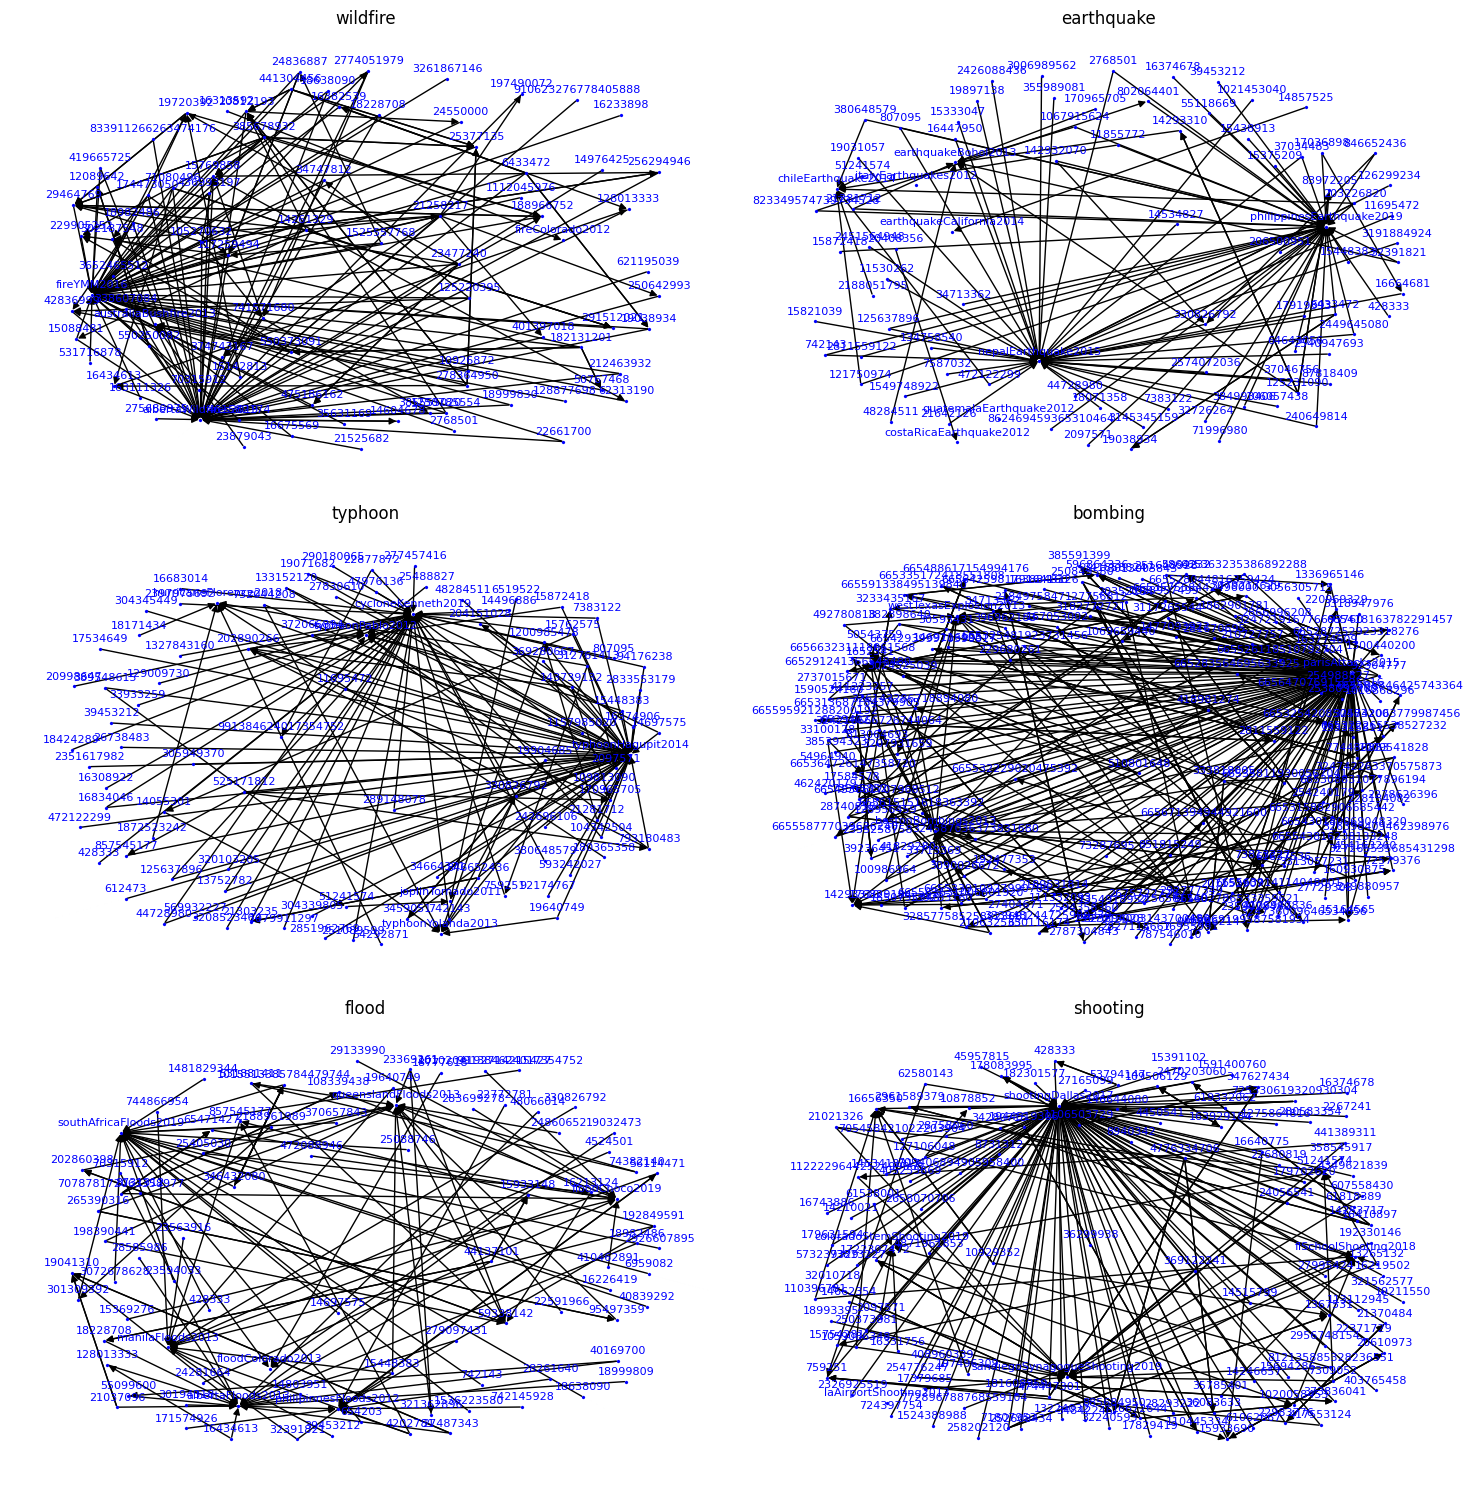

In [14]:
G = nx.read_graphml(pathData, node_type=str, edge_key_type=str)

# Extraire tous les `eventType` uniques
event_types = {data['eventType'] for node, data in G.nodes(data=True) if 'eventType' in data}
# Convertir en liste si nécessaire
event_types = list(event_types)
weightPos = {'bombing':2, 'shooting':6, 'earthquake':7, 'typhoon':10, 'flood':8, 'wildfire':15}
graph_list = []
 
for event_type in event_types: 
    weight = weightPos.get(event_type, 1)   
    subgraph = build_displayEventypeFamily(event_type)
    graph_list.append((weight, subgraph, event_type))
# Afficher les sous-graphes avec des titres correspondant aux eventTypes

display_multiple_subgraphs(graph_list)

__Ce schéma illustre clairement comment les différents éléments d'un graphe Twitter interagissent. Il peut être utilisé pour explorer diverses dimensions, comme l'engagement social, la diffusion de contenu, et l'analyse thématique. Si vous avez besoin d'une exploration plus détaillée ou d'autres visualisations, cela peut être approfondi avec des outils comme Neo4j__

In [15]:
# Chemin du répertoire contenant les fichiers JSON
path = "/Users/asriel/Library/Application Support/Neo4j Desktop/Application/relate-data/dbmss/dbms-2b32bab4-6f69-41b9-b387-635d89a4b98c/import/"
os.chdir(path)

# Répertoires contenant les fichiers JSON
nodes_directory = "Nodes"
relationships_directory = "Relationships"

In [16]:
def delete_all_nodes(driver):
    """Supprime tous les nœuds et leurs relations dans la base de données."""
    with driver.session() as session:
        query = "MATCH (n) DETACH DELETE n"
        session.run(query)
        print("Tous les nœuds et leurs relations ont été supprimés.")        

In [17]:
def load_json_file(file_path):
    """Charge un fichier JSON et retourne les données sous forme de liste."""
    # print(f'load_json_file : {file_path}')
    with open(file_path, 'r', encoding='utf-8') as file:
        data = []
        for line in file:
            try:
                data.append(json.loads(line.strip()))
            except json.JSONDecodeError as e:
                print(f"Erreur lors de la lecture de la ligne : {e}")
        return data

In [18]:
def create_node(driver, data):
    """Crée des nœuds dans la base de données Neo4j à partir des données fournies."""
    created_nodes = []
    with driver.session() as session:
        for entry in data:
            # Extract properties
            node_data = entry['n']
            properties = node_data['properties']
            external_id = node_data['id']  # Cet id est celui de niveau supérieur dans le JSON
            properties['external_id'] = external_id  # On l'ajoute aux propriétés pour le stocker dans Neo4j
            properties = entry['n']['properties']
            labels = ":".join(entry['n']['labels'])
            # Construct Cypher query
            cypher_query = f"CREATE (n:{labels} " + "{" + ", ".join([f"{key}: {json.dumps(value)}" 
                             for key, value in properties.items()]) + "})"
            try:
                # Exécuter la requête avec les propriétés dynamiques
                result = session.run(cypher_query)

                # Ajouter les nœuds créés à la liste
                for record in result:
                    created_nodes.append(record['n'])
            except Exception as e:
                # Gérer les erreurs potentielles
                print(f"Erreur lors de la création du nœud : {e}")
    return created_nodes            

In [19]:
def add_uuid_to_all_nodes(driver):
    """Ajoute un UUID à tous les nœuds qui n'ont pas encore de propriété uniqueId."""
    with driver.session() as session:
        session.run("""MATCH (n) WHERE n.uniqueId IS NULL SET n.uniqueId = randomUUID()""")

In [20]:
def create_nodes(driver):
    """Crée des nœuds et des relations à partir des fichiers JSON dans les répertoires spécifiés."""
    # Supprimer tous les nœuds existants
    #delete_all_nodes(driver)

    # Liste des fichiers JSON dans les répertoires
    node_files = [f for f in os.listdir(nodes_directory) if f.endswith(".json")]

    # Traiter les fichiers JSON dans le répertoire "Nodes"
    for file_name in node_files:
        file_path = os.path.join(nodes_directory, file_name)
        data = load_json_file(file_path)
        # Assurer que tous les éléments possèdent les attributs requis
        #complete_data = ensure_attributes(data, required_attributes, default_values)
        # Créer les nœuds
        created_nodes = create_node(driver, data)
        print(f"Fichier : {file_name} -> Nœuds créés avec toutes les propriétés.")
        
    # Ajouter des UUID à tous les nœuds
    add_uuid_to_all_nodes(driver)

In [21]:
def delete_all_relationShip(driver):
    """Supprime toutes les relations de la base de données."""
    with driver.session() as session:
        query = "MATCH ()-[r]->() DELETE r"
        session.run(query)
        print("Tous les relations ont été supprimées.")

In [22]:
def create_relationship(driver, data):
    """Crée des relations dans la base de données Neo4j à partir des données fournies."""
    with driver.session() as session:
        for entry in data:
            if 'r' in entry and entry['r'].get('type') == 'relationship':
                label = entry['r'].get('label')
                start_id = entry['r']['start'].get('id')
                start_label = entry['r']['start'].get('labels')
                end_id = entry['r']['end'].get('id')
                end_label = entry['r']['end'].get('labels')

                if start_id is None or end_id is None or label is None:
                    print(f"Erreur : Clé manquante dans l'entrée {entry}")
                    continue

                # Assurez-vous que les labels sont des chaînes de caractères
                if isinstance(start_label, list):
                    start_label = start_label[0]
                if isinstance(end_label, list):
                    end_label = end_label[0]

                # Construire dynamiquement la requête Cypher pour les relations
                query = f"""
                    MATCH (start:{start_label} {{external_id: $start_id}}), (end:{end_label} {{external_id: $end_id}})
                    CREATE (start)-[r:{label}]->(end)
                    RETURN r
                    """
                try:
                    # Exécuter la requête avec les identifiants dynamiques
                    session.run(query, start_id=start_id, end_id=end_id)
                except Exception as e:
                    print(f"Erreur lors de l'exécution de la requête : {e}")

In [23]:
def add_uuid_to_all_relationships(driver):
    """Ajoute un UUID à toutes les relations qui n'ont pas encore de propriété uniqueId."""
    with driver.session() as session:
        session.run("""
        MATCH ()-[r]->()
        WHERE r.uniqueId IS NULL
        SET r.uniqueId = randomUUID()
        """)

In [24]:
# Traiter les fichiers JSON dans le répertoire "Relationships"
def create_relationships(driver):
    
    #delete_all_relationShip(driver)
    relationship_files = [f for f in os.listdir(relationships_directory) if f.endswith(".json")]

    # Traiter les fichiers JSON dans le répertoire "Relationships"
    for file_name in relationship_files:
        file_path = os.path.join(relationships_directory, file_name)
        data = load_json_file(file_path)
        create_relationship(driver, data)
        print(f"Fichier : {file_name} -> Relations créées avec toutes les propriétés.")

    # Ajouter des UUID à tous les nœuds
    add_uuid_to_all_relationships(driver)

In [25]:
# Exécuter le processus de création de nœuds et de relations

def create_retweeted(driver):
    file_name = 'RETWEETED.json'
    file_path = path+"/"+relationships_directory+"/"+file_name
    # Traiter les fichiers JSON dans le répertoire "Relationships"
    data = load_json_file(file_path)
    create_relationship(driver, data)
    print(f"Fichier : {file_name} -> Relations créées avec toutes les propriétés.")

    # Ajouter des UUID à tous les nœuds
    add_uuid_to_all_relationships(driver)

In [26]:
from neo4j import GraphDatabase
# Connexion à la base Neo4j
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "gbenitah"))
#create_retweeted(driver)
# Exécuter le processus de création de nœuds et de relations
#create_nodes(driver)
#create_relationships(driver)
# Fermer la connexion
driver.close()

### __`Ce graphe est conçu sur la base de :`__

- __`noeuds multiples de différents types`__
- __`des relations de différents types user/item, item/item, user/user etc..`__

### __`Ce graphe est hétérogène`__

<p style="text-align: center">
<img src="images/model.png" alt="Olympics Games" width=600 large=400/>
</p>

In [27]:
import os
import pandas as pd
from neo4j import GraphDatabase
from neo4j_viz.gds import from_gds
from graphdatascience import GraphDataScience

In [28]:
# Get Neo4j DB URI, credentials and name from environment if applicable
NEO4J_URI = os.environ.get("NEO4J_URI", "bolt://localhost:7687")
NEO4J_AUTH = ("neo4j", "gbenitah")
NEO4J_DB = os.environ.get("NEO4J_DB", "neo4j")
if os.environ.get("NEO4J_USER") and os.environ.get("NEO4J_PASSWORD"):
    NEO4J_AUTH = (
        os.environ.get("NEO4J_USER"),
        os.environ.get("NEO4J_PASSWORD"),
    )
gds = GraphDataScience(NEO4J_URI, auth=NEO4J_AUTH, database=NEO4J_DB)
print(gds.server_version())

2.13.4


In [29]:
query_listLabelAttributs="""
MATCH (n) 
RETURN DISTINCT labels(n), keys(n)
"""
gds.run_cypher(query_listLabelAttributs)

,labels(n),keys(n)
0,[Tweet],"[id, isTruncated, possibly_sensitive, created_..."
1,[Event],"[trecisid, id, eventType, uniqueId, external_i..."
2,[User],"[id, friends_count, tweets_count, isVerified, ..."
3,[Hashtag],"[id, occurences, uniqueId, external_id]"
4,[PostCategory],"[id, uniqueId, external_id]"


In [30]:
# permet d'homogénéiser les attributs des tweets manquants
query="""
    MATCH (n:Tweet) 
    WHERE n.id_str IS NULL 
    SET n.id_str = toString(n.id) 
    RETURN count(n) 
    """
#gds.run_cypher(query)

In [31]:
# Nombre de noeuds
out=gds.run_cypher("CALL apoc.meta.stats() YIELD labels RETURN labels") 
for id, label in out.iterrows():
    print(label['labels'])

{'Hashtag': 10441, 'User': 43141, 'Event': 34, 'PostCategory': 25, 'Tweet': 55986}


In [32]:
# Allow to delete an given attribute as requiered
query_removeAttribute= ("""
    MATCH (n)
    WITH n, [k IN keys(n) WHERE ANY(param IN $parameter WHERE k CONTAINS param) | k] AS propertyKeys
    FOREACH (i IN propertyKeys | REMOVE n[i])
    RETURN n
    """)
#out=gds.run_cypher(query_removeAttribute, params={'parameter': 'pageRank_main'})

In [33]:
gds.run_cypher("MATCH (n) RETURN DISTINCT labels(n), keys(n), count(n)")

,labels(n),keys(n),count(n)
0,[Tweet],"[id, isTruncated, possibly_sensitive, created_...",55986
1,[Event],"[trecisid, id, eventType, uniqueId, external_i...",34
2,[User],"[id, friends_count, tweets_count, isVerified, ...",43141
3,[Hashtag],"[id, occurences, uniqueId, external_id]",10441
4,[PostCategory],"[id, uniqueId, external_id]",25


In [34]:
# Donner le nombre de relations par type ; 
gds.run_cypher("MATCH (n)-[r]->() RETURN type(r) AS relationType, COUNT(r) AS occurrences ORDER BY occurrences DESC")

,relationType,occurrences
0,HAS_CATEGORY,96566
1,POSTED,55986
2,HAS_HASHTAG,55414
3,IS_ABOUT,36668
4,TALKS_ABOUT,31134
5,MENTIONS,20894
6,RETWEETED,16332
7,RETWEETS,6296
8,REPLY_TO,2479
9,REPLIED_TO,1840


In [35]:
# Nombre de tweets par type d'évènement
query_NodeByEvent= ("""
    MATCH (e:Event)<-[:IS_ABOUT]-(t:Tweet)
    WHERE t.topic = e.trecisid 
    RETURN  e.eventType AS Type, t.topic AS topic, e.id AS Event, COUNT(t) AS tweetCount
    ORDER BY tweetCount DESC
        """)
gds.run_cypher(query_NodeByEvent)

,Type,topic,Event,tweetCount
0,earthquake,TRECIS-CTIT-H-019,nepalEarthquake2015,5858
1,typhoon,TRECIS-CTIT-H-018,typhoonHagupit2014,3938
2,shooting,TRECIS-CTIT-H-027,shootingDallas2017,2498
3,wildfire,TRECIS-CTIT-H-028,fireYMM2016,2498
4,wildfire,TRECIS-CTIT-H-029,albertaWildfires2019,2340
5,typhoon,TRECIS-CTIT-H-030,cycloneKenneth2019,2073
6,bombing,TRECIS-CTIT-H-021,parisAttacks2015,2064
7,typhoon,TRECIS-CTIT-H-026,hurricaneFlorence2018,1998
8,earthquake,TRECIS-CTIT-H-031,philippinesEarthquake2019,1997
9,flood,TRECIS-CTIT-H-033,southAfricaFloods2019,1344


In [36]:
# Nombre de tweets par type d'évènement et par année
query= """
    MATCH (e:Event)
    MATCH (t:Tweet {topic: e.trecisid})
    WITH e, COUNT(t) AS tweetCount,
     CASE
        WHEN e.id =~ '.*(\d{4})$' THEN toInteger(substring(e.id, size(e.id)-4))
        ELSE null
     END AS year
    RETURN e.eventType AS eventType,e.id AS event, year, tweetCount
    ORDER BY year ASC
    """
gds.run_cypher(query)

,eventType,event,year,tweetCount
0,typhoon,joplinTornado2011,2011,123
1,wildfire,fireColorado2012,2012,1002
2,earthquake,costaRicaEarthquake2012,2012,360
3,typhoon,typhoonPablo2012,2012,893
4,earthquake,guatemalaEarthquake2012,2012,247
5,earthquake,italyEarthquakes2012,2012,154
6,flood,philipinnesFloods2012,2012,688
7,flood,floodColorado2013,2013,1063
8,shooting,laAirportShooting2013,2013,975
9,bombing,westTexasExplosion2013,2013,907


In [37]:
# List of users involved on a given topic
query_listEventType="""
    MATCH (e:Event )
    MATCH (t:Tweet {topic: e.trecisid})<-[:POSTED]-(u:User)
    RETURN e.eventType AS EventType, e.id AS Event,  count(t) AS TweetCount, count(DISTINCT u) AS UserCount, collect(DISTINCT u.screen_name) AS UserIds
    ORDER BY EventType          
    """
gds.run_cypher(query_listEventType)

,EventType,Event,TweetCount,UserCount,UserIds
0,bombing,parisAttacks2015,2456,2389,"[juanmuriango, mashable, go_goo79, Police_Disp..."
1,bombing,westTexasExplosion2013,907,865,"[9NEWS, mashable, anblanx, PulpNews, pzf, abcW..."
2,bombing,bostonBombings2013,823,781,"[TheFireTracker2, Lawsonbulk, USRadioNews, Fox..."
3,earthquake,costaRicaEarthquake2012,360,328,"[juanmuriango, henrydjr, from___japan, YKLee13..."
4,earthquake,italyEarthquakes2012,154,151,"[juanmuriango, RES911CUE, TheFireTracker2, Twe..."
5,earthquake,earthquakeCalifornia2014,138,131,"[CBSDenver, HillbillyTimes, nlitenmebabe, ABCW..."
6,earthquake,earthquakeBohol2013,840,788,"[djB_MonEy, YKLee13, Sir_Lead, Axelfinance, tw..."
7,earthquake,nepalEarthquake2015,8437,7410,"[rqskye, bafuusa, DrowningSupport, mashable, A..."
8,earthquake,chileEarthquake2014,311,281,"[thaitvnews, LighthouseForum, PulpNews, USRadi..."
9,earthquake,philippinesEarthquake2019,2567,2046,"[mike_online, MasonicPrince32, eTurboNews, nin..."


In [38]:
# List of users involve in several event and eventType
query="""
    MATCH (e:Event)
    MATCH (t:Tweet {topic: e.trecisid})<-[:POSTED]-(u:User)
    WITH u, collect(DISTINCT e.id) AS eventIds
    WHERE size(eventIds) > 9
    RETURN u.id AS userId, u.name AS userName,  size(eventIds) as eventTypeNbre  ,eventIds
    ORDER BY userId                      
    """
gds.run_cypher(query)

,userId,userName,eventTypeNbre,eventIds
0,428333,CNN Breaking News,18,"[cycloneKenneth2019, philippinesEarthquake2019..."
1,742143,BBC News (World),13,"[nepalEarthquake2015, cycloneKenneth2019, phil..."
2,759251,CNN,14,"[shootingDallas2017, cycloneKenneth2019, color..."
3,807095,The New York Times,12,"[nepalEarthquake2015, cycloneKenneth2019, phil..."
4,1652541,Reuters Top News,12,"[parisAttacks2015, nepalEarthquake2015, philip..."
5,2097571,CNN International,10,"[cycloneKenneth2019, philippinesEarthquake2019..."
6,5402612,BBC Breaking News,11,"[nepalEarthquake2015, shootingDallas2017, typh..."
7,6017542,Breaking News,11,"[cycloneKenneth2019, sandiegoSynagogueShooting..."
8,14173315,NBC News,12,"[joplinTornado2011, sandiegoSynagogueShooting2..."
9,15012486,CBS News,11,"[earthquakeCalifornia2014, philippinesEarthqua..."


### __`Description des attributs`__
__Les attributs de tweet peuvent être interprétés comme suit pour fournir des insights significatifs.__ 

:::

- __isTruncated (booléen) :__ Indique si le texte du tweet est tronqué. Utile pour identifier les tweets nécessitant de récupérer le texte complet pour l’analyse sémantique.
 
- __possibly_sensitive (booléen) :__ Indique si le contenu du tweet est potentiellement sensible.
Permet de pour filtrer ou marquer les tweets nécessitant une attention particulière pour la modération ou la diffusion de contenu controversé.   

- __created_at (date) :__ La date et l'heure de création, permet d'analyser la temporalité comme l'identification des pics d'activité ou les tendances liées à un événement spécifique.

- __retweet_count (nombre) :__ Le nombre de fois qu'un tweet a été retweeté est un indicateur de popularité ou d'engagement, utile pour identifier les tweets influents. Peut être utilisé pour identifier les nœuds les plus influents dans le graphe.

- __annotation_annotated (booléen) :__ Indique si le tweet a été annoté manuellement. Peut être utilisé pour distinguer les tweets qui ont été examinés ou catégorisés par des humains.

- __is_quote_status (booléen) :__ Indique si le tweet est une citation d'un autre tweet. Utile pour analyser les interactions et les conversations entre les utilisateurs.

- __annotation_annotated et annotation_num_judgements :__ Indiquent si un tweet a été annoté et combien de jugements ont été effectués. Utile et pertinent dans des contextes où les tweets sont analysés manuellement ou automatiquement pour des tâches comme la classification thématique ou la détection d’émotions.

- __id_str et id (chaîne de caractères et nombre) :__ L'dentifiants uniques du tweet est utilisés pour référencer et retrouver spécifiquement ce tweet dans le graphe.

- __topic (chaîne de caractères) :__ Le sujet ou la catégorie associée au tweet, elle permet de regrouper et d'analyser les tweets par thèmes ou catégories.

- __favorite_count (nombre) :__ Nombre de fois que le tweet a été marqué comme favori est un indicateur d’engagement qui peut être combiné avec __retweet_count__ pour évaluer l’impact global d’un tweet.  
 
- __text (chaîne de caractères) :__ Le contenu textuel du tweet est essentiel pour l'analyse de contenu, l'extraction de thèmes, de sentiments, ou de mots-clés.

- __Hashtags (ex. #FortMcMurray, #ymmfire) :__ Utilisés pour identifier les sujets tendances et les discussions populaires. Peuvent être analysés pour comprendre les thèmes et les communautés d'intérêt.

:::

### __`Application dans un Graphe`__
__Dans un graphe, ces attributs peuvent être utilisés comme suit :__

:::

Les attributs comme __retweet_count__, __favorite_count__, et __possibly_sensitive__ peuvent être utilisés comme métriques pondérant les relations entre nœuds (par exemple, force d’influence entre utilisateurs).

Les dates (__created_at__) permettent une analyse temporelle des interactions dans le graphe.

Les thèmes (__topic__) et hashtags extraits du texte (__text)__ peuvent être utilisés pour créer des sous-graphes thématiques ou détecter des communautés.

 :::

<p style="text-align: center">
<img src="images/model.png" alt="Olympics Games" width=500 large=400/>
</p>

### __`Typicals tasks of recommendation`__

__`Identifier les tweets et les utilisateurs fortement influents en se basant sur des critères d’engagement.`__   

`Méthodologie` : La requête identifie d’abord les tweets qui satisfont à des seuils sur retweet_count et favorite_count.  
	– Elle associe ces tweets aux utilisateurs les ayant publiés ainsi qu’à des éléments contextuels (hashtags, catégories, événements).    
	– Le résultat est une liste d’utilisateurs qui donne une vision de la « force d’influence » et de la capacité à générer un engagement.  

`Avantages` :  Le filtrage par seuils permet de se concentrer sur des cas extrêmes ce qui est pertinent lorsqu’on cherche à identifier des influenceurs ou des contenus populaires. L’association avec d’autres entités (hashtags, catégories, événements) enrichit l’analyse contextuelle de l’influence.      

In [39]:
# permet de déterminer la force d'influence des utilisateurs
query_User_Item_Ratings = """
        MATCH (t:Tweet)             
        MATCH (e:Event)
        MATCH (u:User)-[:POSTED]->(t:Tweet {topic: e.trecisid})-[:HAS_HASHTAG]->(h:Hashtag)
        MATCH (t)-[:HAS_CATEGORY]->(pc:PostCategory)  
        WHERE  t.favorite_count > 10000 AND t.retweet_count > 10000    
        RETURN distinct u.screen_name AS screen_name, 
               t.retweet_count AS retweet_count, 
               t.favorite_count AS favorite_count,
               h.id as hashtag,
               e.id as event_id,  
               t.text as tweet_id 
        ORDER BY retweet_count, favorite_count ASC                   
        """
gds.run_cypher(query_User_Item_Ratings)

,screen_name,retweet_count,favorite_count,hashtag,event_id,tweet_id
0,kkkiiiitttyyy,10044,18835,respect,philippinesEarthquake2019,"Before posting earthquake memes, we in Pampang..."
1,BOGUMMY,26229,102095,PrayForPhilippines,philippinesEarthquake2019,#PrayForPhilippines \nI'd like to inform you t...


__`Classer par hashtag les valeurs maximales de « favorite_count. » Cette requête permet d'identifier le tweet qui affiche la valeur maximale de « favorite_count » en appliquant le filtre sur les tweets ayant un engagement très élevé et de les classer par hashtag.`__

# __`PROBLEME DANS CETTE REQUETE`__

In [40]:
#  Regroupe les tweets par hashtag et sélectionne le tweet ayant le nombre maximum de favoris dans chaque groupe.
query=""" 
    MATCH (e:Event)
    MATCH (t:Tweet)-[:HAS_HASHTAG]->(h:Hashtag)
    WHERE t.favorite_count > 10000 AND t.retweet_count > 10000
    WITH h, t, e
    ORDER BY t.favorite_count DESC
    WITH e, h, head(collect(t)) AS topTweet
    RETURN h.id AS hashtag,
       e.id AS Event,
       topTweet.id AS Tweet,
       topTweet.favorite_count AS favorite_count,
       topTweet.retweet_count AS retweet_count,
       topTweet.text AS tweet_text
    ORDER BY h.id ASC
"""
gds.run_cypher(query)

,hashtag,Event,Tweet,favorite_count,retweet_count,tweet_text
0,1DFollowSprees,fireColorado2012,664038693053665280,37192,19418,? @onedirection ?\nI'm very excited.\n\nI can'...
1,1DFollowSprees,costaRicaEarthquake2012,664038693053665280,37192,19418,? @onedirection ?\nI'm very excited.\n\nI can'...
2,1DFollowSprees,floodColorado2013,664038693053665280,37192,19418,? @onedirection ?\nI'm very excited.\n\nI can'...
3,1DFollowSprees,typhoonPablo2012,664038693053665280,37192,19418,? @onedirection ?\nI'm very excited.\n\nI can'...
4,1DFollowSprees,laAirportShooting2013,664038693053665280,37192,19418,? @onedirection ?\nI'm very excited.\n\nI can'...
...,...,...,...,...,...,...
743,respect,cycloneKenneth2019,1120314983600934913,18835,10044,"Before posting earthquake memes, we in Pampang..."
744,respect,philippinesEarthquake2019,1120314983600934913,18835,10044,"Before posting earthquake memes, we in Pampang..."
745,respect,coloradoStemShooting2019,1120314983600934913,18835,10044,"Before posting earthquake memes, we in Pampang..."
746,respect,southAfricaFloods2019,1120314983600934913,18835,10044,"Before posting earthquake memes, we in Pampang..."


__`Identifier des tweets qui se dégagent par rapport aux moyennes globales d’engagement par mesure la déviation à la moyenne.`__ 

`Méthodologie`: La requête calcule la moyenne et l’écart-type pour les compteurs (retweets et favorites) sur l’ensemble des tweets.    
     
    – Pour chaque tweet associé à un événement, le calcule du z-score exprime l’écart par rapport à la moyenne.    
    – Un tweet avec un z-score élevé est considéré comme particulièrement performant par rapport à l’ensemble.  

__Avantages__ :      

    - Permet d’établir une comparaison relative en normalisant les données.      
    – S’adapte aux variations globales des données, même si le volume d’engagement change dans le temps.

__Normalisation z-score via le calcul de la moyenne et de l'écart-type__ : 
   
- Le z-score est une mesure statistique qui décrit la position d'une donnée par rapport à la moyenne de l'ensemble de données.         
- Les attributs sont normalisés en utilisant la formule z-score, qui ajuste les valeurs en fonction de la moyenne et de l'écart-type.      
- La première partie de la requête calcule la moyenne et l'écart-type pour `retweet_count` et `favorite_count`.  



__La formule du z-score est__ :
 $\Large z=\frac{\sigma}{(X−\mu)}$

Les valeurs négatives dans le contexte du __z-score__ sont normales et fournissent des informations précieuses sur la performance relative des tweets par rapport à la moyenne. Elles permettent de mieux comprendre la distribution de l'engagement et d'identifier les tweets qui se distinguent, que ce soit positivement ou négativement. 

In [41]:
#REcommandation : Identifie des tweets qui se dégagent par rapport aux moyennes globales d’engagement par mesure la déviation à la moyenne
query_recommandation=  """
       MATCH (t:Tweet)
       WITH avg(t.retweet_count) AS avg_retweet, 
            stdev(t.retweet_count) AS ecartType_retweet,
            avg(t.favorite_count) AS avg_favorite, 
            stdev(t.favorite_count) AS ecartType_favorite
       MATCH (e:Event)
       MATCH (t:Tweet {topic: e.trecisid})<-[:POSTED]-(u:User)
       WITH t, u, e, avg_retweet, ecartType_retweet, avg_favorite, ecartType_favorite,
            ecartType_retweet / (t.retweet_count - avg_retweet) AS zscore_retweet,
            ecartType_favorite / (t.favorite_count - avg_favorite) AS zscore_favorite,
            [word IN split(t.text, " ") WHERE word STARTS WITH "#"] AS hashtags
       UNWIND hashtags AS hashtag
       RETURN u.screen_name AS userid,
            t.id AS tweet,
            e.id AS Event,
            zscore_retweet, 
            zscore_favorite,
            hashtag AS extracted_hashtag
       ORDER BY zscore_retweet DESC, zscore_favorite DESC
              """
gds.run_cypher(query_recommandation)

,userid,tweet,Event,zscore_retweet,zscore_favorite,extracted_hashtag
0,leahnavarro,1120327906847182848,philippinesEarthquake2019,6783.036162,18.408906,#NasaanAngPangulo?
1,capecodweather,243364184228757504,costaRicaEarthquake2012,6783.036162,-60.881404,#earthquake
2,capecodweather,243364184228757504,costaRicaEarthquake2012,6783.036162,-60.881404,#Tsunami
3,TWCBreaking,243362871143198720,costaRicaEarthquake2012,6783.036162,-61.765236,#earthquake
4,TWCBreaking,243362871143198720,costaRicaEarthquake2012,6783.036162,-61.765236,#Tsunami
...,...,...,...,...,...,...
52656,PhilippineStar,1120284978800054272,philippinesEarthquake2019,-8897.011014,81.636312,#EarthquakePH
52657,getitfromboy,1120257061512601600,philippinesEarthquake2019,-8897.011014,57.019560,#EARTHQUAKEPH
52658,getitfromboy,1120257061512601600,philippinesEarthquake2019,-8897.011014,57.019560,#LINDOLPH
52659,weathernetwork,727613728208883712,fireYMM2016,-8897.011014,-158.261021,#FortMcMurray


In [42]:
# Identifie les tweet ayant le plus de retweet et de favoris
# et qui sont associés à un événement spécifique
# et qui contiennent des hashtags spécifiques
# et qui sont associés à une catégorie de publication spécifique
# et qui ont un nombre de favoris et de retweets supérieur à 10000
# et qui sont associés à un utilisateur spécifique
query_User_Item_Ratings = """
        MATCH (t:Tweet)             
        MATCH (e:Event)
        MATCH (u:User)-[:POSTED]->(t:Tweet {topic: e.trecisid})-[:HAS_HASHTAG]->(h:Hashtag)
        MATCH (t)-[:HAS_CATEGORY]->(pc:PostCategory)  
        WHERE  t.favorite_count > 10000 AND t.retweet_count > 10000    
        RETURN distinct u.screen_name AS username, 
               h.id as hashtag_val,
               pc.id as postCategory_val,
               e.id as eventId,  
               t.id as tweetID, 
               t.retweet_count AS retweet_count, 
               t.favorite_count AS favorite_count
        ORDER BY retweet_count, favorite_count DESC                   
        """
gds.run_cypher(query_User_Item_Ratings)

,username,hashtag_val,postCategory_val,eventId,tweetID,retweet_count,favorite_count
0,kkkiiiitttyyy,respect,Location,philippinesEarthquake2019,1120314983600934913,10044,18835
1,kkkiiiitttyyy,respect,Hashtags,philippinesEarthquake2019,1120314983600934913,10044,18835
2,kkkiiiitttyyy,respect,MultimediaShare,philippinesEarthquake2019,1120314983600934913,10044,18835
3,kkkiiiitttyyy,respect,FirstPartyObservation,philippinesEarthquake2019,1120314983600934913,10044,18835
4,kkkiiiitttyyy,respect,Sentiment,philippinesEarthquake2019,1120314983600934913,10044,18835
5,BOGUMMY,PrayForPhilippines,ServiceAvailable,philippinesEarthquake2019,1120917836812054528,26229,102095
6,BOGUMMY,PrayForPhilippines,Hashtags,philippinesEarthquake2019,1120917836812054528,26229,102095


__`Fournit une estimation du volume des données à traiter`__


In [43]:
query_min_max_retweet_favorite = """
                MATCH (t:Tweet)
                RETURN max(t.retweet_count) AS max_retweet,
                max(t.favorite_count) AS max_favorite    
                        """
out=gds.run_cypher(query_min_max_retweet_favorite)
print(out)

   max_retweet  max_favorite
0       568369       1676300


In [44]:
# Liste des procédures GDS accessibles
query_procedures = """SHOW PROCEDURES yield name, description, signature """
#gds.run_cypher(query_procedures)

## Tools

In [45]:
import re

def remove_special_chars(text):
    # Remplacer tous les caractères qui ne sont pas alphabétiques, numériques ou espaces par un espace
    text = text if text is not None else "Unknown"
    cleaned_text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    # Supprimer les espaces multiples
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text)
    return cleaned_text.strip()

### Random Walk permet de réduire les graphes ou les sous graphes.

|Méthode|Avantages|Inconvénients|Cas d'Utilisation|
|--- |--- |--- |--- |
|Random Walk / Forest Fire|Préserve la connectivité et clusters|Plus coûteux|Analyse communautaire| 

### __`Based on sub-event graphs as the ground truth`__    
__Remarque__ : 
Le concept de sous-événements comme vérité terrain fait généralement référence à la décomposition d'un événement principal en ses composantes ou phases distinctes mais liées. 
 
Cette approche permet d'analyser les événements de manière plus granulaire et de mieux comprendre les interactions et les dépendances entre les différentes parties d'un événement. 

Par exemple pour un tremblement de terre les sous-événements pourraient être :  
  - La secousse initiale
  - Les répliques sismiques
  - Les opérations de sauvetage
  - L'aide humanitaire
  - La reconstruction

<p style="text-align: center">
<img src="images/model.png" alt="Olympics Games" width=500 large=200/>
</p>

### __`Présentation des Algorithmes GDS pour l'analyse`__

#### __`Cohérence Générale`__

1. __Projection__
2. __Mesures de base (PageRank)__
3. __Embeddings__
4. __Échantillonnage__
5. __Clustering et détection de communautés__
6. __Analyse des communautés__
7. __Recommandations et similarité__
8. __Pathfinding et centralité__
9. __GraphSAGE pour des analyses avancées__  

__`Projection (gds.graph.project) :`__
 - Objectif : Charger le graphe en mémoire.
 - Analyse : Etape initiale de l'analyse avec GDS permettant de définir la topologie et les propriétés des nœuds/relations.

__`PageRank (gds.pageRank) :`__
 - Objectif : Calculer l'influence des nœuds.
 - Analyse : Très utile pour obtenir une première mesure de l'importance des nœuds. C'est une étape pour identifier les acteurs clés. 

__`Embeddings (gds.fastRP) :`__
 - Objectif : Générer des vecteurs d'embedding (représentations vectorielles denses des nœuds).
 - Analyse : Crucial pour de nombreuses tâches de Machine Learning sur graphes. Les embeddings capturent la structure du voisinage d'un nœud et ses propriétés. FastRP est rapide et efficace.

__`Échantillonnage (gds.graph.sample.cnarw) :`__
 - Objectif : Réduire la taille du graphe.
 - Analyse : cnarw (Common Neighbor Aware Random Walk) est une méthode d'échantillonnage qui tente de préserver la structure des communautés. Si le graphe est trop grand pour certains algorithmes ou pour la visualisation. 
 
__`La position de cette étape est intéressante :`__
 - Si nous échantillonnons après PageRank et Embeddings, nous avons des scores/vecteurs pour le graphe complet, puis nous travaillons sur un sous-ensemble.

Si l'on souhaite que les algorithmes suivants (comme k-means ou Leiden) s'exécutent plus rapidement, on pourrait échantillonner plus tôt, mais alors les scores/embeddings seraient calculés uniquement sur l'échantillon. La séquence actuelle suggère que les embeddings sont générés sur le graphe potentiellement plus grand.

__`Détection de Communautés (gds.Leiden.write) :`__
 - Objectif : Identifier les communautés naturelles basées sur la densité des connexions.
 - Analyse : Louvain est un algorithme populaire pour la détection de communautés structurelles. Le .write indique que les IDs des communautés sont écrits comme propriétés des nœuds, ce qui est utile pour des analyses ultérieures. Peut être exécuté sur le graphe complet ou l'échantillon.


__`Recommandations (gds.alpha.ml) :`__
 - Objectif : Créer des systèmes de recommandation (probablement prédiction de liens ou de propriétés).
 - Analyse : Les pipelines ML de GDS (souvent en alpha ou beta) peuvent utiliser les embeddings (étape 3), les communautés (étape 6), ou d'autres caractéristiques pour faire des prédictions.

__`Similarité (gds.nodeSimilarity) :`__
 - Objectif : Identifier les nœuds similaires.
 - Analyse : Peut utiliser les embeddings (similarité cosinus sur les vecteurs FastRP) ou être basé sur la structure (Jaccard, Overlap). Utile pour trouver des "doublons" ou des nœuds ayant des rôles similaires.

__`Pathfinding (gds.alpha.shortestPath) :`__
 - Objectif : Trouver les chemins les plus courts.
 - Analyse : Fondamental pour comprendre la distance et la connectivité entre les nœuds.

__`Centrality (gds.alpha.closeness) :`__
 - Objectif : Identifier les nœuds centraux (ceux qui peuvent atteindre les autres rapidement).
 - Analyse : La centralité de proximité est une autre mesure d'importance, complémentaire à PageRank.

__`GraphSAGE (gds.beta.graphSage) :`__
 - Objectif : Effectuer des analyses de graphes (typiquement, générer des embeddings inductifs).
 - Analyse : GraphSAGE est un autre algorithme d'embedding puissant, souvent utilisé pour des graphes dynamiques ou pour généraliser à des nœuds non vus. Il pourrait être une alternative ou un complément à FastRP. Son placement en fin de liste suggère une exploration plus avancée.

#### __`1.1 Connexion`__

In [46]:
import os
import pandas as pd
import numpy as np
from neo4j import GraphDatabase
from graphdatascience import GraphDataScience

In [47]:
def get_gdsConnection():
    # Get Neo4j DB URI, credentials and name from environment if applicable
    NEO4J_URI = os.environ.get("NEO4J_URI", "bolt://localhost:7687")
    NEO4J_AUTH = ("neo4j", "gbenitah")
    NEO4J_DB = os.environ.get("NEO4J_DB", "neo4j")
    if os.environ.get("NEO4J_USER") and os.environ.get("NEO4J_PASSWORD"):
        NEO4J_AUTH = (
            os.environ.get("NEO4J_USER"),
            os.environ.get("NEO4J_PASSWORD"),
            )
    gds = GraphDataScience(NEO4J_URI, auth=NEO4J_AUTH, database=NEO4J_DB)
    print(gds.server_version())
    return gds

#### __`1.2 Outils de libération de la mémoire efface les graphes projetés`__

In [48]:
# Permet de décharger les projections de la mémoire et de Neo4j
query_drop = f"""
    CALL gds.graph.exists($graphName)
         YIELD exists
         WITH exists
    WHERE exists = true
    CALL gds.graph.drop($graphName, false)
         YIELD graphName
    RETURN graphName;
    """

query_inspect_graph = """
    CALL gds.graph.list()
    YIELD graphName, schema
    RETURN distinct graphName
    """
#gds.run_cypher(query_inspect_graph)

def drop_wholeGraph(gds): 
    result = gds.run_cypher(query_inspect_graph)
    for index, row in result.iterrows():
        gds.run_cypher(query_drop, params={'graphName': row['graphName']})
        
gds=get_gdsConnection()        

2.13.4


#### __`1.3 Outils de réinitialisation des attributs de la base Neo4J`__

In [49]:
# Retire tous les attribus qui ont été ajoutés aux noeuds dans l'environnement Neo4j
def clean_database_parameter(gds, lisparam=[]):
    query_removeAttribute= ("""
        MATCH (n)
        WITH n, [k IN keys(n) WHERE ANY(param IN $parameter WHERE k CONTAINS param) | k] AS propertyKeys
        FOREACH (i IN propertyKeys | REMOVE n[i])
        RETURN n
        """)
    gds.run_cypher(query_removeAttribute, params={'parameter': lisparam})

clean_database_parameter(gds,lisparam= [ 'topicId','eventTypeId', 'eigenvector', 'betweeness', 'rank',
                                        'degree', 'localClusteringCoefficient', 'intermediateCommunities', 
                                        'pageRank', 'articulationPoint','community'])

In [50]:
# Retire tous les attribus qui ont été ajoutés aux noeuds sur le graphe projeté
def clean_projectionGraph_Parameter(gds, graphName, parameter):
        query_drop = """    
        CALL gds.graph.nodeProperties.drop($graphName, $parameter)
        YIELD propertiesRemoved, graphName
        RETURN propertiesRemoved, graphName
        """
        graph = gds.graph.get(graphName)
        node_properties_by_label = graph.node_properties()
        for label, properties_dict in node_properties_by_label.items():
            if parameter in properties_dict:
               gds.run_cypher(query_drop, params={'graphName': graphName, 'parameter': parameter})
               print(f"Propriété '{parameter}' supprimée du graphe '{graphName}'.")
               break

In [51]:
# retourne la liste des graphe en mémoire
def list_graphs(gds):
    query_listPjtBase="""CALL gds.graph.list() YIELD graphName, nodeCount, relationshipCount, schema RETURN distinct graphName, nodeCount, relationshipCount, schema"""
    return gds.run_cypher(query_listPjtBase)

#### __`1.4 Création de "topicId"`__

Le filtrage sur les graphes projetés ne peut s'effectuer que sur des attributs numériques. Pour permettre le filtrage sur les topics il est nécessaire de céer un attribut numérique qui match avec l'attribut topic et ce pour le label Event et Tweet.

In [52]:
# On récupère les deux derniers caractères numériques de trecisid pour en faire un ID en correspodance avec l'id de Event 
# l'objectif est de peremttre d'effectuer sur les graphe projeté des restrictions sur les topics à partir de Event et de Tweet.

query_set_topicid_corrected = """
    MATCH (e:Event)
    SET e.topicId = toIntegerOrNull(substring(e.trecisid, size(e.trecisid) - 2, 2))
    WITH count(e) AS events_processed

    MATCH (t:Tweet)
    SET t.topicId = toIntegerOrNull(substring(t.topic, size(t.topic) - 2, 2))

    RETURN events_processed, count(t) AS tweets_processed
    """

try:
    update_result = gds.run_cypher(query_set_topicid_corrected)
    # Affiche le nombre d'events et tweets potentiellement mis à jour
except Exception as e:
    print(f"Erreur lors de la mise à jour des topicId: {e}")
    # Gérer l'erreur

query_dico_topicId = """
    MATCH (e:Event)
    WHERE e.topicId IS NOT NULL
    RETURN e.topicId AS key, e.id AS value
    """
dico_topicId = gds.run_cypher(query_dico_topicId)
# on crée un dictionnaire pour récupérer les valeurs littérales à partir des ident
dico_topicId = dict(zip(dico_topicId['key'], dico_topicId['value']))  

#### __`1.5 Création de "eventTypeId"`__

Le filtrage sur les graphes projetés ne peut s'effectuer que sur des attributs numériques. Pour permettre le filtrage sur les EventType il est nécessaire de céer un attribut numérique qui match avec l'attribut Eventype pour le label Event.

In [53]:
# Il est nécessaire de créer un attribut numérique qui soit en corrrespondance avec les "Event" afin de permettre 
# l'utilisation des fonctionnalités GDS pour de création de sous-graphe par "Event". 
query= """
    MATCH (n:Event)
    SET n.eventTypeId = CASE n.eventType
        WHEN 'bombing' THEN toInteger(1)
        WHEN 'shooting' THEN toInteger(2)
        WHEN 'earthquake' THEN toInteger(3)
        WHEN 'typhoon' THEN toInteger(4)
        WHEN 'flood' THEN toInteger(5)
        WHEN 'wildfire' THEN toInteger(6)
        ELSE 0 END;
    """

out=gds.run_cypher(query)

In [54]:
# vérification de la création de l'atrribut numérique relatif aux différents "Event"
query_checkEventId = """MATCH (n:Event) RETURN n.id, n.topicId,n.eventType, n.eventTypeId"""
gds.run_cypher(query_checkEventId)

,n.id,n.topicId,n.eventType,n.eventTypeId
0,fireColorado2012,1,wildfire,6
1,costaRicaEarthquake2012,2,earthquake,3
2,floodColorado2013,3,flood,5
3,typhoonPablo2012,4,typhoon,4
4,laAirportShooting2013,5,shooting,2
5,westTexasExplosion2013,6,bombing,1
6,guatemalaEarthquake2012,7,earthquake,3
7,italyEarthquakes2012,8,earthquake,3
8,philipinnesFloods2012,9,flood,5
9,albertaFloods2013,10,flood,5


In [55]:
# vérification de la création de l'atrribut numérique relatif aux différents "Event"
query_checkEventId = """MATCH (n:Tweet) RETURN n.id, n.topicId, n.topic"""
df_alt_replace = gds.run_cypher(query_checkEventId)
df_alt_replace

,n.id,n.topicId,n.topic
0,212364712506163201,1,TRECIS-CTIT-H-001
1,212365530391252993,1,TRECIS-CTIT-H-001
2,212373109477617664,1,TRECIS-CTIT-H-001
3,212377068904787969,1,TRECIS-CTIT-H-001
4,212384295719931904,1,TRECIS-CTIT-H-001
...,...,...,...
55981,212311709082337281,1,TRECIS-CTIT-H-001
55982,212311994286620672,1,TRECIS-CTIT-H-001
55983,212315735609966592,1,TRECIS-CTIT-H-001
55984,212319443383103488,1,TRECIS-CTIT-H-001


__`Avant d'appliquer des algorithmes complexes, explorons certaines caractéristiques fondamentales`__

  __`1) Base de l’embedding`__:      
  - Les techniques d’embedding basées sur "PageRank", reposent sur la génération préalable de vecteurs PageRank.      
  - Ces vecteurs capturent l’importance structurelle ou locale des nœuds dans le graphe, qui est ensuite transformée en une représentation compacte via des méthodes comme la décomposition en valeurs singulières (SVD) ou d’autres algorithmes d’embedding.

  __`2) Processus typique`__ :     
   - D’abord, les vecteurs PageRank (ou Personalized PageRank) sont calculés pour les nœuds du graphe.     
   - Ensuite, ces vecteurs sont transformés, en appliquant soit une opération logarithmique ou une pondération spécifique.         
   - Puis avant on passe à l'étape d’embedding comme le SVD pour produire les représentations finales.          

### __`2 Projection chargement des graphes en mémoire`__  

La première étape consiste à projeter le graphe principal en mémoire pour accélérer les calculs et les analyses.        
Cette opération utilise les fonctions de GDS de graphe projeté qui n'autorise pas l'utilisation d'attribut autre que numériques permettre le filtrage des noeuds du graphe par type d'event tels qu'ils apparaissent dans notre exemple. 

Par principe de précaution, il est recommandé de toujours projeter le graphe avant d'effectuer des calculs ou des analyses.         
La projection du graphe est une étape cruciale pour l'analyse de graphes volumineux, car elle permet de créer une vue en mémoire optimisée du graphe qui accélère les calculs et les requêtes.

<p style="text-align: center">
<img src="images/model.png" alt="Olympics Games" width=500 large=200/>
</p>

:::

#### __` 2.1 Création du graphe projeté par filtrage de type I`__ 
 
`Graphe projeté avec des nœuds de type User et des relations synthétiques`

 - __Propriétés du Graphe__ : 
    - Le graphe projeté est stocké sous le nom neo4j_userInfluence_filtered.
    - Les propriétés des nœuds sont stockées dans le graphe projeté.
    - Les propriétés des relations sont stockées dans le graphe projeté.

::: 

#### __`2.2 Graphe principal cadre de la démarche pipeline type II`__

 - L'objectif est de commencer par projeter un graphe en mémoire avec la Graph Data Science Library (GDS) de Neo4j. 
 - Ce graphe, inclut différents types de nœuds avec leurs propriétés spécifiées, et les relations qui les lient.

In [56]:
query_create_main_graph = """
    CALL gds.graph.project(
        $graphName,
        {
          Event:        { properties: $properties[0] },
          User:         { properties: $properties[1] },
          Tweet:        { properties: $properties[2] },
          Hashtag:      { properties: $properties[3] },
          PostCategory: { properties: $properties[4] }
        },
        {
          POSTED:      { orientation: $orientation[0] },
          MENTIONS:    { orientation: $orientation[1] },
          REPLIED_TO:  { orientation: $orientation[2] },
          TALKS_ABOUT: { orientation: $orientation[3] },
          REPLY_TO:    { orientation: $orientation[4] },
          IS_ABOUT:    { orientation: $orientation[5] },
          HAS_HASHTAG: { orientation: $orientation[6] },
          HAS_CATEGORY:{ orientation: $orientation[7] },
          RETWEETS:    { orientation: $orientation[8] },
          RETWEETED:   { orientation: $orientation[9] }
        }   
    )
       YIELD
        graphName,
        nodeCount,
        relationshipCount,
        nodeProjection,         
        relationshipProjection, 
        projectMillis           
      RETURN graphName, nodeCount, relationshipCount, nodeProjection, relationshipProjection, projectMillis;
"""

#### __`2.2.1 Filtrage du Graphe`__ 

 - À partir du graphe principal, nous extrayons un sous-graphe filtré pour se concentrer sur un eventTypeId spécifique (ici, 5).    
 - Le filtre inclut tous les nœuds User et Tweet, ainsi que des types de relations spécifiques (POSTED, RETWEETS, MENTIONS, REPLIED_TO).    
 - Ceci permet de conserver le contexte autour de l'événement

In [57]:
# Filtrage à partir du graphe projeté principal 
eventTypeFilter = """
        CALL gds.graph.filter(
            $filteredName,     
            $sourceName,       
            $nodeFilterPredicate, 
            $relFilterPredicate,   
            { parameters: { eventId: $eventIdValue } } 
        ) YIELD graphName, fromGraphName, nodeCount, relationshipCount
        RETURN graphName, fromGraphName, nodeCount, relationshipCount
        """ 

### __`3 PageRanking`__  

L'algorithme PageRank permet de mesurer la pertinence de chaque nœud d'un graphe, qui dépend du nombre de relations entrantes provenant des autres nœuds et de l'importance des nœuds sources. 


##### __`3.1 Centralité basée sur le pageRank`__ 

:::  

__Le PageRank mesure l'importance du nœud fonction du nombre de relations entrantes et de l'importance des nœuds sources correspondants.     
L'hypothèse sous-jacente est qu'une page n'a d'importance que si elle est liée à des pages.__ 

$PR(A)=(1-d)+d\large \frac{PR(T_i)}{C(T_i)}+...+d\large \frac{PR(T_n)}{C(T_n)}$
 - nous supposons qu'une page A possède des pages $T_1$ à $T_n$ qui pointent vers elle.
 - $d$ est un facteur d'amortissement réglable entre 0 (inclus) et 1 (exclu). Il est généralement fixé à 0,85.
 - $C(A)$ est défini comme le nombre de liens sortant de la page $A$.

:::



In [95]:
# Utiliser uniquement les labels existants
query_pageRank_mutate = """
    CALL gds.pageRank.mutate(
        $graphName,
      { 
        mutateProperty: $nodeProperties,
        maxIterations: 50,
        dampingFactor: 0.75,
        nodeLabels: $nodeLabels, 
        relationshipTypes: $relationshipTypes 
      }
    )
   """

query_pageRank_stream=""" 
    CALL gds.graph.nodeProperty.stream(
        $graphName, 
        $nodeProperties,
        $nodeLabels, 
        $relationshipTypes 
    )
    YIELD nodeId, propertyValue AS score 
    WITH gds.util.asNode(nodeId) AS userNode, score
    RETURN userNode.name AS influentialUser, score
    ORDER BY score DESC
    """

::: 


Il y a quelques points à prendre en considération lors de l'utilisation de l'algorithme PageRank :

 - S'il n'existe pas de relation entre l'intérieur et l'extérieur d'un groupe de pages, celui-ci est considéré comme un piège à araignées.    
 - Une chute de rang peut se produire lorsqu'un réseau de pages forme un cycle infini.    
 - Les impasses se produisent lorsque les pages n'ont aucune relation sortante.    

Modifier le facteur d'amortissement peut contribuer à toutes les considérations ci-dessus.     
Il peut être interprété comme la probabilité qu'un internaute accède parfois à une page aléatoire et évite ainsi de se retrouver bloqué dans des éviers.

:::

### __`4 Echantillonnage et réduction du graphe`__  

L'algorithme CNARW, (Common Neighbour Aware Random Walk) est conçu pour créer des échantillons équilibrés de grands graphes tout en préservant leurs propriétés structurelles. 

Contrairement aux marches aléatoires simples qui se retrouvent souvent piégées dans des zones hautement groupées d'un graphe, CNARW navigue intelligemment dans le graphe en :   

 1. Considérant les voisins communs entre le nœud actuel et les nœuds potentiels suivants
 2. Priorisant les chemins qui mènent vers des régions inexplorées du graphe
 3. Réduisant la probabilité de revisiter des nœuds déjà visités

Cette approche est particulièrement précieuse pour les sous-graphes basés sur des événements car elle aide à maintenir la nature représentative de chaque communauté d'événements tout en réduisant le graphe à une taille plus gérable.     

Dans la plupart des approches de clustering basées sur des graphes, il est recommandé de réaliser la réduction du graphe avant l’identification des clusters afin de bénéficier d’une meilleure performance et d’une plus grande robustesse dans l’analyse structurelle du réseau.

In [59]:
query_random_walk = """
    CALL gds.graph.sample.rwr(
      $sampled_graph_name,
      $subgraph_name,
      { 
        samplingRatio: $sampling_ratio,
        nodeLabelStratification: true,
        nodeProperties: $nodeProperties 
      }
    )
    YIELD nodeCount, relationshipCount;
    """

query_random_walk_estimate="""
  CALL gds.graph.sample.cnarw.estimate(
    $subgraph_name,
  {
    samplingRatio: 0.25
  })
  YIELD requiredMemory
  RETURN requiredMemory
  """   
#    startNodes: $start_node_ids 
#    walkLength: 4,
#    iterations: 10, 

### __`5 Embeddings`__

Les algorithmes d'intégration de nœuds calculent des représentations vectorielles de faible dimension des nœuds d'un graphe. Ces vecteurs, également appelés intégrations, peuvent être utilisés pour l'apprentissage automatique. La bibliothèque Neo4j Graph Data Science contient l'algorithme d'intégration de nœuds suivant : 

 - __La projection aléatoire rapide, ou FastRP__, est un algorithme d'intégration de nœuds appartenant à la famille des algorithmes de projection aléatoire. 
 
 - __Ces algorithmes reposent théoriquement sur le lemme de Johnsson-Lindenstrauss__ selon lequel il est possible de projeter n vecteurs de dimension arbitraire en O(log(n)) dimensions tout en préservant approximativement les distances deux à deux entre les points. 

En fait, une projection linéaire choisie aléatoirement satisfait cette propriété.

Nous utilisons l'algorithme FastRP pour la génération de l'embedding des noeuds, il fournit une représentation topographique du graphe.      
Empiriquement nous avons choisi le paramètre embeddingDimension à 8 au regard de la densité du graphe.

Les embeddings FastRP s’appliquent à tous les nœuds présents dans le graphe projeté, indépendamment de leurs labels.     
Si la projection contient différents types de nœuds, l’algorithme générera des embeddings pour chacun d’eux, contrairement à ce que l’on pourrait penser, FastRP ne traite pas séparément les différents types de nœuds. FastRP traite le graphe comme homogène.

Les algorithmes d’embedding comme FastRP génèrent des vecteurs qui capturent les relations structurelles entre tous les types de nœuds dans un espace vectoriel commun.

In [60]:
query_mutate_embeddings = """
CALL gds.fastRP.mutate(
  $graphName,
  {
    embeddingDimension : 128,   
    mutateProperty: $mutateProperty,
    iterationWeights : [0.8, 0.2, 0.3 ],
    normalizationStrength : 0.01,
    propertyRatio : 0,
    randomSeed : 42,
    nodeLabels : $nodeLabels,
    relationshipTypes: $relationshipTypes   
  }
)
YIELD nodePropertiesWritten, computeMillis;
"""

In [61]:
query_stream_embeddings=  f""" 
CALL gds.fastRP.stream(
  $graphName,
  {{
    embeddingDimension: 128,   
    iterationWeights: [1,1,1,1,1 ],
    normalizationStrength: 0.01,
    propertyRatio: 0,
    randomSeed: 42,
    nodeLabels: ['User','Event', 'Tweet', 'Hashtag', 'PostCategory' ] ,
    relationshipTypes: ['HAS_HASHTAG', 'MENTIONS', 'POSTED', 'REPLIED_TO', 'REPLY_TO', 'RETWEETS']   
  }}
)
YIELD nodeId, embedding
RETURN embedding,  
  CASE 
    WHEN gds.util.asNode(nodeId):Hashtag THEN 'Event'
    WHEN gds.util.asNode(nodeId):User THEN 'User'
    WHEN gds.util.asNode(nodeId):Tweet THEN 'Tweet'
    WHEN gds.util.asNode(nodeId):Hashtag THEN 'Hashtag'
    WHEN gds.util.asNode(nodeId):PostCategory THEN 'PostCategory'
  END AS Label,
    COALESCE(gds.util.asNode(nodeId).eventType,gds.util.asNode(nodeId).name) AS Event,
    gds.util.asNode(nodeId).id as id,
    gds.util.asNode(nodeId).eventType AS eventType,
    COALESCE(gds.util.asNode(nodeId).trecisid,gds.util.asNode(nodeId).topic,gds.util.asNode(nodeId).name ) AS Topic
ORDER BY Label
"""

#df = pd.DataFrame() 
#result = gds.run_cypher(query_inspect_graph)
#for index, row in result.iterrows():
#    print(row)
#    data=gds.run_cypher(query_stream_embeddings, params={'graphName': row['graphName']})
#    df = pd.concat([df, data], ignore_index=True)
#df


### __`6 Analyse Communautaire`__

#### __` 6.1 Analyse communautaire, l'algorithme de Leiden`__ 

:::

L'algorithme de Leiden est un algorithme de détection de communautés dans les grands réseaux.    
Il sépare les nœuds en communautés disjointes afin de maximiser le `score de modularité` de chaque communauté.   
  
La modularité quantifie la qualité de l'affectation des nœuds aux communautés, c'est-à-dire la densité de connexion des nœuds d'une communauté par rapport à leur niveau de connectivité dans un réseau aléatoire.

L'algorithme de Leiden  modifie l' algorithme de Louvain pour corriger certaines de ses lacunes, notamment lorsque certaines communautés trouvées par Louvain ne sont pas bien connectées.    

:::

##### __` 6.1.1 Application sur plusieurs types de nœuds (Graphe Hétérogène)`__ 

:::

Si l'on souhaite trouver des communautés basées sur les interactions entre différents types d'entités. Par exemple, trouver des groupes de User et de Tweet qui sont fortement liés (des utilisateurs qui interagissent beaucoup avec un certain ensemble de tweets, et ces tweets sont postés par ces mêmes utilisateurs ou d'autres utilisateurs du groupe).

:::

In [62]:
# leiden UNDIRECTED graph heteregeneous nodes 
# Création des clusters avec Leiden
query_leiden_mutate = """
    CALL gds.leiden.mutate(
        $graphName, 
        {
            mutateProperty: $intermediateCommunities,
            randomSeed: 19,
            includeIntermediateCommunities: true,
            concurrency: 1
        }
        )
    YIELD communityCount, modularity, modularities
    """ 

query_leiden_write = """
    CALL gds.leiden.write(
        $graphName,  
        {
            writeProperty: $intermediateCommunities,
            randomSeed: 19,
            includeIntermediateCommunities: true,
            concurrency: 1
        }
        )
    YIELD communityCount, modularity, modularities
    """

query_leiden_stream = """
CALL gds.leiden.stream(
        $graphName,  
        {
            randomSeed: 19
        })
YIELD nodeId, communityId
RETURN gds.util.asNode(nodeId).name AS name, communityId
ORDER BY name ASC
"""

:::

__`La modularité`__  
  
 - La modularité est une mesure de la structure des réseaux qui évalue la force de la division d'un réseau en modules ou communautés.    
 - Une valeur de modularité élevée indique une structure de communauté forte, avec des connexions denses entre les nœuds au sein des modules et des connexions éparses entre les nœuds de différents modules. 
 
Dans le cas de gds.leiden.write, la modularité retournée est un nombre flottant qui quantifie la qualité de la partition en communautés trouvée par l'algorithme Leiden. Plus la valeur est proche de 1, meilleure est la structure de communauté détectée.

:::

#### __` 6.2 Calcul de similarité`__ 


L'algorithme de similarité des nœuds calcule les similarités par paires en fonction de la métrique de Jaccard, également appelée score de similarité de Jaccard, du coefficient de chevauchement, également appelé coefficient de Szymkiewicz-Simpson, et du score de similarité cosinus.

L'algorithme de similarité des nœuds compare un ensemble de nœuds en fonction des nœuds auxquels ils sont connectés. 
Deux nœuds sont considérés comme similaires s'ils partagent de nombreux voisins. 
 
Les deux premiers sont le plus souvent associés à des ensembles non pondérés, tandis que le score cosinus est associé à des données pondérées.

In [63]:
# mutateProperty: $mutateProperty
query_nodeSimilarity_mutate = """
    CALL gds.nodeSimilarity.mutate(
        $graphName,
        {
            nodeLabels: $nodeLabels,
            relationshipTypes: $relationshipTypes,
            mutateProperty: $mutateProperty, 
            topK: 10
        }
    ) YIELD similarityPairs
"""

#### __`6.2 Analyse communautaire, l'algorithme de propagation d'étiquettes (LP)`__ 

:::

LPA est un algorithme rapide permettant de trouver des communautés dans un graphe.     
Il détecte ces communautés en se basant uniquement sur la structure du réseau.     
LPA fonctionne en propageant des étiquettes sur tout le réseau et en formant des communautés basées sur ce processus de propagation d'étiquettes.

L'algorithme fonctionne comme suit :

 - Chaque nœud est initialisé avec une étiquette de communauté unique (un identifiant).
 - Ces étiquettes se propagent à travers le réseau.

À chaque itération de propagation, chaque nœud met à jour son étiquette pour correspondre à celle à laquelle appartient le plus grand nombre de ses voisins. Les liens sont rompus de manière arbitraire, mais déterministe.

 - LPA atteint la convergence lorsque chaque nœud possède l'étiquette majoritaire de ses voisins.
 - LPA s'arrête si la convergence ou le nombre maximal d'itérations défini par l'utilisateur est atteint.

 :::

In [64]:
# labelPropagation Directed & Undirected graph, Heterogenous nodes
# Création des clusters avec labelPropagation
query_labelPropagation_mutate = """
    CALL gds.labelPropagation.mutate(
        $graphName, 
        { 
            mutateProperty: $community
        }
        )
    YIELD nodePropertiesWritten, communityCount, ranIterations, didConverge
    RETURN nodePropertiesWritten, communityCount, ranIterations, didConverge
    """

:::

__`labelPropagation comportement Implicite : Non Orienté (Undirected)`__

L'objectif est d'utiliser la structure du réseau pour trouver les communautés   

 - Chaque nœud adopte l'étiquette majoritaire parmi ses voisins.
 - Cette notion de "voisinage" pour la détection de communauté est intrinsèquement non orientée. 
 - L'algorithme cherche des groupes denses où les nœuds sont connectés, peu importe la direction initiale du lien.
 - L'algorithme est intrinsèquement non orienté, il se concentre sur la structure globale du réseau plutôt que sur la direction des liens. 
 - Il est à noter que l'algorithme peut être appliqué à des graphes orientés, mais le comportement sera similaire à celui d'un graphe non orienté.

 :::
 

:::

### __`6.3 Analyse communautaire, Coefficient de clustering local`__

__`Le coefficient de clustering local évalue la densité de connexion locale entre les voisins immédiats d'un nœud`__

Le coefficient de clustering local représente la proportion des liens existants entre les voisins d'un nœud par rapport au nombre maximum de liens possibles entre eux. L'algorithme permet de mesurer la densité de connexion locale $\Large C_n = \frac{T_n}{d_n(d_n - 1)}$
- $T_{n}$ est le nombre de triangles dont le nœud $n$ fait partie.
- $d_{n}$ est le degré du nœud $n$. 
- $d_{n}(d_{n} - 1)$ est le nombre maximum de liens possibles entre les voisins du nœud $n$.
- $C_{n}$ est le coefficient de clustering local du nœud $n$.
- $C_{n}$ est calculé pour chaque nœud du graphe, et il peut être utilisé pour identifier les nœuds qui sont fortement connectés à leurs voisins.   

:::

In [65]:
# localClusteringCoefficient Undirected graph, Heterogenous nodes
localClstrCoef_query_mutate = """
    CALL gds.localClusteringCoefficient.mutate(
        $graphName, 
            {
            mutateProperty: $localClusteringCoefficient
            }
        )
    YIELD averageClusteringCoefficient, nodeCount
    """    

:::

__Interprétation des Valeurs :__

Le coefficient de clustering local est une valeur comprise entre 0 et 1

 - __Valeur proche de 1__ : Indique que la plupart (ou tous) les voisins du nœud sont connectés entre eux. Le voisinage du nœud ressemble fortement à une clique (un groupe où tout le monde est connecté à tout le monde). Un nœud avec un LCC de 1.0 a tous ses voisins directement connectés les uns aux autres.

 - __Valeur proche de 0__ : Indique que les voisins du nœud sont peu ou pas connectés entre eux. Le nœud peut agir comme un "pont" entre différents groupes ou individus qui ne se connaissent pas directement. Un LCC de 0.0 signifie qu'aucun des voisins du nœud n'est connecté à un autre voisin.

:::

### __`7 Identification de points critiques`__ 

### __`7.1 Point d'articulation`__

::: 

__`Un point d'articulation est un nœud dont la suppression augmente le nombre de composants connectés dans le graphe.`__
 - Il est essentiel pour maintenir la connectivité du réseau.
 - La suppression d'un point d'articulation peut fragmenter le réseau en plusieurs sous-graphes.
 - Les points d'articulation sont souvent des nœuds centraux ou des hubs.
 - Ils jouent un rôle clé dans la diffusion d'information et la résilience du réseau.
 - L'algorithme de détection des points d'articulation est basé sur la recherche en profondeur (DFS).
 - Il identifie les nœuds critiques en analysant les connexions entre les nœuds.
 - Les points d'articulation sont souvent utilisés pour optimiser la structure du réseau.
 - Ils peuvent être utilisés pour cibler des interventions stratégiques.

:::





:::

__`Implications pratiques`__  

__Vulnérabilité structurelle__ : Ces points d'articulation constituent des points de défaillance uniques dont la suppression fragmenterait davantage le réseau
__Contrôle informationnel__ : Ces nœuds exercent un contrôle disproportionné sur les flux d'information entre différentes parties du réseau     
__Cibles d'intervention__ : Pour une intervention stratégique, ces nœuds offriraient le meilleur rapport impact/effort.
 
 :::

Étant donné un graphe, un point d'articulation est un nœud dont la suppression augmente le nombre de composantes connexes du graphe. La bibliothèque GDS Neo4j fournit un algorithme séquentiel linéaire efficace pour calculer tous les points d'articulation d'un graphe.

In [66]:
# ArticulationPoint Directed & Undirected graph, Heterogenous nodes
# MATCH (n { articulationPoint: 1 }) RETURN n.name AS name ORDER BY name ASC
articulationPoints_query_mutate = """
    CALL gds.articulationPoints.mutate(
    $graphName,{  mutateProperty: $articulationPoint})
    YIELD articulationPointCount
    """

:::

## __`7.1 Appliquer des Algorithmes Avancés`__  

Nous pouvons à présent appliquer certains algorithmes avancés sur les graphes échantillonnés sans risque de conflit.   
Calcule des mesures de centralité telles que la centralité de degré, d'intermédiarité, et basées sur les valeurs propres (eigenvector, PageRank) pour identifier les nœuds clés.

:::


### __`7.1.1 Mesures de centralité`__

:::

#### __`7.1.1.1 Centralité de degré`__  

L'algorithme de centralité de degré permet de trouver les nœuds les plus fréquents dans un graphe.       
Degré mesure le nombre de relations entrantes et/ou sortantes d'un nœud, qui peut être défini par l'orientation d'une projection de relations. 

__`Définition`__ : La centralité de degré compte les relations.

 - `Défaut GDS (gds.degree.*)` : L'orientation par défaut est NATURAL.
 - `Comportement de NATURAL (Défaut)` : Calcule le degré sortant (out-degree).
 - `Pour calculer le degré entrant (In-degree)` : Utilisez orientation: 'REVERSE'.
 - `Pour calculer le degré total (In + Out)` : Utilisez orientation: 'UNDIRECTED'

:::


In [67]:
# Calcul des degrés Directed & NATURAL graph, Heterogenous nodes
degree_query_mutate = """
    CALL gds.degree.mutate(
        $graphName, 
        { 
            mutateProperty: $degree 
        }
        )
    YIELD centralityDistribution, nodePropertiesWritten
    RETURN centralityDistribution.min AS minimumScore, centralityDistribution.mean AS meanScore, nodePropertiesWritten
    """ 

:::

#####  __` 7.1.1.1.1 Mesure de l'Activité ou de l'Influence Émise`__ :    

Le score de centralité de degré ne reflète plus simplement le nombre total de connexions, mais spécifiquement le nombre de connexions initiées par ou sortant de ce nœud. 

Il mesure donc l'activité d'un nœud en tant qu'émetteur, source ou initiateur de relations.

 - `Pour un nœud User, un degré sortant élevé signifierait que l'utilisateur est très actif` : il poste (POSTED), répond (REPLY_TO), mentionne (MENTIONS), retweete (RETWEETS) ou parle d'événements (TALKS_ABOUT) fréquemment. Il mesure l'activité sortante de l'utilisateur.

:::

:::

#### __`7.1.1.2 Centralité d'intermédiarité`__ 

La centralité d'intermédiarité permet de détecter l'influence d'un nœud sur le flux d'information d'un graphe.     
Elle est souvent utilisée pour identifier les nœuds servant de passerelle entre les différentes parties d'un graphe.

`Elle permet de détecter l'influence d'un nœud sur le flux d'information d'un graphe`.    
`Elle est souvent utilisée pour identifier les nœuds servant de passerelle entre les différentes parties d'un graphe`.    

L'implémentation GDS est basée sur l'algorithme approximatif de Brandes pour les graphes non pondérés.    

 - L'algorithme calcule les chemins les plus courts entre toutes les paires de nœuds d'un graphe.       
 - Chaque nœud reçoit un score basé sur le nombre de chemins les plus courts qui le traversent.         
 - Les nœuds qui se trouvent le plus souvent sur les chemins les plus courts entre d'autres nœuds auront des scores plus élevés.

Cette métrique mets en lumière les nœuds qui servent de liaison entre plusieurs clusters et ainsi identifient les utilisateurs jouant un rôle de pont inter-évènements.

:::

In [68]:
# Betweenness centralités intermédiaires Directed & NATURAL graph, Heterogenous nodes 
betweenness_query_mutate = """
    CALL gds.betweenness.mutate(
    $graphName, 
        { 
        mutateProperty: $betweenness 
        }
    )
    YIELD centralityDistribution, nodePropertiesWritten
    RETURN centralityDistribution.min AS minimumScore, centralityDistribution.mean AS meanScore, nodePropertiesWritten
    """     

::: 
#### __`7.1.1.3 Betweeness et le graphe Orienté (Directed)`__

__`Fonctionnement`__ :   

 - L'algorithme calcule les chemins les plus courts en respectant la direction des relations. 
 - Un chemin de A à C n'est valide que s'il suit les flèches (A -> B -> C). 
 - La Betweeness Centrality d'un nœud est basée sur le nombre de ces chemins orientés les plus courts qui passent par lui.

 - `Avantage` : 
     - C'est le choix pertinent lorsque le flux (d'information, de ressources, etc.) a une direction spécifique et que vous voulez identifier les nœuds qui contrôlent ou facilitent ce flux directionnel.

     - __Dans notre modèle, cela permettrait d'identifier les User ou Tweet qui sont cruciaux pour connecter des parties du réseau en suivant les interactions spécifiques (qui MENTIONS qui, qui REPLIED_TO quoi, etc.).__

 - `Contrainte/Implication` : Il ne mesure que l'intermédiarité dans le contexte du flux directionnel. Un nœud peut être un pont structurel important si l'on ignore la direction, mais avoir une faible BC dirigée s'il ne se trouve pas sur de nombreux chemins orientés les plus courts.

:::

:::

__`Hétérogénéité des Nœuds`__

La Centralité d'Intermédiarité dans GDS supporte les graphes avec des nœuds hétérogènes. Comme pour les autres algorithmes de centralité, le calcul lui-même traite tous les nœuds de manière structurelle similaire, en se basant sur leur position dans le réseau.

`L'interprétation du score de BC dépend fortement du type de nœud` :       
 - Un User avec une BC élevée est un intermédiaire important entre d'autres utilisateurs ou groupes d'utilisateurs.    
 - Un Tweet avec une BC élevée est un point de passage crucial pour les conversations, reliant potentiellement différents sujets ou utilisateurs.   
 - Un Hashtag ou Event avec une BC élevée connecte des discussions ou des utilisateurs qui autrement ne seraient pas liés directement.


::: 

#### __`7.1.1.4 Centralité des vecteurs propres`__

La centralité eigenvector repose sur le principe qu'un nœud est influent s'il est connecté à d'autres nœuds influents.
Contrairement à la simple centralité de degré, elle capture les dynamiques de pouvoir indirectes dans un réseau.
    
Un score de vecteur propre élevé signifie qu'un nœud est connecté à de nombreux nœuds ayant eux-mêmes des scores élevés. Les points à prendre en compte lors de l'utilisation de l'algorithme de centralité des vecteurs propres :

 - Les scores de centralité des nœuds sans relations entrantes convergent vers 0.
 - Du à l'absence de normalisation du degré, les nœuds de degré élevé ont une forte influence sur le score des voisins.

Pour un graphe d'adjacence $A$, le score eigenvector $x_i$ d'un nœud $i$ satisfait : $ \lambda x_i = \sum_{j\in N(i)} A_{ij} x_j$   
où :
 - $\lambda$ = plus grande valeur propre (dominante)
 - $N(i)$ = voisins directs de $i$

::: 

In [69]:
# Eigenvector vecteurs propres Directed & NATURAL graph, Heterogenous nodes
eigenvector_query_mutate="""
    CALL gds.eigenvector.mutate(
    $graphName, 
        { 
        maxIterations: 20, 
        mutateProperty: $eigenvector
        }
        )
    YIELD nodePropertiesWritten, ranIterations
    """

:::

#### __`7.1.1.5 EigenVector et le graphe orienté (Directed)`__
    
__Fonctionnement :__ Dans un graphe orienté, l'algorithme prend en compte la direction des relations. Le calcul standard de la Centralité de Vecteur Propre, tel qu'implémenté dans GDS, base le score d'un nœud sur les scores de ses voisins entrants (les nœuds qui pointent vers lui).

   - __`Avantage`__ : C'est le choix le plus pertinent lorsque les relations représentent un flux d'influence ou de dépendance directionnel. 
   
     - Par exemple, dans le modèle fourni, l'influence d'un Tweet (son score EC) serait déterminée par l'importance des User qui l'ont RETWEETED ou qui lui ont REPLIED_TO (relations entrantes vers Tweet), ce qui correspond bien à l'idée d'influence sur les réseaux sociaux. Un User serait influent s'il reçoit des MENTIONS ou des REPLIES de la part d'autres utilisateurs importants.  

   - __`Contrainte/Implication`__ : L'influence ne se propage que dans le sens des relations. Les relations sortantes d'un nœud (par exemple, un User qui POSTED un Tweet) contribuent au score du nœud de destination (Tweet), mais pas directement au score du nœud source (User).

:::

:::

### __`7.1.2 Ecriture des variables sur Neo4j`__

|Élément	|Comportement	|Solution|
|:-:        |---                |---     |
|Mode Write	|Écrit dans Neo4j uniquement |Ne modifie pas la projection GDS|
|Mode Mutate	|  - |Stocke dans la projection GDS|
|gds.graph.writeNodeProperties| -	|Projection → Neo4j|


:::

In [70]:
# Ecrit des propriétés de nœuds depuis un graphe projeté en mémoire (dans le catalogue GDS) vers la base de données Neo4j
neo4j_writeNodesProperties="""
CALL gds.graph.writeNodeProperties(
    $graphName,
    $propertiesList,
    $nodeLabels
)
"""

<p style="text-align: center">
<img src="images/model.png" alt="Olympics Games" width=500 large=200/>
</p>

## __`7.2 Affichage des graphes projetés`__

In [71]:
import matplotlib.pyplot as plt
import matplotlib.colors
from neo4j_viz.gds import from_gds

def display_intermediate(gds,graphName,nodeProperties):
    # Créer une fonction pour colorer les communautés par niveau
    graph_obj = gds.graph.get(graphName)
    nodes = gds.graph.nodeProperties.stream(graph_obj,[f'{nodeProperties}'])
    clustering_values = nodes['propertyValue'].dropna()

    vmin = min(clustering_values)
    vmax = max(clustering_values)
    normalize = plt.Normalize(vmin=vmin, vmax=vmax)
    colormap = plt.cm.plasma  # Palette continue sans limite de couleurs

    node_id_to_color_map = {
        row['nodeId']: matplotlib.colors.rgb2hex(colormap(normalize(row['propertyValue'])))
        if pd.notna(row['propertyValue']) else 'red' # Couleur grise pour NaN
        for index, row in nodes.iterrows()
            }

    VG = from_gds(
            gds,
            graph_obj,
            size_property=f'{nodeProperties}',
            node_radius_min_max = (20, 600)
        )

    VG.color_nodes('id', node_id_to_color_map)

    return VG

## __`8 Démarche`__

:::


### __`8.1 Filtrage démarche type I`__

__Création du Graphe Projeté (neo4j_userInfluence_filtered) :__

 - __Type de Projection__ : La projection Cypher, offre une grande flexibilité dans la définition la structure du graphe GDS.
 - __Nœuds Projetés__ : 
    - Cela signifie que le graphe GDS (original_graph_name) ne contiendra que des nœuds de type User. 
    - Aucun nœud Tweet ou Event n'est explicitement projeté comme entité nodale dans ce graphe GDS.

 - __Relations Projetées__ : 
    - La requête de relations est complexe et définit des liens synthétiques entre les utilisateurs :

      - La relation dans le graphe de u2 (interagit/amplifie) vers u1 (l'utilisateur ayant posté le contenu original).

    - Des propriétés sont créées sur ces relations synthétiques : 
      - `interactionWeight` repésente le nombre de fois ce type d'interaction de u2 -> u1 via a lieu pour un tweet original donné, 
      - `topic` indique le topicId du tweet original, 
      - `originalTweetId` représente l'ID du tweet original au centre de cette interaction.
      - `eventTypeIdParamValue` est utilisé pour cibler l'analyse et filtrer par type d'évènement.

:::

In [72]:
neo4j_userInfluence_filtered = """
    CALL gds.graph.project.cypher(
    $graphName,
    'MATCH (u:User)-[:POSTED]->(t:Tweet)-[:IS_ABOUT]->(e:Event)
     WHERE e.eventTypeId = $eventTypeIdParam
     RETURN DISTINCT id(u) AS id
     UNION
     MATCH (u:User)-[:POSTED]->(t_interaction:Tweet)-[:RETWEETED|REPLY_TO]->(:Tweet)-[:IS_ABOUT]->(e:Event)
     WHERE e.eventTypeId = $eventTypeIdParam
     RETURN DISTINCT id(u) AS id', 
    'MATCH (u1:User)-[:POSTED]->(t_original:Tweet)-[:IS_ABOUT]->(e:Event),
           (u2:User)-[:POSTED]->(t_interaction:Tweet)-[:RETWEETED|REPLY_TO]->(t_original)      
     WHERE t_original.topicId = e.topicId
     AND   e.eventTypeId = $eventTypeIdParam
     RETURN id(u1) AS source,         
            id(u2) AS target,
            count(*) AS interactionWeight,        
            t_original.topicId AS topic, 
            t_original.id AS originalTweetId,
            e.eventTypeId AS eventTypeId',
        {
          readConcurrency: 4,
          parameters: { eventTypeIdParam: $eventTypeIdParamValue }  
        }
  ) YIELD graphName, nodeCount, relationshipCount
"""

:::

### __` 8.1.1 Extraction des propriétés des noeuds`__

__`Extraction des propriétés des noeuds`__ : 
 - __Propriétés__ : userId, eventTypeId, pagerank, community, embedding
 - __Propriétés des Nœuds__ : stockées dans le graphe projeté
 - __Propriétés des Relations__ : stockées dans le graphe projeté

::: 

In [73]:
# Code PRÉCÉDENT pour les propriétés des nœuds (supposons qu'il est exécuté)
query_nodeProperties = """
    CALL gds.graph.nodeProperties.stream(
        $graphName, 
        $nodeProperties, 
         $nodeLabels,
        { 
          listNodeLabels: true 
        })
    YIELD nodeId AS gdsNodeId, 
        nodeLabels AS gdsNodeLabelsInProjection, 
        nodeProperty, 
        propertyValue
    WITH gds.util.asNode(gdsNodeId) AS originalNode, 
        gdsNodeId, gdsNodeLabelsInProjection, 
        nodeProperty, 
        propertyValue
    RETURN
        originalNode,
        elementId(originalNode) AS originalId,
        labels(originalNode) AS originalLabels,
        gdsNodeId,
        gdsNodeLabelsInProjection,
        nodeProperty,
        propertyValue
    ORDER BY originalId, nodeProperty"""

:::

### __` 8.1.2 Extraction des valeurs pour les propriétés issues des relations`__

__`Extraction des Propriétés des Relations (extract_all_relationship_properties) :`__

 - Cette fonction récupère les informations de base des relations (IDs source/cible, type, noms des nœuds source/cible via gds.util.asNode).
 - Ensuite, pour chaque nom de propriété spécifié (properties_to_extract : topic, interactionWeight, originalTweetId),

    - Elle exécute gds.graph.relationshipProperty.stream et fusionne les résultats. 
    - C'est une manière de collecter toutes les propriétés des relations projetées.

:::    

In [74]:

def extract_all_relationship_properties(gds, graph_name, property_names=[]):
    #if not property_names:return None

    query_base = f"""
        CALL gds.graph.relationships.stream('{graph_name}')
        YIELD sourceNodeId, targetNodeId, relationshipType
        WITH sourceNodeId, targetNodeId, relationshipType,
             gds.util.asNode(sourceNodeId) AS sourceGdsNode,
             gds.util.asNode(targetNodeId) AS targetGdsNode
        RETURN
            sourceNodeId, targetNodeId,sourceGdsNode, targetGdsNode,
            coalesce(sourceGdsNode.name, "") AS sourceName,
            coalesce(targetGdsNode.name, "") AS targetName,
            labels(sourceGdsNode) AS sourceLabels,
            elementId(sourceGdsNode) AS sourceElementId, 
        CASE 
        WHEN sourceGdsNode:User THEN sourceGdsNode.name
        ELSE sourceGdsNode.text 
        END AS sourceNameOrText,
                relationshipType,
            labels(targetGdsNode) AS targetLabels,
            elementId(targetGdsNode) AS targetElementId,
        CASE
        WHEN targetGdsNode:User  THEN targetGdsNode.name
        ELSE targetGdsNode.text 
        END AS targetNodeOrText,
        // Combinaison et gestion des hashtags
        CASE
        WHEN sourceGdsNode:Tweet AND targetGdsNode:Tweet THEN
            apoc.coll.union(
            [match IN apoc.text.regexGroups(sourceGdsNode.text, '#(\\\\w+)') | match[1]],
            [match IN apoc.text.regexGroups(targetGdsNode.text, '#(\\\\w+)') | match[1]]
            )
        WHEN sourceGdsNode:Tweet THEN [match IN apoc.text.regexGroups(sourceGdsNode.text, '#(\\\\w+)') | match[1]]
        WHEN targetGdsNode:Tweet THEN [match IN apoc.text.regexGroups(targetGdsNode.text, '#(\\\\w+)') | match[1]]
        ELSE null
        END AS Hashtags
            """
    base_df = gds.run_cypher(query_base)
    merged_df = base_df.copy()

    if not property_names:
        return merged_df
    for prop_name in property_names:
        query_prop = f"""
            CALL   gds.graph.relationshipProperty.stream('{graph_name}' , '{prop_name}' )
            YIELD  sourceNodeId, targetNodeId, relationshipType, propertyValue AS `{prop_name}`
            RETURN sourceNodeId, targetNodeId, relationshipType, `{prop_name}`
            """
        result_df_prop = gds.run_cypher(query_prop)
        merged_df = pd.merge(merged_df, result_df_prop,on=['sourceNodeId', 'targetNodeId', 'relationshipType'], how='left')
        desired_columns = ['sourceElementId','targetElementId','sourceGdsNode','targetGdsNode','sourceNodeId','targetNodeId', 'sourceLabel', 'targetLabel','sourceName', 'targetName']
        desired_columns.extend(property_names)
    
    final_columns = [col for col in desired_columns if col in merged_df.columns]
    merged_df_final = merged_df[final_columns]
    return merged_df_final

### __` 8.1.3 Mise en oeuvre de la démarche`__

In [75]:
# Diagnostic : Compter les Events par eventTypeId
diagnostic_query = """
       MATCH (e:Event)
       RETURN e.eventTypeId AS eventTypeId, 
              e.eventType AS eventType,
       COUNT(e) AS eventCount
       ORDER BY eventTypeId
"""

diagnostic_result = gds.run_cypher(diagnostic_query)

# Vérifier la connectivité pour chaque type d'event
connectivity_query = """
       MATCH (e:Event {eventTypeId: $eventId})
       OPTIONAL MATCH (e)<-[:IS_ABOUT|TALKS_ABOUT]-(connected)
       RETURN COUNT(DISTINCT e) AS events_of_this_type,
       COUNT(DISTINCT connected) AS connected_nodes,labels(connected) AS connected_node_types
"""

results_list = []
for _, row in diagnostic_result.iterrows():
    conn_result = gds.run_cypher(connectivity_query, params={'eventId': row['eventTypeId']})

    # Ajouter les colonnes d'identification du type d'événement
    conn_result['eventTypeId'] = row['eventTypeId']
    conn_result['eventType'] = row['eventType']    
    # Ajouter le résultat à la liste
    results_list.append(conn_result)

# Concaténer tous les résultats dans un seul DataFrame
final_df = pd.concat(results_list, ignore_index=True)
final_df.drop(columns=['events_of_this_type'], inplace=True)
final_df.columns = ['number_nodes', 'label_name', 'eventTypeId','eventType']
final_df

,number_nodes,label_name,eventTypeId,eventType
0,2783,[Tweet],1,bombing
1,2732,[User],1,bombing
2,5559,[Tweet],2,shooting
3,5240,[User],2,shooting
4,9380,[Tweet],3,earthquake
5,8455,[User],3,earthquake
6,8913,[Tweet],4,typhoon
7,7104,[User],4,typhoon
8,4255,[Tweet],5,flood
9,3717,[User],5,flood


:::

#### __` 8.1.3.1 Ìnstantiation du Graphe Projeté`__ 
La projection s'effectue sur l'ensemble des éléme,ts du graphe qui satisfont la relation  

     MATCH (u1:User)-[:POSTED]->(t_original:Tweet)-[:IS_ABOUT]->(e:Event),
           (u2:User)-[:POSTED]->(t_interaction:Tweet)-[:RETWEETED|REPLY_TO]->(t_original)      
     WHERE t_original.topicId = e.topicId
       AND e.eventTypeId = targetEventType

graphe projeté est instancié avec les paramètres suivants :

 - __Nom du Graphe Projeté__ : neo4j_userInfluence_filtered
 - __eventTypeId__ : 5 # filtrage sur les événements de type 5
 - __Type de Graphe__ : User
 - __Type de Projection__ : Cypher
 - __Nœuds Projetés__ : User
 - __Relations Projetées__ : Synthétiques entre utilisateurs (u2 -> u1)
 - __Propriétés des Nœuds__ : stockées dans le graphe projeté
 - __Propriétés des Relations__ : stockées dans le graphe projeté
 - __Propriétés des Relations__ : stockées dans le graphe projeté

 ::: 

In [76]:
gds=get_gdsConnection()
drop_wholeGraph(gds)

relationshipTypes = ['__ALL__']
nodeLabels = ['__ALL__']

for eventTypeId in range(1,6):
    # Créer le graphe projeté
    original_graph_name = f'userInfluence{eventTypeId}'
    gds.graph.drop(original_graph_name)
    gds.run_cypher(neo4j_userInfluence_filtered, params= {'graphName': original_graph_name, 'eventTypeIdParamValue': eventTypeId})

list_graphs(gds)

2.13.4


,graphName,nodeCount,relationshipCount,schema
0,userInfluence1,2732,0,"{'graphProperties': {}, 'nodes': {'__ALL__': {..."
1,userInfluence2,5241,236,"{'graphProperties': {}, 'nodes': {'__ALL__': {..."
2,userInfluence5,3820,158,"{'graphProperties': {}, 'nodes': {'__ALL__': {..."
3,userInfluence3,8455,17,"{'graphProperties': {}, 'nodes': {'__ALL__': {..."
4,userInfluence4,7105,34,"{'graphProperties': {}, 'nodes': {'__ALL__': {..."


### __`Si cette requête retourne 0, cela confirme que pour l'eventTypeId = 1, il n'y a effectivement aucune interaction de type retweet/reply, ce qui expliquerait pourquoi votre projection a 0 relations.`__

::: 

#### __` 8.1.3.2 Calcul du pageRank`__ 

Le PageRank (userInfluencePagerank) est calculé sur ce graphe original_graph_name. 

:::

In [77]:
pageRank_mutate_results_list=[]
for eventTypeId in range(1,6):
    # Créer le graphe projeté
    original_graph_name = f'userInfluence{eventTypeId}'
    # Créer le pargeRank property sur le graphe projeté
    clean_projectionGraph_Parameter(gds, original_graph_name, f'userInfluencePagerank{eventTypeId}')
    node_pagerank_df = gds.run_cypher(query_pageRank_mutate, params={
                            'graphName': original_graph_name, 
                            'nodeProperties': f'userInfluencePagerank{eventTypeId}', 
                            'nodeLabels': nodeLabels, 
                            'relationshipTypes': relationshipTypes })
    #df_cleaned = node_pagerank_df.dropna(axis=1, how='all')
    pageRank_mutate_results_list.append(node_pagerank_df)
final_pageRank_mutate_results_list = pd.concat(pageRank_mutate_results_list, ignore_index=True)  

In [78]:
final_pageRank_mutate_results_list

,mutateMillis,nodePropertiesWritten,ranIterations,didConverge,centralityDistribution,postProcessingMillis,preProcessingMillis,computeMillis,configuration
0,0,2732,1,True,"{'min': 0.14999961853027344, 'max': 0.15000057...",132,0,3,"{'mutateProperty': 'userInfluencePagerank1', '..."
1,0,5241,20,False,"{'min': 0.14999961853027344, 'max': 0.96124267...",4,0,13,"{'mutateProperty': 'userInfluencePagerank2', '..."
2,0,8455,20,False,"{'min': 0.14999961853027344, 'max': 0.96124267...",2,0,16,"{'mutateProperty': 'userInfluencePagerank3', '..."
3,0,7105,20,False,"{'min': 0.14999961853027344, 'max': 0.96124267...",1,0,11,"{'mutateProperty': 'userInfluencePagerank4', '..."
4,0,3820,20,False,"{'min': 0.14999961853027344, 'max': 0.96124267...",3,0,8,"{'mutateProperty': 'userInfluencePagerank5', '..."


:::

#### __` 8.1.3.3 Vectorisation des noeuds`__ : 

Les algorithmes d'intégration de nœuds calculent des représentations vectorielles de faible dimension des nœuds d'un graphe. Ces vecteurs, également appelés intégrations, peuvent être utilisés pour l'apprentissage automatique. 

 - __Type de Graphe__ : Le graphe projeté est de type User, ce qui signifie que nous ne calculons la vectorisation que pour les nœuds de type User.
 - __Type d'Algorithme__ : Nous utilisons l'algorithme FastRP pour la vectorisation des nœuds. 
 - __Paramètres__ : 
    - embeddingDimension = 128 (dimensionnalité de l'espace d'embedding)
    - walkLength = 10 (longueur de la marche aléatoire)
    - iterations = 20 (nombre d'itérations)
    - randomSeed = 42 (graine aléatoire pour la reproductibilité)

:::     

In [79]:
embeddings_mutate_results_list = []
for eventTypeId in range(1,6):
    # Créer le graphe projeté
    original_graph_name = f'userInfluence{eventTypeId}'
    # Créer le fastrp_embedding property sur le graphe projeté
    clean_projectionGraph_Parameter(gds, original_graph_name, f'fastrp_embedding{eventTypeId}')
    node_embeddings_df = gds.run_cypher(query_mutate_embeddings,params={
                            'graphName': original_graph_name, 
                            'mutateProperty': f'fastrp_embedding{eventTypeId}', 
                            'nodeLabels': nodeLabels, 
                            'relationshipTypes': relationshipTypes})
    #df_cleaned = node_pagerank_df.dropna(axis=1, how='all')
    embeddings_mutate_results_list.append(node_embeddings_df)
final_embeddings_mutate_results_list = pd.concat(embeddings_mutate_results_list, ignore_index=True)      

In [80]:
final_embeddings_mutate_results_list

,nodePropertiesWritten,computeMillis
0,2732,13
1,5241,11
2,8455,14
3,7105,11
4,3820,6


::: 
#### __` 8.1.3.4 Calcul de la Propagation des Labels`__ :

 - La propagation de labels (community) est calculée.

::: 

In [81]:
labelPropagation_mutate_results_list = []
for eventTypeId in range(1,6):
    # Créer le graphe projeté
    original_graph_name = f'userInfluence{eventTypeId}'    
    # Créer le community property sur le graphe projeté
    clean_projectionGraph_Parameter(gds, original_graph_name, f'community{eventTypeId}')
    labelPropagation = gds.run_cypher(query_labelPropagation_mutate, params={
                            'graphName': original_graph_name, 
                            'community': f'community{eventTypeId}'})
    #df_cleaned = node_pagerank_df.dropna(axis=1, how='all')
    labelPropagation_mutate_results_list.append(labelPropagation)
final_labelPropagation_mutate_results_list = pd.concat(labelPropagation_mutate_results_list, ignore_index=True)     

In [82]:
final_labelPropagation_mutate_results_list

,nodePropertiesWritten,communityCount,ranIterations,didConverge
0,2732,2732,1,True
1,5241,5074,3,True
2,8455,8447,2,True
3,7105,7083,2,True
4,3820,3777,2,True


:::

#### __` 8.1.3.5 Extraction des propriétés des relations`__ : 
 - __Propriétés__ : topic, interactionWeight, originalTweetId
 - __Propriétés des Nœuds__ : stockées dans le graphe projeté
 - __Propriétés des Relations__ : stockées dans le graphe projeté   

::: 

::: 

__`Chaque enregistrement du dataFrame représente une relation unique dans le graphe projeté qui correspond aux critères de projection de notre requête pour laquelle les propriétés de relation (topic, interactionWeight ...) sont extraites.`__

:::

In [83]:
properties_to_extract = ['topic', 'interactionWeight','originalTweetId' ]
relationship_results_list = []
for eventTypeId in range(1,6):
    # Créer le graphe projeté
    original_graph_name = f'userInfluence{eventTypeId}'     
    # Appeler la fonction d'extraction
    relationship_details_df = extract_all_relationship_properties(gds, original_graph_name, properties_to_extract)
    df_alt_replaced = relationship_details_df.replace({'topic': dico_topicId})
    df_cleaned = df_alt_replaced.dropna(axis=1, how='all')
    relationship_results_list.append(df_cleaned)
final_relationship_results_list = pd.concat(relationship_results_list, ignore_index=True)    

In [96]:
final_relationship_results_list

,sourceElementId,targetElementId,sourceGdsNode,targetGdsNode,sourceNodeId,targetNodeId,sourceName,targetName,topic,interactionWeight,originalTweetId
0,4:4da88401-a5f5-4fc8-9db2-077d56e88509:58270,4:4da88401-a5f5-4fc8-9db2-077d56e88509:58271,"(friends_count, isVerified, listed_count, favo...","(friends_count, isVerified, listed_count, favo...",58270,58271,ITV News,RH,laAirportShooting2013,4.0,3.963184e+17
1,4:4da88401-a5f5-4fc8-9db2-077d56e88509:58411,4:4da88401-a5f5-4fc8-9db2-077d56e88509:58412,"(friends_count, isVerified, listed_count, favo...","(friends_count, isVerified, listed_count, favo...",58411,58412,Anonymous,Ivan Martinez,laAirportShooting2013,4.0,3.963359e+17
2,4:4da88401-a5f5-4fc8-9db2-077d56e88509:75932,4:4da88401-a5f5-4fc8-9db2-077d56e88509:75832,"(friends_count, isVerified, listed_count, favo...","(friends_count, isVerified, listed_count, favo...",75932,75832,James A Jefferson Jr,Dequetta Lashae,flSchoolShooting2018,4.0,9.642888e+17
3,4:4da88401-a5f5-4fc8-9db2-077d56e88509:76032,4:4da88401-a5f5-4fc8-9db2-077d56e88509:76030,"(friends_count, isVerified, listed_count, favo...","(friends_count, isVerified, listed_count, favo...",76032,76030,DINO COSTA,Jonathan D,flSchoolShooting2018,4.0,9.643012e+17
4,4:4da88401-a5f5-4fc8-9db2-077d56e88509:76654,4:4da88401-a5f5-4fc8-9db2-077d56e88509:82754,"(friends_count, isVerified, listed_count, favo...","(friends_count, isVerified, listed_count, favo...",76654,82754,USA Hipster,Neil Hopkins,shootingDallas2017,3.0,7.512421e+17
...,...,...,...,...,...,...,...,...,...,...,...
468,4:4da88401-a5f5-4fc8-9db2-077d56e88509:93137,4:4da88401-a5f5-4fc8-9db2-077d56e88509:93137,"(friends_count, isVerified, listed_count, favo...","(friends_count, isVerified, listed_count, favo...",93137,93137,GCIS_KwaZulu-Natal,GCIS_KwaZulu-Natal,southAfricaFloods2019,1.0,1.121003e+18
469,4:4da88401-a5f5-4fc8-9db2-077d56e88509:93137,4:4da88401-a5f5-4fc8-9db2-077d56e88509:93243,"(friends_count, isVerified, listed_count, favo...","(friends_count, isVerified, listed_count, favo...",93137,93243,GCIS_KwaZulu-Natal,TSHILIDZI ESROM RADZILANI RAMMESE,southAfricaFloods2019,1.0,1.120984e+18
470,4:4da88401-a5f5-4fc8-9db2-077d56e88509:93181,4:4da88401-a5f5-4fc8-9db2-077d56e88509:92859,"(friends_count, isVerified, listed_count, favo...","(friends_count, isVerified, listed_count, favo...",93181,92859,Caspar Lee,Jess,southAfricaFloods2019,1.0,1.120994e+18
471,4:4da88401-a5f5-4fc8-9db2-077d56e88509:93322,4:4da88401-a5f5-4fc8-9db2-077d56e88509:93322,"(friends_count, isVerified, listed_count, favo...","(friends_count, isVerified, listed_count, favo...",93322,93322,Sibongiseni Maphumulo,Sibongiseni Maphumulo,southAfricaFloods2019,1.0,1.120984e+18


#### __` 8.1.3.6 Extraction des propriétés des noeuds`__ : 

In [85]:
eventTypeId = 1
original_graph_name = f'userInfluence{eventTypeId}' 
nodeProperties = [f'userInfluencePagerank{eventTypeId}', f'community{eventTypeId}', f'fastrp_embedding{eventTypeId}']
node_dfprop = gds.run_cypher(query_nodeProperties, params={'graphName': original_graph_name, 'nodeLabels': nodeLabels, 'nodeProperties': nodeProperties})
df_pivot = node_dfprop.pivot_table(index='originalId', columns='nodeProperty', values='propertyValue', aggfunc='first').reset_index()
df_pivot.columns.name = None  # Supprimer le nom de l'index des colonnes
df_pivot_for = df_pivot.copy() # Garder une copie pour éviter des problèmes futurs
df_pivot_for

,originalId,community1,fastrp_embedding1,userInfluencePagerank1
0,4:4da88401-a5f5-4fc8-9db2-077d56e88509:55965,55965,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15
1,4:4da88401-a5f5-4fc8-9db2-077d56e88509:56520,56520,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15
2,4:4da88401-a5f5-4fc8-9db2-077d56e88509:56586,56586,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15
3,4:4da88401-a5f5-4fc8-9db2-077d56e88509:56836,56836,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15
4,4:4da88401-a5f5-4fc8-9db2-077d56e88509:56897,56897,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15
...,...,...,...,...
2727,4:4da88401-a5f5-4fc8-9db2-077d56e88509:78729,78729,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15
2728,4:4da88401-a5f5-4fc8-9db2-077d56e88509:78730,78730,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15
2729,4:4da88401-a5f5-4fc8-9db2-077d56e88509:78731,78731,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15
2730,4:4da88401-a5f5-4fc8-9db2-077d56e88509:78732,78732,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15


In [86]:
eventTypeId = 2
original_graph_name = f'userInfluence{eventTypeId}' 
nodeProperties = [f'userInfluencePagerank{eventTypeId}', f'community{eventTypeId}', f'fastrp_embedding{eventTypeId}']
node_dfprop = gds.run_cypher(query_nodeProperties, params={'graphName': original_graph_name, 'nodeLabels': nodeLabels, 'nodeProperties': nodeProperties})
df_pivot = node_dfprop.pivot_table(index='originalId', columns='nodeProperty', values='propertyValue', aggfunc='first').reset_index()
df_pivot.columns.name = None  # Supprimer le nom de l'index des colonnes
df_pivot_for = df_pivot.copy() # Garder une copie pour éviter des problèmes futurs
df_pivot_for

,originalId,community2,fastrp_embedding2,userInfluencePagerank2
0,4:4da88401-a5f5-4fc8-9db2-077d56e88509:55977,55977,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15
1,4:4da88401-a5f5-4fc8-9db2-077d56e88509:56077,56077,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15
2,4:4da88401-a5f5-4fc8-9db2-077d56e88509:56290,56290,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15
3,4:4da88401-a5f5-4fc8-9db2-077d56e88509:56627,56627,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15
4,4:4da88401-a5f5-4fc8-9db2-077d56e88509:56761,56761,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15
...,...,...,...,...
5236,4:4da88401-a5f5-4fc8-9db2-077d56e88509:95006,95006,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15
5237,4:4da88401-a5f5-4fc8-9db2-077d56e88509:95007,95007,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15
5238,4:4da88401-a5f5-4fc8-9db2-077d56e88509:95008,95008,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15
5239,4:4da88401-a5f5-4fc8-9db2-077d56e88509:95009,95009,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15


In [100]:
node_results_list = []
for eventTypeId in range(1,6):
    original_graph_name = f'userInfluence{eventTypeId}' 
    nodeProperties = [f'userInfluencePagerank{eventTypeId}', f'community{eventTypeId}', f'fastrp_embedding{eventTypeId}']
    node_dfprop = gds.run_cypher(query_nodeProperties, params={'graphName': original_graph_name, 'nodeLabels': nodeLabels, 'nodeProperties': nodeProperties})
    df_pivot = node_dfprop.pivot_table(index='originalId', columns='nodeProperty', values='propertyValue', aggfunc='first').reset_index()
    df_pivot.columns.name = None
    df_pivot_for = df_pivot.copy()
    node_results_list.append(df_pivot_for)

# Fusion par originalId en utilisant outer join
final_df_unified = node_results_list[0]
for df in node_results_list[1:]:
    final_df_unified = final_df_unified.merge(df, on='originalId', how='outer')
final_df_unified = final_df_unified.fillna("N/A")
print(f"DataFrame final unifié: {final_df_unified.shape}")

DataFrame final unifié: (26586, 16)


In [101]:
final_df_unified

,originalId,community1,fastrp_embedding1,userInfluencePagerank1,community2,fastrp_embedding2,userInfluencePagerank2,community3,fastrp_embedding3,userInfluencePagerank3,community4,fastrp_embedding4,userInfluencePagerank4,community5,fastrp_embedding5,userInfluencePagerank5
0,4:4da88401-a5f5-4fc8-9db2-077d56e88509:55962,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,55962,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15
1,4:4da88401-a5f5-4fc8-9db2-077d56e88509:55965,55965,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15,N/A,N/A,N/A,55965,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15,N/A,N/A,N/A,N/A,N/A,N/A
2,4:4da88401-a5f5-4fc8-9db2-077d56e88509:55969,N/A,N/A,N/A,N/A,N/A,N/A,55969,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15,N/A,N/A,N/A,N/A,N/A,N/A
3,4:4da88401-a5f5-4fc8-9db2-077d56e88509:55977,N/A,N/A,N/A,55977,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15,N/A,N/A,N/A,N/A,N/A,N/A,55977,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15
4,4:4da88401-a5f5-4fc8-9db2-077d56e88509:55979,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,55979,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15,N/A,N/A,N/A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26581,4:4da88401-a5f5-4fc8-9db2-077d56e88509:95006,N/A,N/A,N/A,95006,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
26582,4:4da88401-a5f5-4fc8-9db2-077d56e88509:95007,N/A,N/A,N/A,95007,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
26583,4:4da88401-a5f5-4fc8-9db2-077d56e88509:95008,N/A,N/A,N/A,95008,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
26584,4:4da88401-a5f5-4fc8-9db2-077d56e88509:95009,N/A,N/A,N/A,95009,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.15,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A


### __` 8.1.4 Réorganisation des données`__ 


::: 

#### __` 8.1.4.1 Fusion de type inner (Jointure interne)`__    

C'est la méthode la plus directe pour ne conserver que les lignes où une correspondance existe entre les deux DataFrames.
 - Les lignes qui n'ont pas de correspondance dans l'autre DataFrame sont supprimées.
 - Cela garantit que seules les lignes avec des relations valides entre les deux DataFrames sont conservées.    

:::

In [ ]:
df_pivot_for_source=[]
df_pivot_for_target=[]
# On crée deux listes pour stocker les DataFrames pivotés pour la source et la cible
for eventTypeId in range(1,6):
    # Renommer les colonnes de df_pivot AVANT de fusionner
    df_pivot_s = final_df_unified.rename(columns={
        f'community{eventTypeId}': f'source_community{eventTypeId}',
        f'fastrp_embedding{eventTypeId}': f'source_fastrp_embedding{eventTypeId}',
        f'userInfluencePagerank{eventTypeId}': f'source_userInfluencePagerank{eventTypeId}',
        f'originalId': f'source_originalId'  # Renommer aussi originalId
    })

    df_pivot_t = final_df_unified.rename(columns={
        f'community{eventTypeId}': f'target_community{eventTypeId}',
        f'fastrp_embedding{eventTypeId}': f'target_fastrp_embedding{eventTypeId}',
        f'userInfluencePagerank{eventTypeId}': f'target_userInfluencePagerank{eventTypeId}',
        f'originalId': f'target_originalId' # Renommer aussi originalId
    })

    df_pivot_for_source.append(df_pivot_s)
    df_pivot_for_target.append(df_pivot_t)

In [113]:
df_pivot_for_source

[                                  source_originalId source_community1  \
 0      4:4da88401-a5f5-4fc8-9db2-077d56e88509:55962               N/A   
 1      4:4da88401-a5f5-4fc8-9db2-077d56e88509:55965             55965   
 2      4:4da88401-a5f5-4fc8-9db2-077d56e88509:55969               N/A   
 3      4:4da88401-a5f5-4fc8-9db2-077d56e88509:55977               N/A   
 4      4:4da88401-a5f5-4fc8-9db2-077d56e88509:55979               N/A   
 ...                                             ...               ...   
 26581  4:4da88401-a5f5-4fc8-9db2-077d56e88509:95006               N/A   
 26582  4:4da88401-a5f5-4fc8-9db2-077d56e88509:95007               N/A   
 26583  4:4da88401-a5f5-4fc8-9db2-077d56e88509:95008               N/A   
 26584  4:4da88401-a5f5-4fc8-9db2-077d56e88509:95009               N/A   
 26585  4:4da88401-a5f5-4fc8-9db2-077d56e88509:95010               N/A   
 
                                 source_fastrp_embedding1  \
 0                                               

In [108]:
# Fusion par originalId en utilisant outer join
final_df_pivot_for_source = df_pivot_for_source[0]
for df in df_pivot_for_source[1:]:
    final_df_pivot_for_source = final_df_pivot_for_source.merge(df, on='source_originalId', how='outer')
final_df_pivot_for_source = final_df_pivot_for_source.fillna("N/A")
print(f"DataFrame final unifié: {final_df_pivot_for_source.shape}")

MergeError: Passing 'suffixes' which cause duplicate columns {'community5_x', 'userInfluencePagerank5_x', 'fastrp_embedding5_x'} is not allowed.

In [102]:
# Renommer les colonnes de df_pivot AVANT de fusionner
df_pivot_for_source = df_pivot.rename(columns={
    'community': 'source_community',
    'fastrp_embedding': 'source_fastrp_embedding',
    'userInfluencePagerank': 'source_userInfluencePagerank',
    'originalId': 'source_originalId'  # Renommer aussi originalId
})

df_pivot_for_target = df_pivot.rename(columns={
    'community': 'target_community',
    'fastrp_embedding': 'target_fastrp_embedding',
    'userInfluencePagerank': 'target_userInfluencePagerank',
    'originalId': 'target_originalId' # Renommer aussi originalId
})    

::: 
#### __` 8.1.4.2 Réconciliation des données`__ : 
 - __Propriétés__ : userId, eventTypeId, pagerank, community, embedding
 - __Propriétés des Nœuds__ : stockées dans le graphe projeté
 - __Propriétés des Relations__ : stockées dans le graphe projeté

:::

In [112]:
final_relationship_results_list

,sourceElementId,targetElementId,sourceGdsNode,targetGdsNode,sourceNodeId,targetNodeId,sourceName,targetName,topic,interactionWeight,originalTweetId
0,4:4da88401-a5f5-4fc8-9db2-077d56e88509:58270,4:4da88401-a5f5-4fc8-9db2-077d56e88509:58271,"(friends_count, isVerified, listed_count, favo...","(friends_count, isVerified, listed_count, favo...",58270,58271,ITV News,RH,laAirportShooting2013,4.0,3.963184e+17
1,4:4da88401-a5f5-4fc8-9db2-077d56e88509:58411,4:4da88401-a5f5-4fc8-9db2-077d56e88509:58412,"(friends_count, isVerified, listed_count, favo...","(friends_count, isVerified, listed_count, favo...",58411,58412,Anonymous,Ivan Martinez,laAirportShooting2013,4.0,3.963359e+17
2,4:4da88401-a5f5-4fc8-9db2-077d56e88509:75932,4:4da88401-a5f5-4fc8-9db2-077d56e88509:75832,"(friends_count, isVerified, listed_count, favo...","(friends_count, isVerified, listed_count, favo...",75932,75832,James A Jefferson Jr,Dequetta Lashae,flSchoolShooting2018,4.0,9.642888e+17
3,4:4da88401-a5f5-4fc8-9db2-077d56e88509:76032,4:4da88401-a5f5-4fc8-9db2-077d56e88509:76030,"(friends_count, isVerified, listed_count, favo...","(friends_count, isVerified, listed_count, favo...",76032,76030,DINO COSTA,Jonathan D,flSchoolShooting2018,4.0,9.643012e+17
4,4:4da88401-a5f5-4fc8-9db2-077d56e88509:76654,4:4da88401-a5f5-4fc8-9db2-077d56e88509:82754,"(friends_count, isVerified, listed_count, favo...","(friends_count, isVerified, listed_count, favo...",76654,82754,USA Hipster,Neil Hopkins,shootingDallas2017,3.0,7.512421e+17
...,...,...,...,...,...,...,...,...,...,...,...
468,4:4da88401-a5f5-4fc8-9db2-077d56e88509:93137,4:4da88401-a5f5-4fc8-9db2-077d56e88509:93137,"(friends_count, isVerified, listed_count, favo...","(friends_count, isVerified, listed_count, favo...",93137,93137,GCIS_KwaZulu-Natal,GCIS_KwaZulu-Natal,southAfricaFloods2019,1.0,1.121003e+18
469,4:4da88401-a5f5-4fc8-9db2-077d56e88509:93137,4:4da88401-a5f5-4fc8-9db2-077d56e88509:93243,"(friends_count, isVerified, listed_count, favo...","(friends_count, isVerified, listed_count, favo...",93137,93243,GCIS_KwaZulu-Natal,TSHILIDZI ESROM RADZILANI RAMMESE,southAfricaFloods2019,1.0,1.120984e+18
470,4:4da88401-a5f5-4fc8-9db2-077d56e88509:93181,4:4da88401-a5f5-4fc8-9db2-077d56e88509:92859,"(friends_count, isVerified, listed_count, favo...","(friends_count, isVerified, listed_count, favo...",93181,92859,Caspar Lee,Jess,southAfricaFloods2019,1.0,1.120994e+18
471,4:4da88401-a5f5-4fc8-9db2-077d56e88509:93322,4:4da88401-a5f5-4fc8-9db2-077d56e88509:93322,"(friends_count, isVerified, listed_count, favo...","(friends_count, isVerified, listed_count, favo...",93322,93322,Sibongiseni Maphumulo,Sibongiseni Maphumulo,southAfricaFloods2019,1.0,1.120984e+18


In [111]:

final_reconciled_df_source = pd.merge(
    final_relationship_results_list,
    df_pivot_for_source,
    left_on='sourceElementId', 
    right_on='source_originalId',  
    how='left'
)

final_reconciled_df_target = pd.merge(
    final_relationship_results_list,
    df_pivot_for_target,
    left_on='targetElementId', 
    right_on='target_originalId',  
    how='left'
)

final_reconciled_df = pd.merge(
    final_reconciled_df_source,
    df_pivot_for_target,
    left_on='targetElementId',
    right_on='target_originalId',
    how='left',
    suffixes=('_source', '_target')
)

TypeError: Can only merge Series or DataFrame objects, a <class 'list'> was passed

:::   
#### __` 8.1.4.3 Enrichissement des Données et Formatage Final`__

 - Les propriétés des relations extraites (relationship_details_df) sont enrichies avec les scores PageRank des nœuds source et cible.
 - Certaines colonnes sont supprimées pour obtenir le DataFrame.

:::

In [93]:
final_reconciled_df.drop(columns=['sourceElementId','targetElementId','sourceGdsNode','targetGdsNode', 'sourceNodeId', 'targetNodeId'], axis=0)

,sourceName,targetName,topic,interactionWeight,originalTweetId,source_originalId,community5_source,fastrp_embedding5_source,userInfluencePagerank5_source,target_originalId,community5_target,fastrp_embedding5_target,userInfluencePagerank5_target
0,Red Cross Denver,Aimee Giese,floodColorado2013,4.0,3.780712e+17,4:4da88401-a5f5-4fc8-9db2-077d56e88509:56968,56969,"[0.0, 0.12060453742742538, -0.1206045374274253...",0.15,4:4da88401-a5f5-4fc8-9db2-077d56e88509:56969,56969,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.2775
1,Anne Curtis-Smith,Ronamae Sulat,manilaFloods2013,4.0,3.693283e+17,4:4da88401-a5f5-4fc8-9db2-077d56e88509:62201,62202,"[0.0, -0.08479983359575272, 0.1695996671915054...",0.15,4:4da88401-a5f5-4fc8-9db2-077d56e88509:62202,62202,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.21375
2,Anne Curtis-Smith,???fie Aripin??,manilaFloods2013,4.0,3.693283e+17,4:4da88401-a5f5-4fc8-9db2-077d56e88509:62201,62202,"[0.0, -0.08479983359575272, 0.1695996671915054...",0.15,4:4da88401-a5f5-4fc8-9db2-077d56e88509:62230,62230,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.21375
3,Pippa Bradshaw,Clare Barnes,queenslandFloods2013,4.0,2.952944e+17,4:4da88401-a5f5-4fc8-9db2-077d56e88509:62664,62667,"[0.0, 0.13151919841766357, 0.0, 0.0, 0.0, 0.0,...",0.15,4:4da88401-a5f5-4fc8-9db2-077d56e88509:62667,62667,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.2775
4,WorkSafeQLD,Tracey Nelson,queenslandFloods2013,4.0,2.961179e+17,4:4da88401-a5f5-4fc8-9db2-077d56e88509:63033,63035,"[-0.1219988465309143, 0.0, 0.0, 0.121998846530...",0.15,4:4da88401-a5f5-4fc8-9db2-077d56e88509:63035,63035,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.2775
...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,GCIS_KwaZulu-Natal,GCIS_KwaZulu-Natal,southAfricaFloods2019,1.0,1.121003e+18,4:4da88401-a5f5-4fc8-9db2-077d56e88509:93137,93137,"[0.08869609236717224, 0.08869609236717224, 0.0...",0.34615,4:4da88401-a5f5-4fc8-9db2-077d56e88509:93137,93137,"[0.08869609236717224, 0.08869609236717224, 0.0...",0.34615
182,GCIS_KwaZulu-Natal,TSHILIDZI ESROM RADZILANI RAMMESE,southAfricaFloods2019,1.0,1.120984e+18,4:4da88401-a5f5-4fc8-9db2-077d56e88509:93137,93137,"[0.08869609236717224, 0.08869609236717224, 0.0...",0.34615,4:4da88401-a5f5-4fc8-9db2-077d56e88509:93243,93243,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.248075
183,Caspar Lee,Jess,southAfricaFloods2019,1.0,1.120994e+18,4:4da88401-a5f5-4fc8-9db2-077d56e88509:93181,92859,"[0.0, -0.11428572237491608, 0.0, 0.11428572237...",0.15,4:4da88401-a5f5-4fc8-9db2-077d56e88509:92859,92859,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.2775
184,Sibongiseni Maphumulo,Sibongiseni Maphumulo,southAfricaFloods2019,1.0,1.120984e+18,4:4da88401-a5f5-4fc8-9db2-077d56e88509:93322,93322,"[0.0, 0.0, 0.0, 0.0, 0.0, -0.23348692059516907...",0.96124,4:4da88401-a5f5-4fc8-9db2-077d56e88509:93322,93322,"[0.0, 0.0, 0.0, 0.0, 0.0, -0.23348692059516907...",0.96124


### __` 8.1.5 Représentation des graphes`__ 

#### __` 8.1.5.1 Représentation du pageRank`__ 

In [94]:
# Vérifie si le graphe existe si oui il est effacé de la mémoire
sampling_ratio = 0.2
sampled_graph_name = f'{original_graph_name}_sampled'
nodeProperties = 'userInfluencePagerank'

gds.graph.drop(sampled_graph_name)
# Effectue une réduction d'échelle pour autorisezr l'affichage de la projection
result=gds.run_cypher( query_random_walk, 
                params={'subgraph_name': original_graph_name,'sampled_graph_name': sampled_graph_name ,
                        'sampling_ratio': sampling_ratio,'nodeProperties': nodeProperties,})

# Rendu avec paramètres de performance
VG = display_intermediate(gds,sampled_graph_name,nodeProperties)
VG.render( width="100%", height="600px", max_allowed_nodes=11000)

ClientError: {code: Neo.ClientError.Procedure.ProcedureCallFailed} {message: Failed to invoke procedure `gds.graph.nodeProperties.stream`: Caused by: java.lang.IllegalArgumentException: Expecting at least one node projection to contain property key(s) ['userInfluencePagerank'].}

#### __` 8.1.6.2 Représentation des communauté`__ 

In [ ]:
# Vérifie si le graphe existe si oui il est effacé de la mémoire
sampling_ratio = 0.2
sampled_graph_name = f'{original_graph_name}_sampled'
nodeProperties = 'community'

gds.graph.drop(sampled_graph_name)
# Effectue une réduction d'échelle pour autorisezr l'affichage de la projection
result=gds.run_cypher( query_random_walk, 
                params={'subgraph_name': original_graph_name,'sampled_graph_name': sampled_graph_name ,
                        'sampling_ratio': sampling_ratio,'nodeProperties': nodeProperties,})

# Rendu avec paramètres de performance
VG = display_intermediate(gds,sampled_graph_name,nodeProperties)
VG.render( width="100%", height="600px", max_allowed_nodes=11000)

__`La visualisation est pilotée par la propriété nodale community`__  

 - Ce graphique montre un échantillon du réseau d'influence où les utilisateurs sont colorés par leur ID de communauté. 

 - Structure Générale du Graphe (disposition "Force-Directed") utilise une disposition où les nœuds (représentés par des points) sont positionnés comme s'ils se repoussaient mutuellement, tandis que les liens (non explicitement visibles ici, mais influençant la position) les tirent ensemble. Cela tend à regrouper les nœuds qui sont plus densément connectés.

 - La dispersion des couleurs et la structure suggèrent que l'algorithme de détection de communauté a trouvé de nombreuses petites communautés (probablement une par utilisateur), indiquant une influence fragmentée plutôt que de grands blocs cohésifs. Les nœuds centraux (plus denses, et les "blobs" lumineux) représentent le cœur de l'activité d'influence, tandis que les nœuds périphériques sont moins intégrés.

 - Si l'on s'attendait à voir des "îlots" de quelques couleurs distinctes représentant de grandes communautés, le résultat actuel suggère que la structure du graphe ou les paramètres de l'algorithme de communauté n'ont pas conduit à ce type de regroupement




## __`8.2 Pipeline type II démarche`__

### __`8.2.1 Création du Graphe Principal (query_create_main_graph)`__    

 - Nous commençons par projeter un graphe en mémoire avec la Graph Data Science Library (GDS) de Neo4j. 
 - Ce graphe, inclut différents types de nœuds avec leurs propriétés spécifiées, et les relations qui les lient.

In [ ]:
# Création du graphe projeté principal 
drop_wholeGraph(gds)
graphName = 'graphName'

properties_Event=['eventTypeId','topicId']
properties_User=['friends_count', 'tweets_count','listed_count', 'statuses_count','favourites_count', 'followers_count', 'id']
properties_Tweet=['retweet_count','annotation_num_judgements','favorite_count','id','topicId']
properties_Hashtag=['occurences']
properties_PostCategory=[]

properties = [properties_Event, properties_User, properties_Tweet, properties_Hashtag, properties_PostCategory]

orientation_REVERSE= ['REVERSE','REVERSE','REVERSE','REVERSE','REVERSE','REVERSE','REVERSE','REVERSE','REVERSE','REVERSE']
orientation_NATURAL= ['NATURAL','NATURAL','NATURAL','NATURAL','NATURAL','NATURAL','NATURAL','NATURAL','NATURAL','NATURAL']
orientation_UNDIRECTED= ['UNDIRECTED','UNDIRECTED','UNDIRECTED','UNDIRECTED','UNDIRECTED','UNDIRECTED','UNDIRECTED','UNDIRECTED','UNDIRECTED','UNDIRECTED']

orientation = orientation_REVERSE

gds.graph.drop('graphName')
out=gds.run_cypher(query_create_main_graph, params={'graphName': 'graphName', 'properties': properties, 'orientation': orientation})

### __`8.2.2 Création du graphe projeté filtré`__

Nous projetons un graphe filtré (neo4j_userInfluence_filtered) qui ne contient Les nœuds Event, User et Tweet ainsi que les relations associées.  

In [ ]:
gds=get_gdsConnection()
# Nom du graphe initial
original_graph_name = 'graphName'
event_type_id_to_filter = 5 # L'EventType ID souhaité
filtered_graph_name = f'graph_EventType_{event_type_id_to_filter}'
sampled_graph_name = f'userInfluenceGraph{event_type_id_to_filter}_sampled'
sampling_ratio = 0.01

relationship = ['MENTIONS', 'POSTED', 'REPLIED_TO', 'RETWEETS']
nodeLabels = ['Event', 'Tweet', 'User']

node_filter = f"(n:Event AND n.eventTypeId = $eventId ) OR n:User OR n:Tweet"
relationship_filter = "r:POSTED OR r:RETWEETS OR r:MENTIONS OR r:REPLIED_TO"

# Supprimer les graphes projetés précédemment
gds.graph.drop(filtered_graph_name, False)
# Appeler gds.graph.filter
filter_result = gds.run_cypher(
                eventTypeFilter,
                params={'filteredName': filtered_graph_name,'sourceName': original_graph_name,
                        'nodeFilterPredicate': node_filter,'relFilterPredicate': relationship_filter,
                        'eventIdValue': event_type_id_to_filter })

### __`8.2.3 Calcul du pageRank`__

 - A partir de ce graphe filtré, nous exécutons l'algorithme PageRank. 
 - L'option mutate écrit les scores PageRank directement sur les nœuds du graphe en mémoire GDS sous la propriété userInfluencePagerank.    
 - userInfluencePagerank mesure l'influence relative des nœuds Event, Tweet, et User au sein de ce contexte filtré.

In [ ]:
# Copie la propriété mutate sur le graphe projeté
clean_projectionGraph_Parameter(gds, filtered_graph_name, 'InfluencePagerank')
out = gds.run_cypher(query_pageRank_mutate, params={'graphName': filtered_graph_name, 
                                              'nodeProperties': 'InfluencePagerank', 
                                              'nodeLabels': nodeLabels, 
                                              'relationshipTypes': relationship })

### __`8.2.4 Vectorisation des noeuds`__

In [ ]:
# Créer le fastrp_embedding property sur le graphe projeté
clean_projectionGraph_Parameter(gds, filtered_graph_name, 'fastrp_embedding')
out = gds.run_cypher(query_mutate_embeddings,params={'graphName': filtered_graph_name, 
                                            'mutateProperty': 'fastrp_embedding', 
                                            'nodeLabels': nodeLabels, 
                                            'relationshipTypes': relationship})

### __`8.2.5 Calcul des communautés des noeuds`__

In [ ]:
# Créer le community property sur le graphe projeté
clean_projectionGraph_Parameter(gds, filtered_graph_name, 'community')
labelPropagation = gds.run_cypher(query_labelPropagation_mutate, params={'graphName': filtered_graph_name, 'community': 'community'})

### __`8.2.6 Extraction des propriétés des nœuds`__

 - Nous effectuons ensuite l'extraction les propriétés des nœuds Tweet et User séparément à partir du sampled_graph_name.        
 - Les données extraites (format long) sont pivotées pour que chaque nodeProperty devienne une colonne (format large).     
 - Cela donne df_pivot_tweet et df_pivot_user.   
 - Nous utilisons un dictionnaire dico_topicId pour remplacer les identifiants bruts des topicId par leurs libéllés, pour les tweets.

#### __`8.2.6.1 Extraction des valeurs de propriétés pour les noeuds Tweets`__

In [ ]:
properties_Tweet=['retweet_count','annotation_num_judgements','favorite_count','topicId','InfluencePagerank','community','fastrp_embedding']
nodes_df_tweet= gds.run_cypher(query_nodeProperties, params={'graphName': filtered_graph_name , 'nodeLabels':['Tweet'] ,'nodeProperties': properties_Tweet})
df_pivot_tweet = nodes_df_tweet.pivot(index='originalId', columns=['nodeProperty'], values='propertyValue')
df_pivot_tweet = df_pivot_tweet.reset_index()
df_pivot_tweet = df_pivot_tweet.replace({'topicId': dico_topicId})

In [ ]:
df_pivot_tweet

#### __`8.2.6.2 Extraction des valeurs de propriétés pour les noeuds Users`__

In [ ]:
properties_User=['friends_count', 'tweets_count','listed_count', 'statuses_count','favourites_count', 'followers_count','InfluencePagerank','community','fastrp_embedding']
nodes_df_user= gds.run_cypher(query_nodeProperties, params={'graphName': filtered_graph_name , 'nodeLabels':['User'] ,'nodeProperties': properties_User})
df_pivot_user = nodes_df_user.pivot(index='originalId', columns=['nodeProperty'], values='propertyValue')
df_pivot_user = df_pivot_user.reset_index()
df_pivot_user = df_pivot_user.replace({'topicId': dico_topicId})

In [ ]:
df_pivot_user

In [ ]:
# Si originalId est l'index, le transformer en colonne

if df_pivot_user.index.name == 'originalId':
    print("Resetting index for df_pivot_user")
    df_pivot_user_for_merge = df_pivot_user.reset_index()
else:
    df_pivot_user_for_merge = df_pivot_user.copy() # Assurez-vous qu'originalId est une colonne
    print("originalId is not the index, copying df_pivot_user")

if df_pivot_tweet.index.name == 'originalId':
    print("originalId is the index, resetting index for df_pivot_tweet")
    df_pivot_tweet_for_merge = df_pivot_tweet.reset_index()
else:
    df_pivot_tweet_for_merge = df_pivot_tweet.copy() # Assurez-vous qu'originalId est une colonne
    print("originalId is not the index, copying df_pivot_tweet")


### __`8.2.7 Extraction des Relations (query_base_relationships)`__ 

 - Nous effectuons l'extraction les relations à partir du graphe sampled_graph_name.      
 - La fonction gds.util.asNode() est utilisée pour accéder aux propriétés des nœuds source et cible 
 - Ces informations sont accessibles à partir des ID GDS internes, y compris leur id original (Neo4j) et d'autres propriétés comme name ou text.

In [ ]:
relationship_details_df = extract_all_relationship_properties(gds, filtered_graph_name)
relationship_details_df

### __`8.2.8 Préparation des Données de Nœuds pour la Fusion`__ :    

Les DataFrames pivotés pour les tweets et les utilisateurs (df_pivot_tweet_renamed, df_pivot_user_renamed) sont préparés :
 - La colonne id (l'ID original Neo4j) est renommée en originalId.
 - userInfluencePagerank est renommé en pageRankScore.
 - Une colonne gdsNodeLabels est ajoutée manuellement.
 - Les colonnes pertinentes (originalId, pageRankScore, gdsNodeLabels, topicId) sont sélectionnées.

Ces deux DataFrames sont concaténés en nodes_wide_df_combined, puis copiés dans node_info_to_merge qui servira de table de consultation.

In [ ]:
# Fusion 1: Joindre df_relations avec les propriétés des utilisateurs (nœuds source)
# Cela ajoute les propriétés de l'utilisateur source à chaque relation.
df_merged_rel_users = pd.merge(
    relationship_details_df,
    df_pivot_user_for_merge,
    left_on='sourceElementId',
    right_on='originalId',  # 'originalId' de df_pivot_user_for_merge
    how='inner',             # 'inner' pour ne garder que les relations où l'utilisateur source existe dans df_pivot_user_for_merge
                             # il est possible d'utiliser 'left' pour garder toutes les relations de df_relations.
    suffixes=('_relation', '_user') # Suffixes pour les colonnes en double (ex: originalId_relation, originalId_user)
)

In [ ]:
df_merged_rel_users

#### __`8.2.8.1 Réconciliation des Données (Fusion)`__     

 - Le DataFrame des relations (relationships_df) est fusionné avec node_info_to_merge. 
 - Cette opération est effectuée une première fois pour enrichir les relations avec les informations du nœud source.     
 - La jointure se fait sur sourceOriginalId (de relationships_df) et originalId (de node_info_to_merge).     
 - Les colonnes récupérées (pageRankScore_lookup, gdsNodeLabels_lookup, et implicitement topicId de node_info_to_merge) sont ajoutées et renommées pour indiquer qu'elles concernent la source (ex: sourcePageRankScore).

In [ ]:
# Fusion 2: Joindre le résultat précédent avec les propriétés des tweets (nœuds cible)
# Cela ajoute les propriétés du tweet cible à chaque relation (qui a déjà les infos de l'utilisateur source).
df_reconciled_final = pd.merge(
    df_merged_rel_users,
    df_pivot_tweet_for_merge,
    left_on='targetElementId', # ID cible de la relation
    right_on='originalId',    # 'originalId' de df_pivot_tweet_for_merge
    how='inner',               # 'inner' pour ne garder que les relations où le tweet cible existe.
                               # il est possible d'utiliser 'left' pour garder toutes les lignes de df_merged_rel_users.
    suffixes=('_user', '_tweet') # Suffixes pour les colonnes en double (ex: InfluencePagerank_user, InfluencePagerank_tweet)
)

df_reconciled_final   = df_reconciled_final.drop(columns=['targetNodeId','sourceNodeId','originalId_user', 'originalId_tweet','sourceOriginalId','targetOriginalId',''], errors='ignore')
df_reconciled_final_1 = df_reconciled_final.drop(columns=['sourceElementId','targetElementId','sourceGdsNode','targetGdsNode','fastrp_embedding_user','fastrp_embedding_tweet','sourceName','friends_count', 'tweets_count','listed_count', 'statuses_count','favourites_count', 'followers_count', 'id','retweet_count','annotation_num_judgements','favorite_count','id','targetName'], errors='ignore')
df_reconciled_final_1 = df_reconciled_final_1.reindex(columns=['topicId', 'sourceLabels', 'sourceNameOrText', 'InfluencePagerank_user', 'community_user', 'relationshipType', 'targetLabels', 'targetNodeOrText', 'InfluencePagerank_tweet','community_tweet','Hashtags'])
df_reconciled_final_1

# __`9 Exploitation des résultats`__

::: 

## __`9.1 plusieurs façons d'exploiter ce fichier`__ :


 - __Identifier les Acteurs et Contenus les Plus Influents__ :

   - __Utilisateurs influents__ : Le tri du DataFrame l'un ou l'autre des scores de PageRanking de manière décroissante
     - InfluencePagerank_user (si la source est un utilisateur)
     - InfluencePagerank_tweet (si la cible est un utilisateur) 

    Les utilisateurs avec les scores les plus élevés sont considérés comme les plus influents dans le contexte de l'événement analysé et des types de relations considérées (MENTIONS, POSTED, REPLIED_TO, RETWEETS).

     - __Action__ : Effectuons l'extraction de sourceElementId (ou targetElementId) et le sourceName (ou targetName) des utilisateurs ayant les scores PageRank les plus hauts.

   - __Tweets influents__: De même, si les Tweets ont un score PageRank (ce qui est le cas car userInfluencePagerank était calculé pour les nœuds Tweet), nous pouvons identifier les tweets qui ont joué un rôle central dans la diffusion d'information ou la génération d'engagement autour de l'événement.

:::

:::

### __`9.1.1 Échantillonnage du Graphe (query_random_walk)`__  

 - Pour faciliter la visualisation et potentiellement accélérer les analyses ultérieures, nous créeons un échantillon plus petit.         
 - Cette échantillon (sampled_graph_name) est issu du graphe filtré en utilisant une méthode de marche aléatoire (Random Walk).    
 - Les propriétés des nœuds, y compris userInfluencePagerank, sont conservées dans cet échantillon.  

:::

In [ ]:
nodeProperties = 'InfluencePagerank'
gds.graph.drop(sampled_graph_name)
result=gds.run_cypher( query_random_walk, params={
                        'subgraph_name': filtered_graph_name,
                        'sampled_graph_name': sampled_graph_name ,
                        'sampling_ratio': sampling_ratio,
                        'nodeProperties': nodeProperties,})

In [ ]:
list_graphs(gds)

::: 
### __`9.1.2 Visualisation InfluencePagerank`__  

 - Nous visualisons ce graphe échantillonné. 
 - L'image montre un réseau où les nœuds (points) sont connectés par des liens. 
 - La taille et/ou la couleur des nœuds sont probablement influencées par leur score userInfluencePagerank, mettant en évidence les nœuds les plus influents
 :::

In [ ]:
# Rendu avec paramètres de performance
VG = display_intermediate(gds,sampled_graph_name,nodeProperties)
VG.render( width="100%", height="600px", max_allowed_nodes=11000)

:::
### __`9.1.3 Visualisation community`__ :   

 - Nous visualisons ce graphe échantillonné. 
 - L'image montre un réseau où les nœuds (points) sont connectés par des liens. 
 - La taille et/ou la couleur des nœuds sont probablement influencées par leur score userInfluencePagerank, mettant en évidence les nœuds les plus influents
::: 

In [ ]:
nodeProperties = 'community'
gds.graph.drop(sampled_graph_name)
result=gds.run_cypher( query_random_walk, 
                params={'subgraph_name': filtered_graph_name,'sampled_graph_name': sampled_graph_name ,
                        'sampling_ratio': sampling_ratio,'nodeProperties': nodeProperties,})

# Rendu avec paramètres de performance
VG = display_intermediate(gds,sampled_graph_name,nodeProperties)
VG.render( width="100%", height="600px", max_allowed_nodes=11000)
#list_graphs(gds)

::: 
### __`9.3 Comparaison des deux Pipelines`__ 

|Caractéristique |	Pipeline 2 |Pipeline 1  |
|:-:             |---               |---    |	
|__Type de Projection__ |Principalement Native GDS (gds.graph.project), puis filtrage.|Projection Cypher GDS (gds.graph.project.cypher).|
|__Nœuds dans GDS__|Initialement :Event,User,Tweet,Hashtag,PostCategory. Après filtrage :Event(spécifique),User,Tweet.|	UniquementUser.|
|__Relations dans GDS__|Relations directes et existantes dans Neo4j (ex:POSTED,MENTIONS,RETWEETS), filtrées.|__Relations synthétiques__ User -> User créées par la requête Cypher, basées sur des chaînes d'interaction impliquant des Tweets et des Events. Les Tweets et Events ne sont pas des nœuds dans ce graphe GDS.|
|__Propriétés des Relations__|Principalement les propriétés existantes des relations.|Nouvelles propriétés calculées sur les relations synthétiques : interactionWeight ,topic ,originalTweetId.|
|__Calcul du PageRank__|Sur un graphe hétérogène (Users, Tweets, Events) reflétant les interactions directes.|Sur un graphe homogène (User uniquement)où les liens représentent une influence indirecte via des interactions avec des tweets liés à un événement.|
|__Focalisation de l'Analyse__|Influence générale et connectivité au sein d'un écosystème autour d'un événement (qui parle à qui, quel tweet est central).|Influence inter-utilisateurs spécifique: Qui amplifie le contenu de qui, ou qui est dont le contenu est amplifié, dans le contexte précis d'un eventTypeIdet d'un topicId commun.|
|__Complexité de Projection__|Projection initiale plus simple, mais nécessitait plus de manipulation post-GDS pour combiner différents types de nœuds.|Projection initiale plus complexe (la requête Cypher définit la logique du graphe), mais peut cibler plus précisément la structure d'analyse souhaitée.|
|__Type d'Influence Mesurée__|Plutôt une centralité générale dans le discours autour de l'événement.|Une mesure de l'influence en tant qu'initiateur de discussions (être u1) ou en tant qu'amplificateur/participant clé (être u2) dans ces discussions.|
:::

:::

#### __`9.3.1 Pipeline de type I`__
 - Est le meilleur pour analyser une forme spécifique d'influence entre utilisateurs, médiatisée par des tweets liés à un événement.
 - Identifier les "faiseurs d'opinion":
  
    - (u1 dont les tweets sont souvent repris/discutés) et les "amplificateurs clés" 
    - (u2 qui reprennent/discutent activement ces tweets).
 - Quantifier la force de ces liens d'influence indirecte (via interactionWeight).
 - Comprendre quels topicId et originalTweetId catalysent le plus cette influence inter-utilisateurs.

Le pipeline 1 est une approche très ciblée et sophistiquée pour modéliser un type particulier d'influence.       
Le fait que sourcePageRank et targetPageRank soient parfois identiques pour les utilisateurs les plus influents est une conséquence directe de la manière dont le graphe User-User est construit : 

 - Ces utilisateurs sont centraux à la fois comme initiateurs et comme interacteurs (parfois avec leur propre contenu, ou leur contenu est si central qu'ils apparaissent dans les deux rôles pour différentes interactions). Cela met en lumière les acteurs véritablement dominants dans la dynamique d'interaction que vous avez modélisée. 

:::

:::

#### __`9.3.2 Pipeline de type II`__

 - Ce type pipeline est meilleur pour comprendre la structure globale des interactions autour d'un événement, impliquant différents types d'entités.
 - Identifier les tweets les plus centraux ou les utilisateurs les plus connectés de manière générale dans ce contexte.
 - Analyser différents types de relations directes.

::: 

 ### __`9.4 Description des fonctionnalités du pipeline`__

##### __Projection__ 
 - `gds.graph.project Directed & Undirected graph, Heterogenous nodes`
   - Objectif : Charger le graphe en mémoire.
   - Analyse : Etape initiale de l'analyse avec GDS permettant de définir la topologie et les propriétés des nœuds/relations.
##### __PageRank__ 
 - `gds.pageRank Directed & Undirected graph, Heterogenous nodes`
   - Objectif : Calculer l'influence des nœuds.
   - Analyse : Très utile pour obtenir une première mesure de l'importance des nœuds. C'est une étape pour identifier les acteurs clés. 
##### __Embedding__ 
 - `gds.fastRP représentations vectorielles denses des nœuds`  
   - Objectif : Représentation des nœuds dans un espace vectoriel.
   - Analyse : Permet de capturer la structure du graphe et de faciliter les tâches d'apprentissage automatique ou de visualisation.   
##### __Échantillonnage__ 
 - `gds.graph.sample.cnarw Directed & Undirected graph, Heterogenous nodes`
   - Objectif : Réduire la taille du graphe tout en préservant ses propriétés structurelles pour l'affichage entre autre.
   - Analyse : Utile pour travailler avec de grands graphes, en conservant les relations essentielles.
##### __Détection de communautés__ 
 - `gds.leiden Undirected graph, Heterogenous nodes`
   - Objectif : Identifier les communautés dans le graphe.
   - Analyse : Utile pour repérer les groupes de nœuds fortement connectés, souvent des clusters d'utilisateurs ou de contenus similaires.
 - `gds.localClusteringCoefficient Undirected graph, Heterogenous nodes`
   - Objectif : Mesurer la densité de connexions entre les voisins d'un nœud.
   - Analyse : Permet de repérer les nœuds qui ont des voisins très connectés, souvent des hubs ou des leaders d'opinion.
 - `gds.labelPropagation Directed & Undirected graph, Heterogenous nodes`
   - Objectif : Identifier les communautés en propagant des labels à travers le graphe.
   - Analyse : Utile pour repérer les groupes de nœuds qui partagent des caractéristiques similaires, souvent des clusters d'utilisateurs ou de contenus similaires.
 - `gds.articulationPoints Directed & Undirected graph, Heterogenous nodes`
   - Objectif : Identifier les points d'articulation dans le graphe.
   - Analyse : Permet de repérer les nœuds critiques dont la suppression fragmenterait le graphe, souvent des hubs ou des leaders d'opinion.
##### __Centralité__
- `gds.degree, Identifier les nœuds centraux, Directed graph, Heterogenous nodes`
  - Objectif : Identifier les nœuds les plus connectés.
  - Analyse : Permet de repérer les nœuds avec le plus de relations direct, souvent des hubs ou des leaders d'opinion.
- `gds.closeness, Identifier les nœuds centraux, Directed graph, Heterogenous nodes`
  - Objectif : Identifier les nœuds qui sont proches de tous les autres nœuds.
  - Analyse : Utile pour repérer les nœuds qui peuvent rapidement atteindre d'autres nœuds, souvent des facilitateurs de communication.
- `gds.betweenness, Évaluer l'importance des nœuds, Directed graph, Heterogenous nodes`
  - Objectif : Identifier les nœuds qui agissent comme des ponts entre différentes parties du graphe.
  - Analyse : Permet de repérer les nœuds qui contrôlent le flux d'information ou qui sont critiques pour la connectivité du graphe.
- `gds.eigenvector, Étudier les propriétés des communautés, Directed & Undirected graph, Heterogenous nodes`
  - Objectif : Identifier les nœuds influents en tenant compte de la qualité de leurs connexions.
  - Analyse : Utile pour repérer les nœuds qui sont connectés à d'autres nœuds influents, souvent des leaders d'opinion ou des hubs stratégiques.   

#### __Recommandations__

`gds.alpha.ml` est un espace expérimental qui contient des procédures Cypher pour des tâches de machine learning sur graphes.
Ces fonctionnalités peuvent évoluer ou être supprimées, elles permettent par exemple de préparer les données, séparer les relations pour validation, ou créer des pipelines d’apprentissage supervisé comme la régression ou la classification de nœuds

 - `gds.alpha.ml`
   - Objectif : Créer des systèmes de recommandation.      
   - Analyse : Permet de suggérer des éléments basés sur les relations entre les nœuds.
   - Utilisation : Recommandations de contenu, d'utilisateurs, etc.

#### __Similarité__ 
 - `gds.nodeSimilarity`
   - Objectif : Identifier les nœuds similaires.
   - Analyse : Utile pour trouver des "doublons" ou des nœuds ayant des rôles similaires.
   - Utilisation : Recommandations, détection de communautés, etc.

#### __GraphSAGE__ 
 - `gds.graphSAGE`
   - Objectif : Effectuer des analyses de graphes (typiquement, générer des embeddings inductifs).
   - Analyse : GraphSAGE est un autre algorithme d'embedding puissant, souvent utilisé pour des graphes dynamiques ou pour généraliser à des nœuds non vus. Il pourrait être une alternative ou un complément à FastRP. Son placement en fin de liste suggère une exploration plus avancée.


__Fondations__ : Projection, PageRank pour une compréhension de base.   
__Préparation pour ML/Analyse Avancée__ : Embeddings.   
__Gestion de la Taille/Focus__ : Échantillonnage.   
__Structuration/Groupement__ : Clustering (basé sur features), Détection de Communautés (basée sur structure).   
__Validation/Exploration des Groupes__ : Analyse de modularité.   
__Applications/Analyses Spécifiques__ : Recommandations, Similarité, Pathfinding, autres Centralités.   
__Techniques d'Embedding Alternatives/Avancées__ : GraphSAGE.   

### __`Analyse structurelle (Centralité/Communautés)`__

In [ ]:
# Diagnostic : Compter les Events par eventTypeId
diagnostic_query = """
       MATCH (e:Event)
       RETURN e.eventTypeId AS eventTypeId, 
              e.eventType AS eventType,
       COUNT(e) AS eventCount
       ORDER BY eventTypeId
"""

diagnostic_result = gds.run_cypher(diagnostic_query)

# Vérifier la connectivité pour chaque type d'event
connectivity_query = """
       MATCH (e:Event {eventTypeId: $eventId})
       OPTIONAL MATCH (e)<-[:IS_ABOUT|TALKS_ABOUT]-(connected)
       RETURN COUNT(DISTINCT e) AS events_of_this_type,
       COUNT(DISTINCT connected) AS connected_nodes,labels(connected) AS connected_node_types
"""

results_list = []
for _, row in diagnostic_result.iterrows():
    conn_result = gds.run_cypher(connectivity_query, params={'eventId': row['eventTypeId']})

    # Ajouter les colonnes d'identification du type d'événement
    conn_result['eventTypeId'] = row['eventTypeId']
    conn_result['eventType'] = row['eventType']    
    # Ajouter le résultat à la liste
    results_list.append(conn_result)

# Concaténer tous les résultats dans un seul DataFrame
final_df = pd.concat(results_list, ignore_index=True)
final_df.drop(columns=['events_of_this_type'], inplace=True)
final_df.columns = ['number_nodes', 'label_name', 'eventTypeId','eventType']
final_df



## __`10 Choix du pipeline de type I`__

<p style="text-align: center">
<img src="images/model.png" alt="Olympics Games" width=500 large=200/>
</p>

### __`10.1 Création du Graph projeté principal`__

In [ ]:
# Construction Dynamique des Propriétés
suffix = '_main'
graphName = 'graphName'

properties_Event=['eventTypeId','topicId']
properties_User=['friends_count', 'tweets_count','listed_count', 'statuses_count','favourites_count', 'followers_count', 'id']
properties_Tweet=['retweet_count','annotation_num_judgements','favorite_count','id','topicId']
properties_Hashtag=['occurences']

properties = [properties_Event, properties_User, properties_Tweet, properties_Hashtag, properties_PostCategory]
orientation= ['UNDIRECTED','UNDIRECTED','UNDIRECTED','UNDIRECTED','UNDIRECTED','UNDIRECTED','UNDIRECTED','UNDIRECTED','UNDIRECTED','UNDIRECTED']
nodeLabels = ['Event', 'Tweet', 'User', 'Hashtag', 'PostCategory']

gds=get_gdsConnection()
drop_wholeGraph(gds)

out=gds.run_cypher(query_create_main_graph, params={'graphName': 'graphName', 'properties':properties, 'orientation':orientation})

relationshipTypes_whole = ['IS_ABOUT','TALKS_ABOUT', 'MENTIONS', 'POSTED', 'REPLY_TO', 'RETWEETS', 'REPLIED_TO']
main_properties = [f'intermediateCommunities{suffix}', f'localClusteringCoefficient{suffix}']
dynamic_properties = [f'pageRank{suffix}', f'articulationPoint{suffix}', f'community{suffix}' ]
properties_toExtract = dynamic_properties + main_properties
all_properties = dynamic_properties + main_properties + properties

In [ ]:
# Nom du graphe initial
original_graph_name = 'graphName'
sampled_graph_name = f'userInfluenceGraph{event_type_id_to_filter}_sampled'
sampling_ratio = 0.01

relationship = ['IS_ABOUT','TALKS_ABOUT', 'MENTIONS', 'POSTED', 'REPLY_TO', 'RETWEETS', 'REPLIED_TO']
nodeLabels = ['Event', 'Tweet', 'User']

# AND n.topic = n.trecisid
# n:Event AND n.eventTypeId = $eventId 

relationship_filter = "r:POSTED OR r:RETWEETS OR r:MENTIONS OR r:REPLIED_TO OR r:REPLY_TO"

# vérification de la création de l'atrribut numérique relatif aux différents "Event"
query_ListEventId = """MATCH (n:Event) 
                       RETURN DISTINCT n.eventType AS eventType, n.eventTypeId AS eventTypeId 
                       ORDER BY n.eventTypeId"""


out = gds.run_cypher(query_ListEventId)
for _, row in out.iterrows():
    name = row['eventType'] 
    event_id = row['eventTypeId']
    filtered_graph_name = f'graph_{name}'
    # Supprimer les graphes projetés précédemment
    gds.graph.drop(filtered_graph_name, False)
    # Appeler gds.graph.filter
    filter_result = gds.run_cypher(
                        eventTypeFilter,
                        params={'filteredName': filtered_graph_name,'sourceName': original_graph_name,
                                'nodeFilterPredicate' : f"(n:Event AND n.eventTypeId = {event_id})",
                                'relFilterPredicate'  : relationship_filter,
                                'eventIdValue': event_id })
out = list_graphs(gds) 
out

#### __`6.8 Application des algorithmes et persistance des variables sur Neo4j`__

__`Orientation : UNDIRECTED`__ 
 - `Leiden` community detection __Undirected graph heteregeneous nodes__ 
 - `localClusteringCoefficient` __Undirected graph, Heterogenous nodes__
 - `ArticulationPoint` __Undirected graph, Heterogenous nodes__
 - `labelPropagation` community detection __Undirected graph, Heterogenous nodes__ 

__`Orientation : REVERSE`__ 
 - `Eigenvector` vecteurs propres __Directed & Undirected graph, Heterogenous nodes__
 - `Betweenness` centralités intermédiaires __Directed & Undirected graph, Heterogenous nodes__
 - `Degrés` __Directed & Undirected graph, Heterogenous nodes__

In [ ]:
for index, row in out.iterrows():
    name = row['graphName'] 
    typeid = row['n.eventTypeId']       
    # Recommandation via PageRank (influenceurs) 
    clean_projectionGraph_Parameter(gds, graphName, f'pageRank{suffix}')
    pageRank_df = gds.run_cypher(query_pageRank_mutate, params={'graphName': graphName, 
                            'nodeProperties': f'influence_score{suffix}', 
                            'nodeLabels': ['User'], 
                            'relationshipTypes': ['MENTIONS', 'REPLIED_TO', 'RETWEETED'] })

    # Calcul des similarités utilisateur basé sur les interactions
    clean_projectionGraph_Parameter(gds, graphName, f'user_similarity{suffix}')
    pageRank_df = gds.run_cypher(query_nodeSimilarity_mutate, params={'graphName': graphName, 
                            'nodeProperties': f'user_similarity{suffix}', 
                            'nodeLabels': ['User'], 
                            'relationshipTypes': ['POSTED', 'HAS_HASHTAG'] })
    # localClstrCoef 
    clean_projectionGraph_Parameter(gds, graphName, f'localClusteringCoefficient{suffix}')
    localClstrCoef_df = gds.run_cypher(localClstrCoef_query_mutate, params={'graphName': graphName,
                            'localClusteringCoefficient': f'localClusteringCoefficient{suffix}'})  
    # articulationPoints  
    clean_projectionGraph_Parameter(gds, graphName, f'articulationPoint{suffix}')
    articulationPoints_df = gds.run_cypher(articulationPoints_query_mutate, params={'graphName': graphName, 
                            'articulationPoint': f'articulationPoint{suffix}'})
    # labelPropagation  
    clean_projectionGraph_Parameter(gds, graphName, f'community{suffix}')
    labelPropagation_df = gds.run_cypher(query_labelPropagation_mutate, params={'graphName': graphName,
                            'community': f'community{suffix}'})
    # intermediateCommunities 
    clean_projectionGraph_Parameter(gds, graphName, f'intermediateCommunities{suffix}')
    intermediateCommunities_df = gds.run_cypher(query_leiden_mutate, params={'graphName': graphName, 
                            'intermediateCommunities': f'intermediateCommunities{suffix}'}) 

    # Créer le fastrp_embedding property sur le graphe projeté
    clean_projectionGraph_Parameter(gds, graphName, 'fastrp_embedding')
    fastrp_embedding_df = gds.run_cypher(query_mutate_embeddings,params={'graphName': graphName, 
                            'mutateProperty': 'fastrp_embedding', 
                            'nodeLabels': nodeLabels, 
                            'relationshipTypes': relationshipTypes_whole})

    # Créer le dregree property sur le graphe projeté
    clean_projectionGraph_Parameter(gds, graphName, f'dregree{suffix}' )
    degree_query = gds.run_cypher(degree_query_mutate, params={'graphName': graphName, 
                            'degree': f'dregree{suffix}'})

    # Créer le betweenness property sur le graphe projeté
    clean_projectionGraph_Parameter(gds, graphName, f'betweeness{suffix}' )
    betweenness_query = gds.run_cypher(betweenness_query_mutate, params={'graphName': graphName, 
                            'betweenness':f'betweeness{suffix}' }) 

    # Créer le eigenvector property sur le graphe projeté
    clean_projectionGraph_Parameter(gds, graphName, f'eigenvector{suffix}' )
    eigenvector_query = gds.run_cypher(eigenvector_query_mutate, params={'graphName': graphName, 
                            'eigenvector':f'eigenvector{suffix}' }) 

In [ ]:
nodeProperties = [ f'pageRank{suffix}', 
                   f'user_similarity{suffix}'
                   f'localClusteringCoefficient{suffix}',
                   f'articulationPoint{suffix}', 
                   f'community{suffix}', 
                   f'intermediateCommunities{suffix}', 
                   f'fastrp_embedding',
                   f'dregree{suffix}',
                   f'betweeness{suffix}',
                   f'eigenvector{suffix}']

node_df_prop = gds.run_cypher(query_nodeProperties, params={'graphName': graphName, 'nodeLabels': nodeLabels, 'nodeProperties': nodeProperties})
df_pivot = node_df_prop.pivot(index='originalId', columns=['nodeProperty'], values='propertyValue')
df_pivot = df_pivot.reset_index()
df_pivot

In [ ]:
relationship_details_df = extract_all_relationship_properties(gds, graphName)
relationship_details_df

In [ ]:
relationship_details_df.columns

In [ ]:
# Renommer les colonnes de df_pivot AVANT de fusionner
df_pivot_for_source = df_pivot.rename(columns={
    f'community{suffix}': 'source_community',
    f'fastrp_embedding': 'source_fastrp_embedding',
    f'localClusteringCoefficient{suffix}': 'source_localClusteringCoefficient',
    f'articulationPoint{suffix}': 'source_articulationPoint',
    f'intermediateCommunities{suffix}': 'source_intermediateCommunities',
    f'pageRank{suffix}': 'source_pageRank',
    f'dregree{suffix}':'source_dregree',
    f'betweeness{suffix}': 'source_betweeness',
    f'eigenvector{suffix}': 'source_eigenvector',
    'originalId': 'source_originalId'  
})

df_pivot_for_target = df_pivot.rename(columns={
    f'community{suffix}': 'target_community',
    f'fastrp_embedding': 'target_fastrp_embedding',
    f'localClusteringCoefficient{suffix}': 'target_localClusteringCoefficient',
    f'articulationPoint{suffix}': 'target_articulationPoint',
    f'intermediateCommunities{suffix}': 'target_intermediateCommunities',
    f'pageRank{suffix}': 'target_pageRank',
    f'dregree{suffix}':'target_dregree',
    f'betweeness{suffix}': 'target_betweeness',
    f'eigenvector{suffix}': 'target_eigenvector',
    'originalId': 'target_originalId' 
})  

In [ ]:

final_reconciled_df_source = pd.merge(
    relationship_details_df,
    df_pivot_for_source,
    left_on='sourceElementId', 
    right_on='source_originalId',  
    how='left'
)
final_reconciled_df_source

In [ ]:
final_reconciled_df_target = pd.merge(
    relationship_details_df,
    df_pivot_for_target,
    left_on='targetElementId', 
    right_on='target_originalId',  
    how='left'
)
final_reconciled_df_target

In [ ]:

final_reconciled_df = pd.merge(
    final_reconciled_df_source,
    df_pivot_for_target,
    left_on='targetElementId',
    right_on='target_originalId',
    how='left',
    suffixes=('_source', '_target')
)
final_reconciled_df.drop(columns=['sourceGdsNode','targetGdsNode','sourceElementId','targetElementId'], inplace=True)
final_reconciled_df

__`Analyse en Colonne (Analyse de Métriques Individuelles)`__
   
`localClusteringCoefficient:` Effectue une mesure de la densité locale fournissant une valeur comprise entre 0 et 1

- __Valeur proche de 1__ : Indique que la plupart (ou tous) les voisins du nœud sont connectés entre eux. Le voisinage du nœud ressemble fortement à une clique (un groupe où tout le monde est connecté à tout le monde). Un nœud avec un LCC de 1.0 a tous ses voisins directement connectés les uns aux autres.

- __Valeur proche de 0__ : Indique que les voisins du nœud sont peu ou pas connectés entre eux. Le nœud peut agir comme un "pont" entre différents groupes ou individus qui ne se connaissent pas directement. Un LCC de 0.0 signifie qu'aucun des voisins du nœud n'est connecté à un autre voisin.    

In [ ]:
print(f"Répertorie le proprata des pomesure de dentsité local pour les points d'articulation ")
final_reconciled_df['source_localClusteringCoefficient'].value_counts().head()

`L'algorithme PageRank` permet de mesurer la pertinence de chaque nœud d'un graphe, qui dépend du nombre de relations entrantes provenant des autres nœuds et de l'importance des nœuds sources. 

 - Objectif : Calculer l'influence des nœuds.
 - Analyse : Très utile pour obtenir une première mesure de l'importance des nœuds. C'est une étape pour identifier les acteurs clés.

In [ ]:
print(f"Compter source_pageRank ")
final_reconciled_df['source_pageRank'].value_counts().head()


`intermediateCommunities:` Fournit une liste d'entiers qui encode les différentes niveaux hiérarchiques de communautés auxquelles un nœud appartient. 

Les communautés détectées représentent des groupes de nœuds densément connectés entre eux mais faiblement connectés aux autres groupes. Ces structures sont représentatives de sous-ensembles significatifs des données, comme :

 - Des groupes d'utilisateurs ayant des interactions fréquentes.
 - Des clusters thématiques (hashtags ou sujets similaires).
 - Des événements ou des discussions qui sont fortement liés entre eux.

In [ ]:
final_reconciled_df['source_intermediateCommunities'].value_counts()

In [ ]:

print(f"Analyser la distribution des tailles des communautés trouvées par Label Propagation")
final_reconciled_df['target_intermediateCommunities'].value_counts()

In [ ]:
print(f"Analyser la distribution des tailles des communautés trouvées par coefficient local de clustering")
final_reconciled_df['target_localClusteringCoefficient'].value_counts()

__`Analyse en Ligne (Analyse de Métriques Individuelles)`__  

 - Objectif : Comprendre le profil complet d'un nœud spécifique en regardant toutes ses métriques, ou comparer les profils de plusieurs nœuds.    
 - Comment : Se concentrer sur une ou plusieurs lignes à la fois, en considérant plusieurs colonnes simultanément.

In [ ]:
import pandas as pd

def nodes_compare(final_reconciled_df, node_1, node_2):
    # Mettre nodeId comme index pour faciliter la sélection par ligne
    df_metrics_indexed = final_reconciled_df.set_index('source_originalId')
    
    # Profil du nœud 1
    # .loc[node_1] peut retourner un DataFrame si node_1 est un index dupliqué
    node_1_profile_df = df_metrics_indexed.loc[node_1]
    # S'assurer que c'est un DataFrame même si une seule ligne est retournée, pour être cohérent
    if isinstance(node_1_profile_df, pd.Series):
        node_1_profile_df = node_1_profile_df.to_frame().T
        node_1_profile_df.index.name = 'sourceOriginalId' # Restaurer le nom de l'index s'il est perdu
        
    #print(f"1 Profil du Nœud {node_1}:\n{node_1_profile_df}\n")

    # Profil du nœud 2
    node_2_profile_df = df_metrics_indexed.loc[node_2]
    if isinstance(node_2_profile_df, pd.Series):
        node_2_profile_df = node_2_profile_df.to_frame().T
        node_2_profile_df.index.name = 'sourceOriginalId'

    #print(f"2 Profil du Nœud {node_2}:\n{node_2_profile_df}\n")
    
    node_1_articulation_point = node_1_profile_df['source_articulationPoint'].iloc[0]
    # On s'attend à ce que 'source_intermediateCommunities' soit une liste
    node_1_communities = node_1_profile_df['source_intermediateCommunities'].iloc[0]

    node_2_articulation_point = node_2_profile_df['source_articulationPoint'].iloc[0]
    node_2_communities = node_2_profile_df['source_intermediateCommunities'].iloc[0]

    # Comparaison simple
    if node_2_articulation_point == 1:
        print(f"1 Le Nœud {node_2} est un point d'articulation.")
    else:
        print(f"1 Le Nœud {node_2} n'est PAS un point d'articulation.")
        
    if node_1_articulation_point == 1:
        print(f"2 Le Nœud {node_1} est un point d'articulation.")
    else:
        print(f"2 Le Nœud {node_1} n'est PAS un point d'articulation.")

    # Comparaison de listes pour l'égalité
    if node_1_communities == node_2_communities:
        print("Les deux nœuds sont dans la même communauté selon Label Propagation.")
    else:
        print("Les deux nœuds sont dans des communautés différentes selon Label Propagation.")


node_1 = '4:4da88401-a5f5-4fc8-9db2-077d56e88509:0'
node_2 = '4:4da88401-a5f5-4fc8-9db2-077d56e88509:1'
nodes_compare(final_reconciled_df, node_1, node_2)


In [ ]:
# Effectue une réduction afin de permettre l'affichage
gds.run_cypher( query_random_walk, params={
                'subgraph_name': 'graphName',
                'sampled_graph_name': 'sampled_mainGraph' ,
                'sampling_ratio':0.01,
                'nodeProperties': all_properties
                })
#out=gds.run_cypher(query_drop, params={'graphName': 'mainGraph'})
list_graphs(gds)

In [ ]:
# Rendu avec paramètres de performance
VG = display_intermediate(gds,'sampled_mainGraph',f'pageRank{suffix}')
VG.render( width="100%", height="600px", max_allowed_nodes=11000)

#### __`7.1 Interprétaton des résultats de Coefficient de clustering local`__

`Le coefficient de clustering local évalue la densité de connexion locale entre les voisins immédiats d'un nœud`

__`Interprétation`__

 - Valeur élevée (proche de 1) : Indique une communauté très soudée (ex. famille dans un réseau social)
 - Valeur faible (proche de 0) : Réseau local peu dense ou structure en étoile

__`Particularités techniques : `__ 
 - Calcul orienté/non orienté : Certains algorithmes ignorent la direction des arêtes pour simplifier le calcul.

__`Cette mesure révèle des micro-structures cachées dans les réseaux complexes, avec des implications en sociologie, épidémiologie et science des données`__

#### __`7.1.1 Interprétaton des résultats de visualisation du Coefficient de clustering local`__ 

L’image du graphe complet montre une composante géante très dense et de nombreux petits amas ou nœuds isolés.       
Cela confirme la structure “hub-and-spoke” : beaucoup de périphérie peu connectée, quelques centres denses.

__`En résumé`__

Ce graphe est typique d’un réseau social large, avec une immense majorité de nœuds faiblement connectés localement (LCC=0), et quelques petits groupes très denses (LCC=1). 

Les Tweets, Users et Hashtags partagent ce profil, mais les Users ont un peu plus de diversité dans leurs valeurs de clustering.     
La structure globale est très éclatée, ce qui limite la propagation locale mais favorise la diffusion rapide via des hubs.

In [ ]:
# Rendu avec paramètres de performance
VG = display_intermediate(gds,'sampled_mainGraph',f'localClusteringCoefficient{suffix}')
VG.render( width="100%", height="600px", max_allowed_nodes=11000)

 :::

 __`Cette visualisation révèle une topologie de "petit monde" (small-world network) avec la possibilité :`__
 
   
 - __Identifier les communautés__ : Utiliser le coefficient de clustering pour repérer les groupes d'utilisateurs ou d'événements fortement interconnectés
 - __Analyser la résilience du réseau__ : Évaluer comment la suppression de certains nœuds affecte la connectivité globale
 - __Détecter des anomalies__ : Identifier des nœuds avec un coefficient de clustering anormalement bas ou élevé par rapport à leurs voisins
 - __Évaluer la diffusion d'information__ : Analyser comment l'information se propage à travers le réseau en fonction de la structure locale
 - __Identifier les influenceurs__ : Repérer les nœuds avec un coefficient de clustering élevé qui pourraient jouer un rôle clé dans la diffusion d'information
 
 ::: 

L'image montre un réseau avec deux structures principales en forme d'étoile et plusieurs nœuds colorés (violet, orange, "orangé clair", jaune, bleu) qui se distinguent par leur taille et leur coloration, indiquant probablement des coefficients de clustering local élevés. 

 ::: 

__`Analyses complémentaires recommandées`__
 - Croiser ces informations avec d'autres métriques (centralité de proximité, betweenness)
 - Comparer les coefficients moyens entre différentes communautés
 - Établir une distribution statistique des coefficients pour identifier des seuils significatifs    

 :::   

In [ ]:
# Rendu avec paramètres de performance
VG = display_intermediate(gds,'sampled_mainGraph',f'dregree{suffix}')
VG.render( width="100%", height="600px", max_allowed_nodes=11000)

In [ ]:
# Rendu avec paramètres de performance
VG = display_intermediate(gds,'sampled_mainGraph',f'betweeness{suffix}')
VG.render( width="100%", height="600px", max_allowed_nodes=11000)

In [ ]:
# Rendu avec paramètres de performance
VG = display_intermediate(gds,'sampled_mainGraph',f'eigenvector{suffix}')
VG.render( width="100%", height="600px", max_allowed_nodes=11000)

### __`7.2 Interprétation des résultats de l'algorithme Point d'articulation`__

::: 

__`Un point d'articulation est un nœud dont la suppression augmente le nombre de composants connectés dans le graphe.`__

__`Implications pratiques`__  

__Vulnérabilité structurelle__ : Ces points d'articulation constituent des points de défaillance uniques dont la suppression fragmenterait davantage le réseau
__Contrôle informationnel__ : Ces nœuds exercent un contrôle disproportionné sur les flux d'information entre différentes parties du réseau     
__Cibles d'intervention__ : Pour une intervention stratégique, ces nœuds offriraient le meilleur rapport impact/effort.
 
 :::

#### __`7.2.1 Interprétation des résultats de visualisation des points d'articulation`__

:::

 - Les points d'articulation sont mis en évidence par des nœuds bleus de plus grande taille.     
 - Ces nœuds particuliers révèlent des informations critiques sur la structure du graphe.

__`Structure globale du réseau`__

 - Le graphe est extrêmement fragmenté, composé de multiples composantes connexes isolées.    
 - La distribution spatiale montre une faible densité globale avec de nombreux espaces vides   
 - En bleu les points d'articulation dispersés dans le réseau, indiquent des connexions critiques entre différentes parties du graphe.

__`Implications pour l'analyse du réseau`__
 - __Faible connectivité globale__ : Le réseau est peu dense, avec de nombreux nœuds isolés.    
 - __Points d'articulation critiques__ : Ces nœuds sont essentiels pour maintenir la connectivité du réseau.    
 - __Vulnérabilité structurelle__ : La suppression de ces points d'articulation entraînerait une fragmentation supplémentaire du réseau. 
 - __Faible redondance des chemins__ : L'absence de circuits alternatifs rend la communication entre nœuds très dépendante de ces points critiques.
 - __Centralisation locale__ : Certaines zones montrent une organisation centralisée autour d'un point d'articulation unique.


:::

::: 
__`Structure Globale__ : L'image montre une visualisation de votre graphe. On observe une composante principale très large et dense, ainsi que plusieurs petits groupes de nœuds isolés et des nœuds complètement isolés. C'est une structure assez typique pour les réseaux sociaux ou les graphes d'interaction. 

Cette visualisation du réseau présente des caractéristiques révélatrices issues des points d'articulation du graphe :

__`Structure et implications`__
- Les nœuds de couleur rouge représentent des points d'articulation, indiquant des connexions critiques entre différentes parties du réseau.
- Les nœuds de couleur bleu  sont des nœuds isolés, suggérant qu'ils ne sont pas directement connectés aux points d'articulation.

:::

:::

__`Observations clés`__  

Signification du  Modèle : Si l'algorithme identifie un nœud comme point d'articulation :

__`Si c'est un User`__ : Cet utilisateur est crucial pour connecter différentes parties de la communauté ou différentes conversations. Sa suppression "couperait" le graphe en plusieurs morceaux non connectés (en termes de chemin, ignorant l'orientation initiale des liens).    

__`Si c'est un Tweet`__ : Ce tweet spécifique sert de pont essentiel entre différentes discussions ou groupes d'utilisateurs qui ne seraient sinon pas reliés (toujours dans une vue non orientée du graphe).    

__`Si c'est un Hashtag ou Event`__ : Ce hashtag ou cet événement est un connecteur unique entre des groupes d'utilisateurs ou des conversations qui, sans lui, seraient séparés.

Comment les Identifier : L'algorithme GDS écrit généralement une propriété (par exemple, articulationPoint) sur les nœuds. Ceux ayant la valeur 1 sont des points d'articulation, les autres (avec 0) ne le sont pas. Il faudrait interroger la base de données pour trouver ces nœuds spécifiques après avoir exécuté l'algorithme en mode mutate ou write.

:::

:::

__Le schéma suggère un réseau peu résilient avec des chemins de communication vulnérables. Dans un contexte d'analyse d'événements, ces points d'articulation pourraient représenter des événements charnières reliant différentes catégories ou phases d'incidents.__

:::


In [ ]:
# Rendu avec paramètres de performance
VG = display_intermediate(gds,'sampled_mainGraph',f'articulationPoint{suffix}')
VG.render( width="100%", height="600px", max_allowed_nodes=11000)

### __`7.3 Interprétation des résultats de l'algorithme LPA labelPropagation `__

 - __`labelPropagation LPA est un algorithme rapide permettant de trouver des communautés dans un graphe.`__          
 - __`Il détecte ces communautés en se basant uniquement sur la structure du réseau.`__

##### __`7.3.1 Interprétaton des résultats de visualisation de l'algorithme LPA labelPropagation`__

__`Structure générale:`__
- Le graphe est composé de plusieurs clusters (groupes de nœuds), certains plus denses que d'autres.      
- Les nœuds jaunes représentent des nœuds centraux, ayant atteint un consensus sur leur label après la propagation.      
- Les zones plus espacées ou isolées indiquent des communautés moins connectées ou des clusters périphériques.      

__`Communautés détectées:`__

 - Chaque groupe dense correspond à une communauté où les nœuds partagent le même label.
 - Les connexions entre clusters sont peu nombreuses, ce qui suggère une faible interconnexion entre communautés.

__`Points critiques:`__

 - Les nœuds jaunes de grande taille peuvent être interprétés comme des pivots ou des influenceurs au sein de leurs communautés respectives.    

__`7.3.2. Analyse des communautés`__

__Identification des clusters :__ Chaque groupe dense peut représenter une communauté fonctionnelle ou thématique dans le réseau.      
__Frontières communautaires :__ Les zones où les labels ne se propagent (espaces entre clusters) indique des barrières structurelles ou des sous-groupes isolés.

__`7.3.3. Ciblage stratégique`__

Les nœuds jaunes (centraux) peuvent être utilisés pour :

 - Diffuser rapidement de l'information au sein d'une communauté.     
 - Relier différentes communautés pour favoriser une communication inter-groupes.

__`7.3.4. Optimisation du réseau`__

 - Réduire les barrières entre clusters en ajoutant des connexions stratégiques.      
 - Identifier les nœuds isolés pour les intégrer dans des communautés existantes.

__`7.3.5. Applications possibles`__  

- __Analyse de réseaux sociaux:__ Identifier des groupes d'utilisateurs partageant des intérêts communs.    
- __Analyse de réseaux de transport:__ Identifier des sous-réseaux de transport interconnectés.   
- __Analyse de réseaux de communication :__ Identifier des groupes d'utilisateurs partageant des intérêts communs. 
- __Analyse de réseaux de citation:__ Identifier des groupes d'auteurs ou de publications interconnectés.
- __Analyse de réseaux de co-auteurs:__ Identifier des groupes d'auteurs ou de publications interconnectés.   
    
__`7.3.6. Limites et recommandations`__

 - __`Absence de labels explicites :`__ Colorés par label, les noeuds sont sans étiquettes explicites, il est difficile d'en comprendre la signification.
 - __`Non-unicité des solutions :`__ L'algorithme LPA peut produire différentes solutions selon l'ordre initial des nœuds ou les paramètres choisis.
 - __`Densité variable :`__ Les groupes denses sont identifiables, mais les zones moins connectées nécessitent une analyse supplémentaire.

In [ ]:
# Rendu avec paramètres de performance
gds=get_gdsConnection()
VG = display_intermediate(gds,'sampled_mainGraph','community_main')
VG.render( width="100%", height="600px", max_allowed_nodes=11000)

In [ ]:
list_graphs(gds)

#### __`7.5 Interprétation des résultats de l'algorithme Leiden de détection des communautés`__

L'algorithme de Leiden est un algorithme de détection de communautés dans les grands réseaux.    
Il sépare les nœuds en communautés disjointes afin de maximiser le score de modularité de chaque communauté.     
La modularité quantifie la qualité de l'affectation des nœuds aux communautés, c'est-à-dire la densité de connexion des nœuds d'une communauté par rapport à leur niveau de connectivité dans un réseau aléatoire.

__`7.5.1 Visualisation de l'algorithme Leiden`__

 - __Le graphe est composé de plusieurs clusters (groupes de nœuds), certains plus denses que d'autres.__
 - __Les nœuds jaunes représentent des nœuds centraux, ayant atteint un consensus sur leur label après la propagation.__
 - __Les zones plus espacées ou isolées indiquent des communautés moins connectées ou des clusters périphériques.__
 - __Chaque groupe dense correspond à une communauté où les nœuds partagent le même label.__
 - __Les connexions entre clusters sont peu nombreuses, ce qui suggère une faible interconnexion entre communautés.__
 - __Les nœuds jaunes de grande taille peuvent être interprétés comme des pivots ou des influenceurs au sein de leurs communautés respectives.__
 - __Les nœuds de couleur orange et jaune sont des nœuds isolés, suggérant qu'ils ne sont pas directement connectés aux points d'articulation.__    

In [ ]:
# Liste les composantes du sous graphe projeté définit
gds.run_cypher("""CALL gds.graph.list('sampled_mainGraph') YIELD schema RETURN schema""")

In [ ]:
def color_communities_by_level(nodes, level, cmap_name):
    # Extraire les IDs de communauté pour le niveau spécifié
    community_ids = nodes['propertyValue'].apply(lambda x: x[level-1])
    
    # Générer une palette discrète
    unique_comms = community_ids.unique()
    cmap = plt.get_cmap(cmap_name, len(unique_comms))
    color_mapping = {comm: matplotlib.colors.rgb2hex(cmap(i)) for i, comm in enumerate(unique_comms)}
    
    return [color_mapping[comm] for comm in community_ids]

In [ ]:
graph_obj = gds.graph.get("sampled_mainGraph")
nodes = gds.graph.nodeProperties.stream(graph_obj,['intermediateCommunities_main'])
nodes

__`Les listes propertyValue représente une hiérarchie de communautés issue de l'algorithme Leiden.`__ 

`Voici comment l'interpréter propertyValue [75944, 780, 57, 70, 1752] :`

 - __Niveau 1 (le plus fin) :__ Le nœud appartient à une petite communauté locale dont l'ID est 75944, trouvée lors de la première phase de l'algorithme.      
 - __Niveau 2 :__ La communauté 75944 a été regroupée dans une communauté plus large de niveau 2, dont l'ID est 780.      
 - __Niveau 3 :__ La communauté 780 est elle-même regroupée dans une communauté encore plus grande de niveau 3, avec l'ID 57.      
 - __Niveau 4 :__ La communauté 57 fait partie de la communauté 70.      
 - __Niveau 5 (le plus grossier) :__ La communauté 70 fait partie de la communauté 1752.      

__`En résumé :`__

    Le nœud appartient directement à une seule communauté à chaque niveau de la hiérarchie. La liste montre la séquence d'appartenance à des communautés de plus en plus larges au fur et à mesure que l'algorithme agrège les groupes. Ce n'est pas un cas de communautés recouvrantes où un nœud a plusieurs appartenances distinctes et simultanées au même niveau. 

__C'est une structure imbriquée :__ la communauté de niveau 1 est contenue dans celle de niveau 2, qui est contenue dans celle de niveau 3, et ainsi de suite. - 

In [ ]:
# Leiden 
import matplotlib.pyplot as plt
import matplotlib.colors
from neo4j_viz.gds import from_gds


def display_intermediate(gds, graph_obj, niveau_a_visualiser, colormap_base):
    # Créer une fonction pour colorer les communautés par niveau
    nodes = gds.graph.nodeProperties.stream(graph_obj,['intermediateCommunities_main'])

    node_colors_for_level = color_communities_by_level(nodes, niveau_a_visualiser, cmap_name=colormap_base)
    node_id_to_color_map = pd.Series(node_colors_for_level, index=nodes['nodeId'] ).to_dict()

    VG = from_gds(
            gds,
            graph_obj,
            size_property="pageRank_main"
        )

    # Appliquer pour chaque niveau
    VG.color_nodes('id', node_id_to_color_map)

    return VG

niveau_a_visualiser = 5
colormap_base = 'viridis'
graph_obj = gds.graph.get("sampled_mainGraph")
gds=get_gdsConnection()

VG=display_intermediate(gds, graph_obj, niveau_a_visualiser, colormap_base)
# Rendu avec paramètres de performance
VG.render( width="100%", height="600px", max_allowed_nodes=11000)

In [ ]:
# viridis' # Ou 'plasma', 'inferno', 'tab20', 'tab20b'
niveau_a_visualiser = 4
colormap_base = 'plasma'
graph_obj = gds.graph.get("sampled_mainGraph")
gds=get_gdsConnection()

VG= display_intermediate(gds, graph_obj, niveau_a_visualiser, colormap_base)
# Rendu avec paramètres de performance
VG.render( width="100%", height="600px", max_allowed_nodes=11000)

In [ ]:
# viridis' # Ou 'plasma', 'inferno', 'tab20', 'tab20b'
niveau_a_visualiser = 3
colormap_base = 'inferno'
graph_obj = gds.graph.get("sampled_mainGraph")
gds=get_gdsConnection()

VG= display_intermediate(gds, graph_obj, niveau_a_visualiser, colormap_base)
# Rendu avec paramètres de performance
VG.render( width="100%", height="600px", max_allowed_nodes=11000)

In [ ]:
# viridis' # Ou 'plasma', 'inferno', 'tab20', 'tab20b'
niveau_a_visualiser = 2
colormap_base = 'tab20'
graph_obj = gds.graph.get("sampled_mainGraph")
gds=get_gdsConnection()

VG= display_intermediate(gds, graph_obj, niveau_a_visualiser, colormap_base)
# Rendu avec paramètres de performance
VG.render( width="100%", height="600px", max_allowed_nodes=11000)

In [ ]:
# viridis' # Ou 'plasma', 'inferno', 'tab20', 'tab20b'
niveau_a_visualiser = 1
colormap_base = 'tab20b'
graph_obj = gds.graph.get("sampled_mainGraph")
gds=get_gdsConnection()

VG= display_intermediate(gds, graph_obj, niveau_a_visualiser, colormap_base)
# Rendu avec paramètres de performance
VG.render( width="100%", height="600px", max_allowed_nodes=11000)

#### __`7.4 Interprétation des Résultats`__

Les calculs effectués comme le PageRank, Leiden, articulation points reposent sur des métriques structurelles du graphe. 

Ces algorithmes exploitent directement, les nœuds, les relations les propriétés scalaires associées aux nœuds (pageRank_main ou community_main).    
__Ils permettent de comprendre la structure du graphe et d'identifier des clusters ou des points critiques sans avoir avoir à transformer les nœuds en vecteurs via un embedding__.

`community_main:` LPA labelPropagation détecte les communautés en se basant uniquement sur la structure du réseau.     
`localClusteringCoefficient:` Effectue une mesure de la densité locale.     
`intermediateCommunities:` Fournit une liste d'entiers qui encode les différentes niveaux hiérarchiques de communautés auxquelles un nœud appartient. 

Les communautés détectées représentent des groupes de nœuds densément connectés entre eux mais faiblement connectés aux autres groupes. Ces structures sont représentatives de sous-ensembles significatifs des données, comme :

 - Des groupes d'utilisateurs ayant des interactions fréquentes.
 - Des clusters thématiques (hashtags ou sujets similaires).

Les cercles représentent des communautés ou clusters détectés par l'algorithme Leiden, labelPropagation ou Label Propagation.
 - Les couleurs appliquées permettent de différencier les communautés et/ou les points d'articulation critiques.
 - Les tailles des nœuds reflètent leur importance selon le score PageRank.

Les cercles ou clusters visibles peuvent être interprétés comme suit :

 - __Grand cercle__ : Une communauté dominante ou un nœud central avec un PageRank très élevé.
 - __Petits cercles connectés__ : Sous-communautés ou clusters secondaires connectés au cercle principal.
 - __Clusters isolés__ : Des groupes indépendants qui ne sont pas fortement connectés au reste du graphe



#### __`7.8 Libère la mémoire des grahpes projetés`__ 

In [ ]:
# Libère la mémoire des sous-graphes stockés
#drop_wholeGraph(gds) 

#### __`7.9 Retire les attributs et efface les données ajoutées à la base Neo4j`__ 

In [ ]:
# Nettoie la base de donnée Neo4j des paramètres qui ont été ajoutés
#clean_database_parameter(gds)

#### __`7.8 Liste les attributs des différents labels en base Neo4j`__ 

In [ ]:
# Liste les attributs des différents labels de la base Neo4j
query_listLabelAttributs="""
    MATCH (n) 
    RETURN DISTINCT labels(n), keys(n)
    """
gds=get_gdsConnection()
gds.run_cypher(query_listLabelAttributs)

In [ ]:
query_main_graph = """
CALL gds.graph.project(
    $graphName,
    {
        Event: {label: 'Event', properties: { eventTypeId: { property: 'eventTypeId' } }},
        User: { label: 'User' },        
        Tweet: { label: 'Tweet' }, 
        Hashtag: { label: 'Hashtag' },
        PostCategory: { label: 'PostCategory' }
    },
    ['IS_ABOUT', 'TALKS_ABOUT', 'MENTIONS', 'POSTED', 'REPLY_TO', 'RETWEETS', 'REPLIED_TO']
)
YIELD graphName, nodeCount, relationshipCount
"""
gds=get_gdsConnection()
gds.graph.drop('graphName')
out=gds.run_cypher(query_main_graph, params={'graphName': 'graphName'})

In [ ]:
query_CountTweetByEventId = """
MATCH (e:Event)
WITH e.eventType AS Event, 
     count(e.eventTypeId) AS EventCount, 
     collect(DISTINCT e.trecisid) AS TrecisIds, e.eventTypeId as EventId 
MATCH (e:Event)<-[r:IS_ABOUT]-(t:Tweet)
WHERE t.topic IN TrecisIds 
RETURN EventId, Event, EventCount, count(r) AS TweetCount
"""
gds.run_cypher(query_CountTweetByEventId)

In [ ]:
gds.run_cypher(query_listEventType)

In [ ]:
query_create_main_graph = """
    CALL gds.graph.project(
        $graphName,
        {
          Event:        { properties: $properties_Event },
          User:         { properties: $properties_User },
          Tweet:        { properties: $properties_Tweet },
          Hashtag:      { properties: $properties_Hashtag },
          PostCategory: { properties: $properties_PostCategory }
        },
        {
          POSTED:      { orientation: $orientation },
          MENTIONS:    { orientation: $orientation },
          REPLIED_TO:  { orientation: $orientation },
          TALKS_ABOUT: { orientation: $orientation },
          REPLY_TO:    { orientation: $orientation },
          IS_ABOUT:    { orientation: $orientation },
          HAS_HASHTAG: { orientation: $orientation },
          HAS_CATEGORY:{ orientation: $orientation },
          RETWEETS:    { orientation: $orientation }
        }   
    )
    YIELD graphName, nodeCount, relationshipCount; 
"""
properties_Event=['eventTypeId']
properties_User=[]
properties_Tweet=[]
properties_Hashtag=[]
properties_PostCategory=[] 
#orientation='UNDIRECTED'
#gds=get_gdsConnection()
#gds.graph.drop('graphName')
#out=gds.run_cypher(query_create_main_graph, params={'graphName': 'graphName', 'properties':properties, 'orientation':orientation})

In [ ]:
# First, retrieve the trecisid_list for the given event_id
event_id = 5
trecisid_query = """
MATCH (e:Event {eventTypeId: $event_id})
RETURN collect(e.trecisid) AS trecisid_list
"""
result = gds.run_cypher(trecisid_query, params={'event_id': event_id})
trecisid_list = result.iloc[0]['trecisid_list']

# Now, use the retrieved trecisid_list in the graph projection query
query_filter_subgraph = """
CALL gds.graph.project.cypher(
    $filtered_graph,
    'MATCH (n) 
     WHERE (n:Event AND n.eventTypeId = $event_id) OR 
           (n:Tweet AND n.topic IN $trecisid_list) 
     RETURN id(n) AS id, labels(n) AS labels',
     'MATCH (n)-[r]->(m) 
     WHERE (n:Event AND n.eventTypeId = $event_id) OR 
           (m:Event AND m.eventTypeId = $event_id) 
     RETURN id(n) AS source, 
            id(m) AS target, 
            type(r) AS type',
    { parameters: { event_id: $event_id, trecisid_list: $trecisid_list }, validateRelationships: false }
)
YIELD  graphName, nodeCount, relationshipCount
RETURN graphName, nodeCount, relationshipCount
"""
gds.graph.drop('filtered_graph_5')
gds.run_cypher(query_filter_subgraph, params={'filtered_graph': 'filtered_graph_5', 'event_id': event_id, 'trecisid_list': trecisid_list})


In [ ]:
properties=['eventTypeId']
orientation='UNDIRECTED'

drop_wholeGraph(gds) 
out=gds.run_cypher(query_create_main_graph,params={'graphName': 'mainGraph', 'properties': properties, 'orientation': orientation})

#### __`7.6 Liste les différents sous-graphes existants en mémoire`__ 

In [ ]:
# Liste les différents sous-graphe existant en mémoire
gds.run_cypher("""CALL gds.graph.list() YIELD graphName,nodeCount,relationshipCount, schema RETURN distinct graphName, nodeCount,relationshipCount""")

#### __`7.7 Liste les composantes du sous graphe projeté`__ 

In [ ]:
# Liste les composantes du sous graphe projeté définit
gds.run_cypher("""CALL gds.graph.list('mainGraph') YIELD schema RETURN schema""")

### __`8 Sous graphe projeté par type d'Event`__  

In [ ]:
query_filter_subgraph = """
CALL gds.graph.filter(
    $filtered_graph,
    $mainGraph,
    '(n:Event AND n.eventTypeId = $event_id)',
    'r:IS_ABOUT OR r:TALKS_ABOUT OR r:MENTIONS OR r:POSTED OR r:REPLY_TO OR r:RETWEETS OR r:REPLIED_TO',
     { parameters: { event_id: $event_id } }
)"""
gds=get_gdsConnection()
gds.graph.drop('filtered_graph_15')
gds.run_cypher(query_filter_subgraph, params={'mainGraph': 'mainGraph','filtered_graph': 'filtered_graph_15', 'event_id': 5})

In [ ]:
query_create_filtered_subgraph = """
CALL gds.graph.project.cypher(
    $graphName,
    // Projection des nœuds (version corrigée avec EXISTS explicite)
    '
    MATCH (n)
    WHERE 
        (n:Event AND n.eventTypeId = $event_id) 
        OR (n:Tweet AND EXISTS {
            MATCH (e:Event {eventTypeId: $event_id})
            WHERE n.topic = e.trecisid
        })
        OR (n:Hashtag AND EXISTS {
            MATCH (n)<-[:HAS_HASHTAG]-(t:Tweet)
            MATCH (e:Event {eventTypeId: $event_id})
            WHERE t.topic = e.trecisid
        })
        OR (n:PostCategory AND EXISTS {
            MATCH (n)<-[:HAS_CATEGORY]-(t:Tweet)
            MATCH (e:Event {eventTypeId: $event_id})
            WHERE t.topic = e.trecisid
        })
    RETURN id(n) AS id, labels(n) AS labels
    ',
    // Projection des relations (version simplifiée)
    '
    MATCH (t:Tweet)-[r:IS_ABOUT]->(e:Event {eventTypeId: $event_id})
    WHERE t.topic = e.trecisid
    WITH t, e
    MATCH (t)-[rel:POSTED|HAS_HASHTAG|HAS_CATEGORY|MENTIONS|REPLY_TO|RETWEETS]->(m)
    RETURN id(t) AS source, id(m) AS target, type(rel) AS type
    UNION
    MATCH (t:Tweet)-[r:IS_ABOUT]->(e:Event {eventTypeId: $event_id})
    WHERE t.topic = e.trecisid
    RETURN id(t) AS source, id(e) AS target, "IS_ABOUT" AS type
    ',
    {parameters: {event_id: $event_id}, validateRelationships: false}
)
YIELD graphName, nodeCount, relationshipCount
RETURN graphName, nodeCount, relationshipCount
"""

gds=get_gdsConnection()
gds.graph.drop('filtered_graph_1')
gds.run_cypher(query_create_filtered_subgraph, params={'graphName': 'filtered_graph_55', 'event_id': 5}) 

In [ ]:
query_create_filtered_subgraph = """
CALL gds.graph.project.cypher(
    $graphName,
    
    'MATCH (n)
     WHERE (n:Event AND n.eventTypeId = $event_id)
           OR (n:Hashtag)  // Include Hashtag nodes
           OR (n:PostCategory)  // Include PostCategory nodes
           OR EXISTS((n)<-[]-(:Event {eventTypeId: $event_id}))
           OR EXISTS((n)-[]->(:Event {eventTypeId: $event_id}))
     RETURN id(n) AS id, labels(n) AS labels',
    
    'MATCH (n)-[r]->(m)
     WHERE 
       (n:Event AND n.eventTypeId = $event_id) OR 
       (m:Event AND m.eventTypeId = $event_id) OR
       (EXISTS((n)<-[]-(:Event {eventTypeId: $event_id})) AND 
        EXISTS((m)-[]->(:Event {eventTypeId: $event_id})))
     RETURN id(n) AS source, id(m) AS target, type(r) AS type',
    
    {parameters: {event_id: $event_id}}
)
YIELD graphName, nodeCount, relationshipCount
RETURN graphName, nodeCount, relationshipCount
"""


#    MATCH (e:Event)<-[:IS_ABOUT]-(t:Tweet)
#     MATCH (e:Event)
#    MATCH (t:Tweet {topic: e.trecisid})  

gds=get_gdsConnection()
gds.graph.drop('filtered_graph_1')
gds.run_cypher(query_create_filtered_subgraph, params={'graphName': 'filtered_graph_25', 'event_id': 5}) 

In [ ]:
# Liste les différents sous-graphe existant en mémoire
gds.run_cypher("""CALL gds.graph.list() YIELD graphName,nodeCount,relationshipCount, schema RETURN distinct graphName, nodeCount,relationshipCount""")

In [ ]:
#gds.graph.drop('filtered_graph_name')

In [ ]:
gds.run_cypher("""CALL gds.graph.list('userInfluence') YIELD schema RETURN schema""")

__`1. Projection initiale (sans filtres)`__   
__`2. Filtrage par Event_ID`__    
__`3. Sampling CNARW (sur sous-graphe filtré)`__     
__`4. Calcul des Métriques :`__      
   - __`a) Label Propagation (détection communautés)`__     
   - __`b) Degree Centrality`__     
   - __`c) PageRank (pondéré par les communautés)`__    
   - __`d) Betweenness`__      
   - __`e) Eigenvector`__     
      
__`5. Écriture des propriétés`__     
__`6. Nettoyage des graphes temporaires`__   

In [ ]:
# Liste les différents sous-graphe existant en mémoire
gds.run_cypher("""CALL gds.graph.list() YIELD graphName, schema RETURN distinct graphName""")
# Liste les composantes du sous graphe projeté définit
gds.run_cypher("""CALL gds.graph.list('filtered_graph_name') YIELD schema RETURN schema""")
# Liste les attributs des différents labels de la base Neo4j
query_listLabelAttributs="""
    MATCH (n) 
    RETURN DISTINCT labels(n), keys(n)
    """
gds.get_gdsConnection()
gds.run_cypher(query_listLabelAttributs)
# Libère la mémoire des sous-graphes stockés
drop_wholeGraph(gds)
# Nettoie la base de donnée Neo4j des paramètres qui ont été ajoutés
clean_database_parameter(gds)
# Liste les différents sous-graphe existant en mémoire
gds.run_cypher("""CALL gds.graph.list() YIELD graphName, schema RETURN distinct graphName""")
# Liste les composantes du sous graphe projeté définit

In [ ]:
query_create_main_graph ="""
EXPLAIN
MATCH (e:Event {eventTypeId: $event_id})
WHERE e.trecisid IS NOT NULL
WITH e
MATCH (t:Tweet {topic: e.trecisid})
MATCH (u:User)-[:POSTED]->(t)
MATCH (t)-[:HAS_HASHTAG]->(h:Hashtag)
MATCH (t)-[:HAS_CATEGORY]->(pc:PostCategory)
RETURN u.name AS username, t.id AS tweet, t.retweet_count AS retweet_count,
       t.favorite_count AS favorite_count, h.id AS hash_val
ORDER BY t.favorite_count DESC, t.retweet_count DESC
LIMIT 10;
               
          """
gds.run_cypher(query_create_main_graph , params={'event_id': 1})

In [ ]:

#Ensuite filtrer pour un type d'événement spécifique
query_filter_subgraph = """
CALL gds.graph.filter(
    $filtered_graph_name,
    $base_graph_name,
  '(n:Event AND n.eventTypeId = $event_id)',
  '*',
  { parameters: { event_id: $event_id } }
)
YIELD graphName, fromGraphName, nodeCount, relationshipCount
"""
gds.run_cypher(query_filter_subgraph, params={'base_graph_name': 'graphName','filtered_graph_name': '_graph_name', 'event_id': 1}) 

In [ ]:
gds=get_gdsConnection()
#ratios = {'bombing': 0.001}
ratios = {'bombing': 1, 'shooting': 1, 'earthquake': 1, 'typhoon': 1, 'flood': 1, 'wildfire': 1}
relationshipTypes_whole = ['IS_ABOUT','TALKS_ABOUT', 'MENTIONS', 'POSTED', 'REPLY_TO', 'RETWEETS', 'REPLIED_TO']
eventTypeId = {'bombing': 1, 'shooting': 2, 'earthquake': 3, 'typhoon': 4, 'flood': 5, 'wildfire': 6}
embedding_dim = 128

properties = []

# Construction Dynamique des Propriétés
#drop_wholeGraph(gds) 

for event_type, ratio in ratios.items():
    # Étape Naming subgraph
    subgraph_name = f"{event_type}_subgraph"
    pageRank_name = f"{event_type}_pageRank"
    community_name= f"{event_type}_community"
    dregree_name= f"{event_type}_degree"
    betweeness_name= f"{event_type}_betweeness"
    eigenvector_name= f"{event_type}_eigenvector"
    filtered_graph_name = f"filtered_{event_type.capitalize()}_graph"
    sampled_graph_name = f"sampled_{event_type.capitalize()}_graph"
    
    # When creating properties list for GDS write operation
    subgraph_properties = [f'{pageRank_name}',f'{community_name}', f'{dregree_name}', f'{betweeness_name}',f'{eigenvector_name}']
    # Initialize properties with default values
    init_properties = [f'n.{pageRank_name}=-1',f'n.{community_name}=-1', f'n.{dregree_name}=-1',f'n.{betweeness_name}=-1',f'n.{eigenvector_name}=-1']

    query_subgraph_properties = f"""
        MATCH (n)
        SET {', '.join(init_properties)}
        """

    # crée et initialise query_subgraph_properties en base Neo4j 
    gds.run_cypher(query_subgraph_properties)   
        
    # Étape Create subgraph
    gds.graph.drop(subgraph_name)
    #gds.run_cypher(query_create_main_graph, params={'graphName': subgraph_name, 'properties': properties}) 
    gds.run_cypher(query_create_main_graph, params={'graphName': subgraph_name}) 
    gds.run_cypher(query_filter_subgraph, params={
                                'filtered_graph_name': filtered_graph_name, 
                                'base_graph_name': subgraph_name, 
                                'event_id': eventTypeId[event_type]
                                          })
    #gds.run_cypher(query_filtersubgraph, params={
    #                            'filtered_graph_name': filtered_graph_name, 
    #                            'base_graph_name': subgraph_name, 
    #                            'event_id': eventTypeId[event_type]
    #                                      }) 
    # Étape reduce subgraph
    #gds.run_cypher(query_random_walk, params={
    #                            'sampled_graph_name': sampled_graph_name,
    #                            'subgraph_name': filtered_graph_name,
    #                            'sampling_ratio':ratio, 
    #                            'nodeProperties': subgraph_properties
    #                                    })
    #gds.run_cypher(query_drop, params={'graphName': filtered_graph_name}) 


    #gds.run_cypher(query_drop, params={'graphName': subgraph_name})

    # Calcul des métriques 
    gds.run_cypher(query_pageRank_mutate, params={
                                'graphName': filtered_graph_name, 
                                'pageRank': pageRank_name,
                                'relationshipTypes' :relationshipTypes_whole
                                      })
    #gds.run_cypher(query_drop, params={'graphName': filtered_graph_name})

    gds.run_cypher(query_labelPropagation_mutate, params={'graphName': filtered_graph_name, 'community': community_name})
    gds.run_cypher(degree_query_mutate, params={'graphName': filtered_graph_name, 'degree': dregree_name})
    gds.run_cypher(betweenness_query_mutate, params={'graphName': filtered_graph_name, 'betweenness':betweeness_name}) 
    gds.run_cypher(eigenvector_query_mutate, params={'graphName': filtered_graph_name, 'eigenvector':eigenvector_name }) 
    gds.run_cypher(neo4j_writeNodesProperties, params={'graphName': filtered_graph_name, 'propertiesList': subgraph_properties}) 

    #gds.run_cypher(query_drop, params={'graphName': sampled_graph_name}) 

In [ ]:
#gds.run_cypher("""CALL gds.graph.list() YIELD graphName, schema RETURN distinct graphName""")

gds.run_cypher("""CALL gds.graph.list() YIELD graphName, nodeCount RETURN graphName, nodeCount ORDER BY nodeCount DESC""")


In [ ]:
# Most of the time, we start the graph analysis by running the (weakly) connected components algorithm to get an idea of how (dis)connected our graph really is.
query_weakly_connected_component=f"""
       CALL gds.wcc.stream($graphName) YIELD nodeId, componentId
       RETURN componentId, count(*) as size, 
       collect(gds.util.asNode(nodeId).id) as ids
       ORDER BY size DESC LIMIT 10
       """
gds.run_cypher(query_weakly_connected_component, params={'graphName': 'filtered_Bombing_graph'})

In [ ]:
# Liste les composantes du sous graphe projeté définit
gds.run_cypher("""CALL gds.graph.list('filtered_Bombing_graph') YIELD schema RETURN schema""")

In [ ]:
gds.run_cypher(query_listLabelAttributs)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors
from neo4j_viz.gds import from_gds

def display_Graph(sampled_Graph, nodeProperties, size_property):   
    # 1. Créer une connexion à Neo4j
    gds = get_gdsConnection()

    graph_obj = gds.graph.get(sampled_Graph)
    nodes = gds.graph.nodeProperties.stream(graph_obj,[nodeProperties])
    # 2. Créer un gradient de couleurs personnalisé
    clustering_values = nodes['propertyValue'].values
    # 3. Normaliser les valeurs pour correspondre à la plage de couleurs
    normalize = plt.Normalize(vmin=0, vmax=1)
    colormap = plt.cm.plasma  # Palette continue sans limite de couleurs
    new_colors = [matplotlib.colors.rgb2hex(colormap(normalize(value))) for value in clustering_values]

    VG = from_gds(
        gds,
        graph_obj,
        size_property=size_property,
        additional_node_properties=[nodeProperties],
    )
    VG.color_nodes(nodeProperties, new_colors)
    VG.render(width="100%", height="600px", max_allowed_nodes=11000)

 
display_Graph('filtered_Typhoon_graph','typhoon_degree', 'typhoon_pageRank' )


In [ ]:
gds.run_cypher("""CALL gds.graph.list('filtered_graph_4') YIELD schema RETURN schema""")

__`Interprétation des résultats`__   
 - Un coefficient élevé indique que les voisins d’un nœud sont fortement interconnectés, ce qui est typique pour des nœuds situés au cœur d’un groupe cohésif.

 - À l’inverse, un coefficient faible met en évidence des nœuds dont les voisins ne se connectent pas entre eux, signe qu’ils agissent souvent comme des ponts ou intermédiaires entre des sous-structures distinctes du graphe.
 
- Pour une analyse approfondie, il peut être intéressant de combiner ces résultats avec d’autres métriques, comme la centralité d’intermédiarité, qui souligne également le rôle de connecteur entre différentes communautés

Le diagramme montre une distribution révélatrice des coefficients de clustering local, on  distingue: 

 - Un grand groupe de nœuds avec des coefficients très élevés (proche ou égal à 1), indiquant des sous-réseaux fortement interconnectés où presque tous les voisins sont connectés entre eux. Ces nœuds font probablement partie de communautés cohésives ou de cliques.

 - Une zone intermédiaire (coefficients entre 0.3 et 0.7) qui représente des nœuds ayant un rôle de passerelle partielle, ils sont au sein de communautés mais maintiennent également des connexions avec d’autres groupes.

 - Une bon nombre de nœuds avec des coefficients très faibles (proches de 0), ce qui est particulièrement intéressant pour notre recherche d’intermédiaires entre groupes. Ces nœuds ont des voisins qui ne se connaissent généralement pas entre eux, suggérant qu’ils servent effectivement de ponts entre différentes communautés du réseau.

Cette distribution est typique des réseaux sociaux et organisationnels, où quelques nœuds fortement groupés coexistent avec de nombreux nœuds jouant un rôle d’interface entre communautés.     

Pour identifier précisément les intermédiaires les plus importants, je vous suggère de combiner cette analyse avec d’autres mesures comme la centralité d’intermédiarité (betweenness centrality) et d’examiner spécifiquement les nœuds ayant un faible coefficient de clustering mais un degré relativement élevé.

Un nœud marqué comme point d’articulation signifie qu’il joue un rôle essentiel dans le maintien de la connectivité du graphe.

 - La présence d’un grand nombre de points d’articulation peut indiquer que le réseau est structuré autour de quelques nœuds critiques, dont la défaillance pourrait fragmenter le système global.

 - En pratique, connaître ces nœuds permet d’identifier des vulnérabilités dans divers contextes et d’envisager des mesures pour renforcer la résilience du réseau (par exemple en créant des redondances).

L'objectif est d’identifier des nœuds structurants pour ensuite pouvoir interpréter leurs scores de centralité ou les comparer à des embeddings, il peut être judicieux de lancer gds.articulationPoints avant d’exécuter PageRank ou les méthodes d’embeddings.

In [ ]:
get_number_labelPropagationClst = f"""
    CALL gds.labelPropagation.stream( $graphName )
    YIELD nodeId, communityId AS Community
    RETURN gds.util.asNode(nodeId).name AS Name, Community
    ORDER BY Community, Name
        """
df = pd.DataFrame() 
result = gds.run_cypher(query_inspect_graph)
for index, row in result.iterrows():
    data=gds.run_cypher(get_number_labelPropagationClst, params={'graphName': row['graphName']})
    df = pd.concat([df, data], ignore_index=True)
df 

#### `Comparaison des centralités`

|Mesure	|Portée	|Force|
|:-|:-|:-|
|Eigenvector|	Influence indirecte via le réseau	|Capte les "connexions prestigieuses"|
|Degré|	Connexions directes	|Simple mais superficiel|
|Betweenness|	Contrôle des flux|	Identifie les ponts critiques|

##### __Centralité eigenvector__

La centralité eigenvector repose sur le fait qu'un nœud est influent s'il est connecté à d'autres nœuds influents. Contrairement à la simple centralité de degré, elle capture les dynamiques de pouvoir indirectes dans un réseau.

In [ ]:
eigenvector_query_stream=f"""
    CALL gds.eigenvector.stream($graphName)
    YIELD nodeId, score
    RETURN 
          labels(gds.util.asNode(nodeId)) as label,
          COALESCE(gds.util.asNode(nodeId).screen_name,
          gds.util.asNode(nodeId).id,
          gds.util.asNode(nodeId).topic) AS name,
          score
    ORDER BY score DESC, name ASC
        """

df = pd.DataFrame() 
result = gds.run_cypher(query_inspect_graph)
for index, row in result.iterrows():
    data=gds.run_cypher(eigenvector_query_stream, params={'graphName': row['graphName']})
    df = pd.concat([df, data], ignore_index=True)
df    

In [ ]:
degree_query_stream = f"""
    CALL gds.degree.stream($graphName)
    YIELD nodeId, score
    RETURN Labels(gds.util.asNode(nodeId)) AS Label,
           gds.util.asNode(nodeId).id as id, 
           COALESCE(gds.util.asNode(nodeId).name,
                    gds.util.asNode(nodeId).screen_name,
                    gds.util.asNode(nodeId).eventType) AS name, 
           score AS followers     
    ORDER BY followers DESC, name DESC
    """

df = pd.DataFrame() 
result = gds.run_cypher(query_inspect_graph)
for index, row in result.iterrows():
    data=gds.run_cypher(degree_query_stream, params={'graphName': row['graphName']})
    df = pd.concat([df, data], ignore_index=True)
df    

In [ ]:
betweenness_query_stream = f"""
    CALL gds.betweenness.stream($graphName, {{samplingSize: 2, samplingSeed: 4}})
    YIELD nodeId, score
    RETURN 
          labels(gds.util.asNode(nodeId)) as label,
          COALESCE(gds.util.asNode(nodeId).screen_name,
          gds.util.asNode(nodeId).id,
          gds.util.asNode(nodeId).topic) AS name,
          score
    ORDER BY score desc""" 

df = pd.DataFrame() 
result = gds.run_cypher(query_inspect_graph)
for index, row in result.iterrows():
    data=gds.run_cypher(betweenness_query_stream, params={'graphName': row['graphName']})
    df = pd.concat([df, data], ignore_index=True)
df    

In [ ]:
# vérification des résultats du page_ranking
query_pageRank_stream=  f""" 
    CALL gds.pageRank.stream($graphName)
    YIELD nodeId, score
    RETURN LABELS(gds.util.asNode(nodeId)) AS Label,
           COALESCE(gds.util.asNode(nodeId).eventType,gds.util.asNode(nodeId).screen_name) AS Event,
           gds.util.asNode(nodeId).id as id,
           COALESCE(gds.util.asNode(nodeId).trecisid,gds.util.asNode(nodeId).topic,gds.util.asNode(nodeId).name ) AS Topic,
           score as Score 
    ORDER BY score DESC
    """

df = pd.DataFrame() 
result = gds.run_cypher(query_inspect_graph)
for index, row in result.iterrows():
    data=gds.run_cypher(query_pageRank_stream, params={'graphName': row['graphName']})
    df = pd.concat([df, data], ignore_index=True)
df


|Étape	  |Procédure GDS  |	Objectif  |
|---        |:-:        |:-:            |
|Graph Neural Networks  |	gds.beta.graphDataScience  |	Utiliser des réseaux de neurones  |
|Graph Convolutional Networks  |	gds.beta.graphDataScience  |	Utiliser des réseaux de neurones  |
|Graph Attention Networks  |	gds.beta.graphDataScience  |	Utiliser des réseaux de neurones  |
|Graph Autoencoders  |	gds.beta.graphDataScience  |	Utiliser des réseaux de neurones  |
|Graph Recurrent Networks  |	gds.beta.graphDataScience  |	Utiliser des réseaux de neurones  |

In [ ]:
veriffastRP_query=  f""" 
CALL gds.fastRP.stream(
  $graphName,
  {{
    embeddingDimension: 128,   
    iterationWeights: [1,1,1,1,1 ],
    normalizationStrength: 0.01,
    propertyRatio: 0,
    randomSeed: 42,
    nodeLabels: ['User','Event', 'Tweet', 'Hashtag', 'PostCategory' ] ,
    relationshipTypes: ['HAS_HASHTAG', 'MENTIONS', 'POSTED', 'REPLIED_TO', 'REPLY_TO', 'RETWEETS']   
  }}
)
YIELD nodeId, embedding
RETURN embedding,  
  CASE 
    WHEN gds.util.asNode(nodeId):Hashtag THEN 'Event'
    WHEN gds.util.asNode(nodeId):User THEN 'User'
    WHEN gds.util.asNode(nodeId):Tweet THEN 'Tweet'
    WHEN gds.util.asNode(nodeId):Hashtag THEN 'Hashtag'
    WHEN gds.util.asNode(nodeId):PostCategory THEN 'PostCategory'
  END AS Label,
    COALESCE(gds.util.asNode(nodeId).eventType,gds.util.asNode(nodeId).name) AS Event,
    gds.util.asNode(nodeId).id as id,
    gds.util.asNode(nodeId).eventType AS eventType,
    COALESCE(gds.util.asNode(nodeId).trecisid,gds.util.asNode(nodeId).topic,gds.util.asNode(nodeId).name ) AS Topic
ORDER BY Label
"""
df = pd.DataFrame() 
result = gds.run_cypher(query_inspect_graph)
for index, row in result.iterrows():
    print(row)
    data=gds.run_cypher(veriffastRP_query, params={'graphName': row['graphName']})
    df = pd.concat([df, data], ignore_index=True)
df

<p style="text-align: center">
<img src="images/model.png" alt="Olympics Games" width=500 large=400/>
</p>

__`Recommend (without a query)`__    

  – Content: blog, web page, wiki, map, ...    
  – People: person to fellow, collaborator, friend, ...    
  – Item: job, product,...

__`Retrieve (with a query)`__  

  – Content: answer to a question, document, comment,    
  – People: person based on topics, opinions, ..    
  – Items : products with characteristics, job with skills, ...    

__`Detect`__     

  – Anormal behaviors (anomalies)
  – Events
  –
...

__`Identify`__
- Influencers
- Trending topics    
...


 :::

__`Graph-based description of social recommendation`__ 
   
 - __The bi-partite graph__ of traditional recommendation `user-user interactions are not considered`     
 - __The heterogeneous graph__ of traditional recommendation `user-user interactions are considered`

:::

:::

__`Main tasks of recommender systems`__   

 - __The typical tasks of traditional recommendation__ : User-Item Ratings (ne s'applique pas à notre cas).      
 - __Rating prediction__: predict the rating of that user u will give to his or her unrated item i. 
     - `considering, ratings are available`. 
     - a typical regression or (multi-class) classification problem.          
 - __Top N recommendation__: 
     - `considering ratings are not available`, only the items the user purchased, rating prediction is not possible.

 :::